# 2026 AI Job Market Analysis

# 1. Import Libraries and Global Settings

This section imports the libraries used throughout the notebook.

The notebook relies mainly on:

- `pandas` and `numpy` for data manipulation
- `matplotlib` and `seaborn` for visualization
- `pathlib` for file paths
- `re` for text cleaning
- `requests` for local Ollama API calls
- `Counter` for word frequency analysis

A small environment variable is also set to reduce potential multiprocessing warnings on some Windows setups.

In [1]:
# Core data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text processing and API calls
import re
import requests

# File paths and utilities
import os
from pathlib import Path
from collections import Counter

# Avoid some thread-related warnings on Windows
os.environ["OMP_NUM_THREADS"] = "1"

In [2]:
# Optional: uncomment these settings if you want to inspect large DataFrames.
# pd.set_option("display.max_rows", None)
# pd.set_option("display.max_columns", None)
# pd.set_option("display.max_colwidth", None)
# pd.set_option("display.width", None)

# 2. Load the Dataset

This section loads the main job market dataset used in the notebook.

The file loaded here is:

`ai_jobs_global.csv`

At this stage, the dataset is not cleaned yet.  
The cleaning steps will be done later in Section 4.

This section only defines the project paths and loads the CSV file into a DataFrame called `df`.

In [3]:
DATA_DIR = Path(
    r"C:\Users\jerem\job_analysis\2026_ai_job_market_analysis"
)

DATASET_PATH = (
    DATA_DIR
    / "data"
    / "JobMarket2026"
    / "ai_jobs_global.csv"
)

df = pd.read_csv(DATASET_PATH)

In [4]:
print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (5773, 13)


# 3. Initial Data Exploration

This section performs a first exploration of the raw dataset.

The goal is to understand:

- the dataset structure
- missing values
- duplicate records
- key categorical distributions
- salary information
- job title and company concentration
- job description length

This section also creates two useful columns:

- `salary_avg`
- `description_length`

These columns are kept for the cleaned dataset in the next section.

## 3.1 Dataset overview

In [5]:
print("Dataset shape:", df.shape)

display(df.head())
display(df.dtypes.to_frame("dtype"))
display(df.describe(include="all").T)

Dataset shape: (5773, 13)


,job_title,company,country,city,salary_min,salary_max,currency,remote_type,experience_level,required_skills,posted_date,source,job_description
0,AI Engineer,Jobot,United States,Mount Carmel,160000.0,160000.0,USD,Unspecified,Lead,RAG,2026-02-16,Adzuna,RAG - Vector Databases - Cloud - AI/ML This Jo...
1,AI Engineer,Jobot,United States,The Gap,175000.0,175000.0,USD,Unspecified,Lead,RAG,2026-02-16,Adzuna,RAG - Vector Databases - Cloud - AI/ML This Jo...
2,AI Engineer,Jobot,United States,Nashville,218000.0,218000.0,USD,Unspecified,Lead,RAG,2026-02-16,Adzuna,RAG - Vector Databases - Cloud - AI/ML This Jo...
3,Frontend/AI Engineer,Jobot,United States,New York City,112000.0,112000.0,USD,Unspecified,Mid-level,NaN,2026-02-16,Adzuna,Manufacturing Company looking for Business Sys...
4,AI Engineering Lead,Jobot,United States,Irvine,92000.0,92000.0,USD,Unspecified,Senior,NaN,2026-02-16,Adzuna,Lead Financial Insights and Reporting as a Sen...


,dtype
job_title,str
company,str
country,str
city,str
salary_min,float64
salary_max,float64
currency,str
remote_type,str
experience_level,str
required_skills,str


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
job_title,5773,2883,Data Scientist,281,NaN,NaN,NaN,NaN,NaN,NaN,NaN
company,5768,2151,Instacart,198,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,5773,5,United States,1837,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,5773,1159,London,516,NaN,NaN,NaN,NaN,NaN,NaN,NaN
salary_min,3343.0,NaN,NaN,NaN,109240.801675,46680.622714,0.0,77000.0,99000.0,133000.0,413000.0
salary_max,3358.0,NaN,NaN,NaN,120957.415128,58922.331934,0.0,82000.0,108000.0,148000.0,800000.0
currency,5773,1,USD,5773,NaN,NaN,NaN,NaN,NaN,NaN,NaN
remote_type,5773,4,Unspecified,4714,NaN,NaN,NaN,NaN,NaN,NaN,NaN
experience_level,5773,5,Mid-level,3264,NaN,NaN,NaN,NaN,NaN,NaN,NaN
required_skills,1084,115,Computer Vision,239,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3.2 Data quality summary

In [6]:
data_quality = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100,
    "unique_values": df.nunique()
}).sort_values(
    by="missing_percent",
    ascending=False
)

display(data_quality)

print("Duplicate rows:", df.duplicated().sum())

,missing_count,missing_percent,unique_values
required_skills,4689,81.222934,115
salary_min,2430,42.092500,245
salary_max,2415,41.832669,277
posted_date,123,2.130608,322
company,5,0.086610,2151
city,0,0.000000,1159
country,0,0.000000,5
job_title,0,0.000000,2883
currency,0,0.000000,1
experience_level,0,0.000000,5


Duplicate rows: 0


## 3.3 Key categorical distributions

In [7]:
categorical_columns = [
    "country",
    "remote_type",
    "experience_level",
    "source"
]

for column in categorical_columns:
    print(f"\n{column.upper()}")
    display(
        df[column]
        .value_counts(dropna=False)
        .to_frame("count")
    )


COUNTRY


,count
country,
United States,1837
United Kingdom,1185
Canada,1068
Germany,944
Australia,739



REMOTE_TYPE


,count
remote_type,
Unspecified,4714
Remote,576
Hybrid,379
Onsite,104



EXPERIENCE_LEVEL


,count
experience_level,
Mid-level,3264
Senior,1470
Lead,609
Junior,253
Management,177



SOURCE


,count
source,
Adzuna,5650
USAJobs,123


## 3.4 Helper function for bar charts

In [8]:
def plot_bar_counts(
    series,
    title,
    xlabel,
    ylabel,
    top_n=None,
    horizontal=False,
    figsize=(10, 5)
):
    counts = series.value_counts(dropna=False)

    if top_n is not None:
        counts = counts.head(top_n)

    plt.figure(figsize=figsize)

    if horizontal:
        counts.sort_values().plot(kind="barh")
    else:
        counts.plot(kind="bar")
        plt.xticks(rotation=45, ha="right", rotation_mode="anchor")

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()

## 3.5 Country, remote, and experience charts

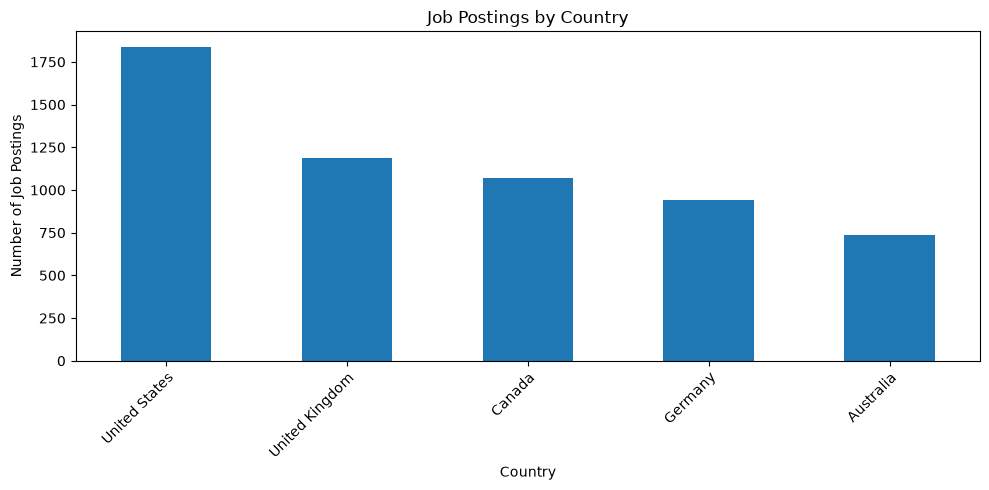

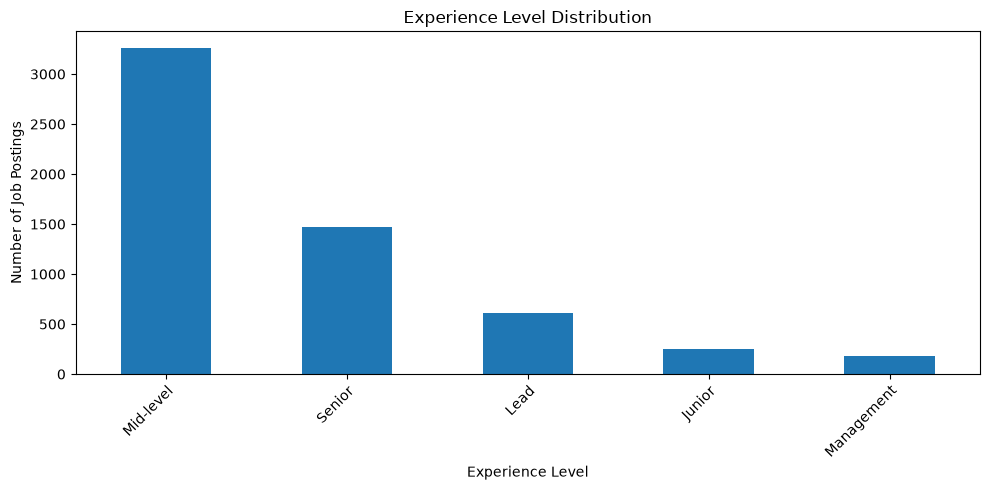

In [9]:
plot_bar_counts(
    df["country"],
    title="Job Postings by Country",
    xlabel="Country",
    ylabel="Number of Job Postings"
)

plot_bar_counts(
    df["experience_level"],
    title="Experience Level Distribution",
    xlabel="Experience Level",
    ylabel="Number of Job Postings"
)

## 3.6 Salary analysis

In [10]:
salary_columns = [
    "salary_min",
    "salary_max"
]

display(df[salary_columns].describe())

df["salary_avg"] = df[salary_columns].mean(axis=1)

display(df["salary_avg"].describe())

,salary_min,salary_max
count,3343.000000,3358.000000
mean,109240.801675,120957.415128
std,46680.622714,58922.331934
min,0.000000,0.000000
25%,77000.000000,82000.000000
50%,99000.000000,108000.000000
75%,133000.000000,148000.000000
max,413000.000000,800000.000000


count      3362.000000
mean     115371.058894
std       51890.531888
min           0.000000
25%       81000.000000
50%      103000.000000
75%      141875.000000
max      565000.000000
Name: salary_avg, dtype: float64

## 3.7 Salary distribution

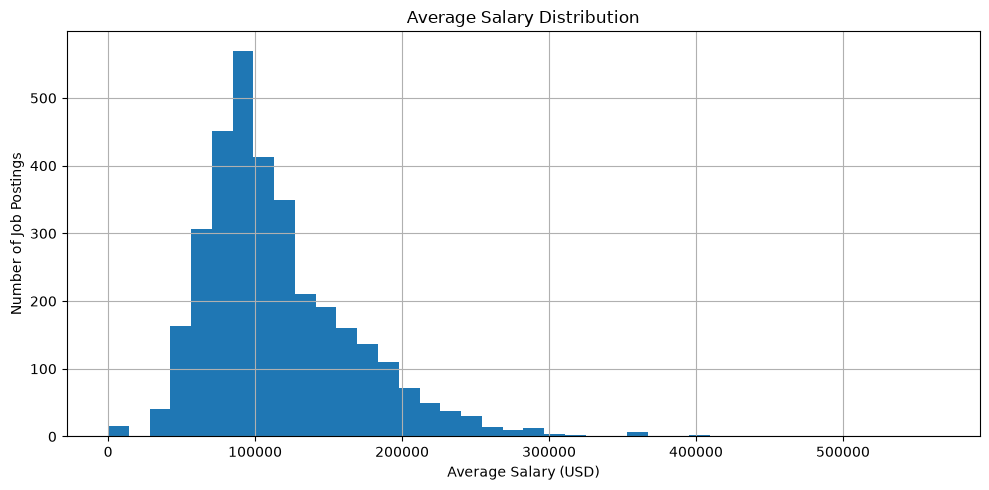

In [11]:
plt.figure(figsize=(10, 5))

df["salary_avg"].dropna().hist(bins=40)

plt.title("Average Salary Distribution")
plt.xlabel("Average Salary (USD)")
plt.ylabel("Number of Job Postings")

plt.tight_layout()
plt.show()

## 3.8 Average salary by country

country
United States     133397.547684
Canada            103857.819905
Australia         102835.714286
United Kingdom     91625.316456
Germany            88598.360656
Name: salary_avg, dtype: float64

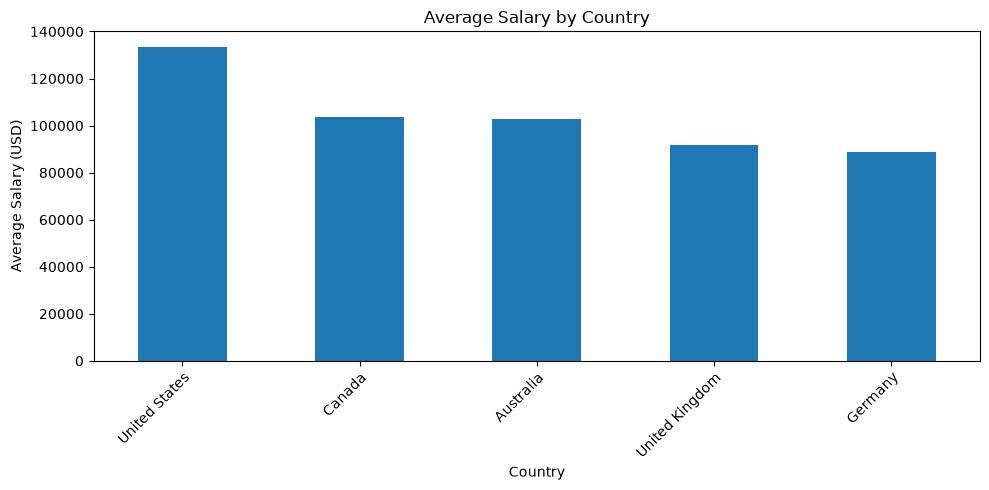

In [12]:
salary_by_country = (
    df.groupby("country")["salary_avg"]
    .mean()
    .sort_values(ascending=False)
)

display(salary_by_country)

plt.figure(figsize=(10, 5))

salary_by_country.plot(kind="bar")

plt.title("Average Salary by Country")
plt.xlabel("Country")
plt.ylabel("Average Salary (USD)")

plt.xticks(rotation=45, ha="right", rotation_mode="anchor")
plt.tight_layout()
plt.show()

## 3.9 Job titles and companies

In [13]:
top_job_titles = (
    df["job_title"]
    .value_counts()
    .head(20)
)

top_companies = (
    df["company"]
    .value_counts()
    .head(20)
)

display(top_job_titles)
display(top_companies)

job_title
Data Scientist                                                                 281
AI Engineer                                                                    270
Machine Learning Engineer (PhD Intern)                                         173
Machine Learning Engineer                                                      110
Senior Data Scientist                                                          105
Generative AI Automation Engineer - Remote Job                                  98
Senior Machine Learning Engineer                                                71
ML/LLM Operations Engineer                                                      53
AI Research Scientist - Language - MRS AI                                       49
Machine Learning Operations (MLOps) Intern                                      48
Senior AI Engineer                                                              42
AI Research Engineer (Junior career, Hybrid, Grand Prairie, Secret)          

company
Instacart                     198
Mercor                        102
EnthuZiastic                   98
Meta                           91
Oracle                         83
Lockheed Martin                76
mycareernow GmbH               61
Mindrift                       57
Evolent                        52
Bright Vision Technologies     52
netgo group GmbH               50
Intermountain Health           47
Deloitte                       40
BWI GmbH                       39
Weekday AI                     38
Speechify                      38
Cognizant                      37
Sedgwick                       36
Teradata                       34
Google                         34
Name: count, dtype: int64

## 3.10 Top hiring companies chart

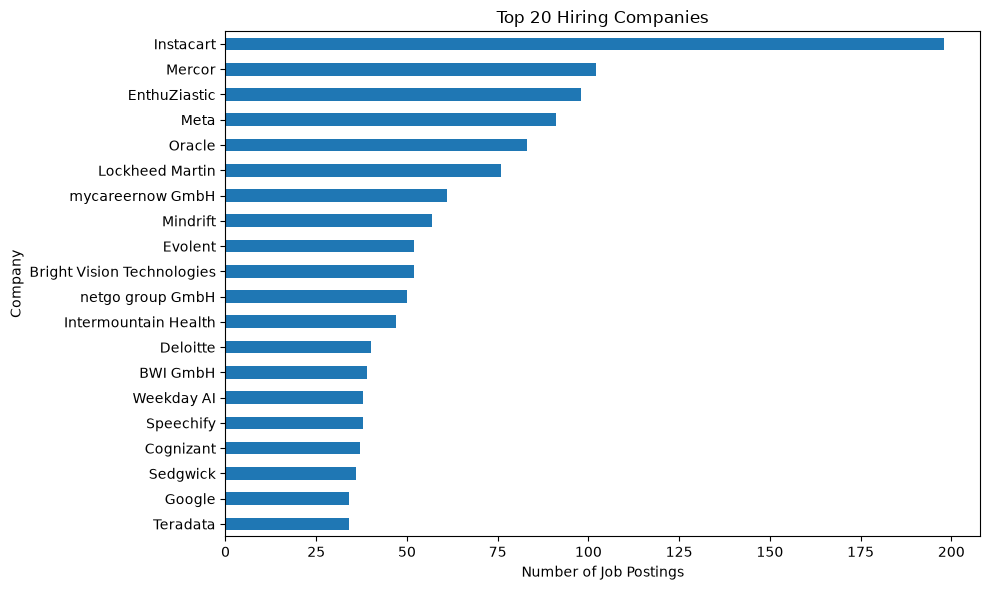

In [14]:
plt.figure(figsize=(10, 6))

top_companies.sort_values().plot(kind="barh")

plt.title("Top 20 Hiring Companies")
plt.xlabel("Number of Job Postings")
plt.ylabel("Company")

plt.tight_layout()
plt.show()

## 3.11 Job description length

In [15]:
df["description_length"] = (
    df["job_description"]
    .astype(str)
    .str.len()
)

display(df["description_length"].describe())

display(
    df["description_length"]
    .value_counts()
    .head(20)
    .to_frame("count")
)

count    5773.000000
mean      573.032565
std       583.732374
min        61.000000
25%       500.000000
50%       500.000000
75%       500.000000
max      7938.000000
Name: description_length, dtype: float64

,count
description_length,
500,5632
200,3
431,2
198,2
1877,2
7523,2
1157,2
6934,2
170,1


## 3.12 Job description length chart

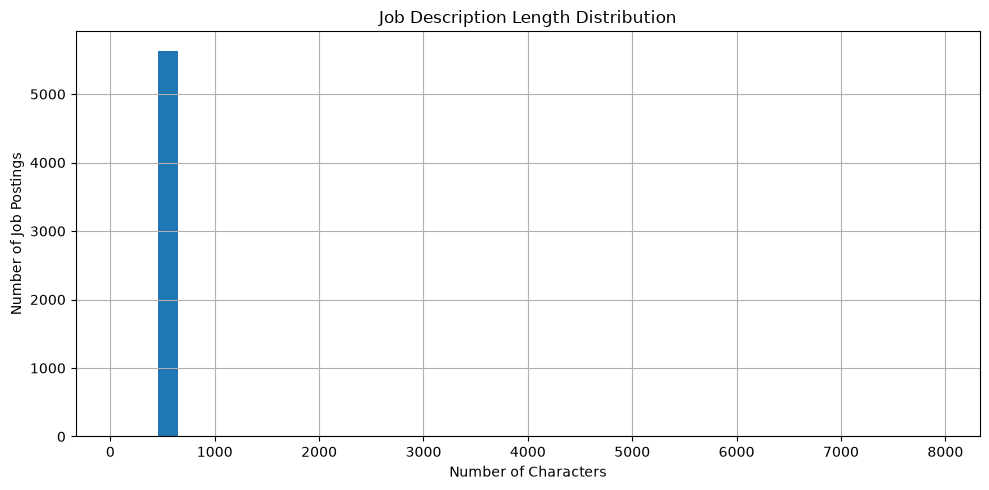

In [16]:
plt.figure(figsize=(10, 5))

df["description_length"].hist(bins=40)

plt.title("Job Description Length Distribution")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Job Postings")

plt.tight_layout()
plt.show()

## Key observations

The initial exploration shows that:

- The dataset contains 5,773 job postings.
- `required_skills` is highly incomplete, with more than 80% missing values.
- Salary information is missing for around 42% of postings.
- Most job postings come from five countries: United States, United Kingdom, Canada, Germany, and Australia.
- Most remote information is unspecified.
- Most roles are mid-level or senior.
- Job descriptions are often capped at 500 characters, which limits the quality of skill extraction.

# 4. Data Cleaning

This section prepares the dataset for analysis.

The cleaning process includes:

- creating a working copy
- removing duplicate rows
- standardizing text columns
- cleaning city names
- converting posting dates
- creating time-based features
- detecting truncated job descriptions
- normalizing German job titles
- saving the cleaned dataset

The final cleaned dataset is saved as:

`ai_jobs_clean.csv`

### 4.1 Create a working copy

In [17]:
df_clean = df.copy()

print("Initial rows:", len(df_clean))
print("Initial columns:", df_clean.shape[1])

Initial rows: 5773
Initial columns: 15


### 4.2 Remove duplicates

In [18]:
duplicate_rows = df_clean.duplicated().sum()

df_clean = (
    df_clean
    .drop_duplicates()
    .reset_index(drop=True)
)

print("Duplicate rows removed:", duplicate_rows)
print("Rows after duplicate removal:", len(df_clean))

Duplicate rows removed: 0
Rows after duplicate removal: 5773


### 4.3 Clean text columns

In [19]:
TEXT_COLUMNS = [
    "job_title",
    "company",
    "country",
    "city",
    "required_skills",
    "job_description"
]

for column in TEXT_COLUMNS:
    df_clean[column] = (
        df_clean[column]
        .astype("string")
        .str.strip()
        .replace("", pd.NA)
    )

### 4.4 Clean city names

In [20]:
COUNTRY_AS_CITY_VALUES = {
    "us": pd.NA,
    "usa": pd.NA,
    "united states": pd.NA,

    "uk": pd.NA,
    "united kingdom": pd.NA,

    "australia": pd.NA,
    "canada": pd.NA,
    "deutschland": pd.NA,
}

df_clean["city_clean"] = (
    df_clean["city"]
    .fillna("")
    .str.lower()
    .replace(COUNTRY_AS_CITY_VALUES)
)

display(
    df_clean["city_clean"]
    .value_counts()
    .head(20)
)

city_clean
london               516
toronto              270
sydney               173
the rocks            152
berlin               125
the city              97
montréal              70
münchen               63
melbourne             62
greater vancouver     62
melbourne cbd         49
san francisco         46
grand central         38
new york city         33
atlanta               29
vancouver             29
frankfurt am main     27
cambridge             26
boston                23
farringdon            23
Name: count, dtype: Int64

### 4.5 Convert posting dates

In [21]:
df_clean["posted_date"] = pd.to_datetime(
    df_clean["posted_date"],
    errors="coerce"
)

print("Earliest date:", df_clean["posted_date"].min())
print("Latest date:", df_clean["posted_date"].max())

Earliest date: 2021-05-29 00:00:00
Latest date: 2026-02-22 00:00:00


### 4.6 Create time features

In [22]:
df_clean["year"] = df_clean["posted_date"].dt.year.astype("Int64")
df_clean["month"] = df_clean["posted_date"].dt.month.astype("Int64")
df_clean["year_month"] = df_clean["posted_date"].dt.to_period("M")

display(df_clean[["posted_date", "year", "month", "year_month"]].head())

,posted_date,year,month,year_month
0,2026-02-16,2026,2,2026-02
1,2026-02-16,2026,2,2026-02
2,2026-02-16,2026,2,2026-02
3,2026-02-16,2026,2,2026-02
4,2026-02-16,2026,2,2026-02


### 4.7 Inspect important text fields

In [23]:
print("Missing job titles:", df_clean["job_title"].isna().sum())
print("Unique job titles:", df_clean["job_title"].nunique())

print("Missing descriptions:", df_clean["job_description"].isna().sum())

Missing job titles: 0
Unique job titles: 2883
Missing descriptions: 0


### 4.8 Detect truncated descriptions

In [24]:
if "description_length" not in df_clean.columns:
    df_clean["description_length"] = (
        df_clean["job_description"]
        .fillna("")
        .str.len()
    )

df_clean["description_truncated"] = (
    df_clean["description_length"] == 500
)

truncated_rate = (
    df_clean["description_truncated"]
    .mean() * 100
)

print(f"Potentially truncated descriptions: {truncated_rate:.2f}%")

Potentially truncated descriptions: 97.56%


## 4.9 Non-English Job Title Normalization

Some job titles are not fully in English.

The dataset contains mainly English titles, but also includes:

- German job titles
- French job titles
- titles with encoding issues such as `â€“`, `Â£`, `DÃ©veloppeur`, or `IngÃ©nieur`

The goal is not to perfectly translate every title.

The goal is to reduce noise before job title normalization by:

- fixing common encoding issues
- removing German gender markers
- translating common German job terms
- translating common French job terms
- keeping the original title for audit

### 4.9.1 Fix common encoding issues

In [25]:
def fix_common_encoding_issues(text):
    text = str(text)

    mojibake_markers = [
        "Ã",
        "Â",
        "â€",
        "â€“",
        "â€”",
        "ð"
    ]

    if any(marker in text for marker in mojibake_markers):
        try:
            text = text.encode("cp1252").decode("utf-8")
        except UnicodeError:
            pass

    replacements = {
        "â€“": "–",
        "â€”": "—",
        "â€˜": "‘",
        "â€™": "’",
        "â€œ": "“",
        "â€": "”",
        "â€": "”",
        "Â£": "£",
        "Â·": "·",
        "Ã©": "é",
        "Ã¨": "è",
        "Ãª": "ê",
        "Ã«": "ë",
        "Ã ": "à",
        "Ã¢": "â",
        "Ã´": "ô",
        "Ã®": "î",
        "Ã¯": "ï",
        "Ã§": "ç",
        "Ã¼": "ü",
        "Ã¶": "ö",
        "Ã¤": "ä",
        "ÃŸ": "ß",
    }

    for bad_value, clean_value in replacements.items():
        text = text.replace(bad_value, clean_value)

    return text.strip()

### 4.9.2 Detect German and French titles

In [26]:
GERMAN_MARKERS = [
    " für ",
    " und ",
    " mit ",
    " als ",
    " bei ",
    " künstliche ",
    " intelligenz ",
    " lösung ",
    " lösungen ",
    " entwicklung ",
    " entwickler ",
    " ingenieur ",
    " berater ",
    " architekt ",
    " plattform ",
    " quereinstieg ",
    " stellenangebot ",
    " inklusiver job ",
    " m/w/d",
    " w/m/d",
    " f/m/d",
    " d/f/m",
    " gn",
]


FRENCH_MARKERS = [
    " développeur",
    " développeuse",
    " ingénieur",
    " ingénieure",
    " intelligence artificielle",
    " spécialiste",
    " stage en",
    " comptabilité",
    " médias sociaux",
    " ventes digitales",
    " développement",
    " logicielle",
    " expérience",
    " systèmes agentiques",
    " gestionnaire",
    " centre d'excellence",
]


def contains_marker(text, markers):
    text = f" {str(text).lower()} "

    return any(
        marker in text
        for marker in markers
    )


df_clean["job_title_original"] = df_clean["job_title"]

df_clean["job_title"] = (
    df_clean["job_title"]
    .apply(fix_common_encoding_issues)
)

df_clean["is_likely_german_title"] = (
    df_clean["job_title"]
    .apply(lambda title: contains_marker(title, GERMAN_MARKERS))
)

df_clean["is_likely_french_title"] = (
    df_clean["job_title"]
    .apply(lambda title: contains_marker(title, FRENCH_MARKERS))
)

df_clean["is_likely_non_english_title"] = (
    df_clean["is_likely_german_title"]
    | df_clean["is_likely_french_title"]
)

print("Likely German titles:", df_clean["is_likely_german_title"].sum())
print("Likely French titles:", df_clean["is_likely_french_title"].sum())
print("Likely non-English titles:", df_clean["is_likely_non_english_title"].sum())

Likely German titles: 153
Likely French titles: 28
Likely non-English titles: 181


### 4.9.3 Define German cleaning rules

In [27]:
GENDER_PATTERNS = [
    r"\(m/w/d\)",
    r"\(w/m/d\)",
    r"\(f/m/d\)",
    r"\(d/f/m\)",
    r"\(m/f/d\)",
    r"\(m/f/x\)",
    r"\(f/m/x\)",
    r"\(w/m/x\)",
    r"\(w/m/div\.\)",
    r"\(all genders\)",
    r"all genders",
    r"\(gn\)",
    r"\bgn\b",

    r"\bm/w/d\b",
    r"\bw/m/d\b",
    r"\bf/m/d\b",
    r"\bd/f/m\b",
    r"\bm/f/d\b",
    r"\bm/f/x\b",
    r"\bf/m/x\b",
    r"\bw/m/x\b",
    r"\bw/m/div\.\b",
    r"\bw\|m\|d\b",
]


GERMAN_REPLACEMENTS = {
    "für": "for",
    "als": "as",
    "auf": "on",
    "mit": "with",
    "und": "and",
    "oder": "or",
    "im": "in",
    "am": "at",
    "bei": "at",
    "der": "the",
    "die": "the",
    "das": "the",

    "Berater": "Consultant",
    "Quereinstieg": "Career Changer",
    "Quereinsteiger": "Career Changer",
    "Ingenieur": "Engineer",
    "Entwickler": "Developer",
    "Architekt": "Architect",
    "Systemintegrator": "System Integrator",

    "Duales Studium": "Dual Study",
    "Studiengang": "Degree Program",
    "Informatiker": "Computer Scientist",
    "Wirtschaftsinformatiker": "Business Informatics Specialist",
    "Mathematiker": "Mathematician",

    "Wissenschaftliche": "Research",
    "Wissenschaftlicher": "Research",
    "Mitarbeiterin": "Employee",
    "Mitarbeiter": "Employee",
    "Forschung": "Research",
    "Technologietransfer": "Technology Transfer",

    "Schwerpunkt": "Focus",
    "Fokus": "Focus",
    "Lösungen": "Solutions",
    "Lösung": "Solution",
    "Anwendungen": "Applications",
    "Anwendung": "Application",
    "Plattform": "Platform",
    "Datenbankentwicklung": "Database Development",
    "Prozess-Analytiker": "Process Analyst",
    "Finanzcontrolling": "Financial Controlling",
    "Konzeption": "Design",
    "Realisierung": "Implementation",
    "Digitale": "Digital",
    "digitalen": "Digital",
    "Vertriebsprozesse": "Sales Processes",
    "Mobilität": "Mobility",
    "Anwendungsentwicklung": "Application Development",

    "KI": "AI",
    "Künstliche Intelligenz": "Artificial Intelligence",

    "Inklusiver Job": "Inclusive Role",
    "Stellenangebot": "Job Posting",

    "JVRS1_DE": "",

    "Fachverantwortliche*r": "Technical Lead",
    "Fachverantwortliche": "Technical Lead",
    "Fachverantwortlicher": "Technical Lead",

    "betriebswirtschaftlichem": "business administration",
    "betriebswirtschaftliche": "business administration",
    "betriebswirtschaftlicher": "business administration",

    "Aktuar": "Actuary",
    "Prüfungskorrektor": "Exam Reviewer",
    "Korrektor": "Reviewer",
    "Dozent": "Lecturer",

    "KI-Beauftragter": "AI Officer",
    "AI-Beauftragter": "AI Officer",
    "KI Spezialist": "AI Specialist",
    "AI Spezialist": "AI Specialist",

    "KI-Themen": "AI Topics",
    "KI-Themen": "AI Topics",
    "AI-Themen": "AI Topics",
    "AI-Themen": "AI Topics",
    "Themen": "Topics",

    "Public Sektor": "Public Sector",
    "Sektor": "Sector",

    "Steuern": "Tax",
    "Köln": "Cologne",

    "Transport und Mobilität": "Transport and Mobility",
    "Mobilität": "Mobility",

    "Forschung": "Research",
    "Ingenieur": "Engineer",
}

### 4.9.4 Define French cleaning rules

In [28]:
FRENCH_TITLE_PATTERNS = {
    r"ing[eé]?nieur.*d[eé]?veloppeur.*intelligence artificielle.*ai engineer":
        "AI Engineer",

    r"ai engineer.*ing[eé]?nieur.*intelligence artificielle":
        "AI Engineer",

    r"ing[eé]?nieur ia/ai software engineer":
        "AI Software Engineer",

    r"ai product engineer.*ing[eé]?nieur produit ia":
        "AI Product Engineer",

    r"ing[eé]?nieur produit ia.*ai product engineer":
        "AI Product Engineer",

    r"d[eé]?veloppeur ia python":
        "Python AI Developer",

    r"sp[eé]cialiste.*innovation logicielle.*r&d":
        "Software Innovation and R&D Specialist",

    r"d[eé]?veloppeur.*senior.*ia.*syst[eè]mes agentiques":
        "Senior AI/Agentic Systems Developer",

    r"stage en comptabilit[eé].*administration financi[eè]re":
        "Accounting and Financial Administration Intern",

    r"stage en marketing.*m[eé]dias sociaux":
        "Marketing and Social Media Intern",

    r"stage en web design":
        "Web Design Intern",

    r"stage en d[eé]veloppement d'applications":
        "Application Development Intern",

    r"stage en communication.*relations publiques":
        "Communication and Public Relations Intern",

    r"stage en e-commerce.*ventes digitales":
        "E-Commerce and Digital Sales Intern",

    r"d[eé]?veloppeur mlops":
        "MLOps Developer",

    r"senior mlops engineer.*ing[eé]nieur.*mlops":
        "Senior MLOps Engineer",

    r"d[eé]veloppeur ou d[eé]veloppeuse mlops":
        "MLOps Developer",

    r"ing[eé]nieure ou ing[eé]nieur.*machine learning":
        "Machine Learning Engineer",

    r"ing[eé]nieure ou ing[eé]nieur plateforme":
        "Platform Engineer",

    r"d[eé]veloppeur intelligence artificielle":
        "Artificial Intelligence Developer",

    r"sp[eé]cialiste devops":
        "DevOps Specialist",

    r"sp[eé]cialiste.*intelligence artificielle":
        "Artificial Intelligence Specialist",

    r"d[eé]veloppeur principal agentique ia":
        "Principal Agentic AI Developer",

    r"d[eé]veloppement d'applications logicielles":
        "Software Application Development",

    r"gestionnaire.*centre d'excellence.*automatisation.*intelligence artificielle":
        "Manager, Automation and Artificial Intelligence Center of Excellence",

    r"gestionnaire.*projets strat[eé]giques venture":
        "Manager, Venture Strategic Projects",
    
    r"ing[eé]?nieur\s+ia\s*/\s*ai software engineer":
    "AI Software Engineer",
}


def translate_known_french_title(title):
    title_lower = str(title).lower()

    for pattern, translation in FRENCH_TITLE_PATTERNS.items():
        if re.search(pattern, title_lower, flags=re.IGNORECASE):
            return translation

    return None

### 4.9.5 Define formatting cleanup rules

In [29]:
FRENCH_REPLACEMENTS = {
    "Développeur": "Developer",
    "Développeuse": "Developer",
    "dveloppeur": "Developer",
    "dveloppeuse": "Developer",

    "Ingénieur": "Engineer",
    "Ingénieure": "Engineer",
    "Ingnieur": "Engineer",
    "Ingnieure": "Engineer",

    "Scientifique des données": "Data Scientist",
    "sciences de la donnée": "data science",

    "Intelligence Artificielle": "Artificial Intelligence",
    "intelligence artificielle": "Artificial Intelligence",
    "IA": "AI",

    "Spécialiste": "Specialist",
    "spécialiste": "Specialist",

    "Gestionnaire": "Manager",
    "Conseiller": "Consultant",
    "Directeur": "Director",
    "Architecte": "Architect",

    "Stage en": "Internship in",
    "Comptabilité": "Accounting",
    "Administration Financière": "Financial Administration",
    "Marketing & Médias Sociaux": "Marketing and Social Media",
    "Développement d'Applications": "Application Development",
    "Communication & Relations Publiques": "Communication and Public Relations",
    "E-Commerce & Ventes Digitales": "E-Commerce and Digital Sales",

    "innovation logicielle": "software innovation",
    "systèmes agentiques": "agentic systems",
    "applications logicielles": "software applications",
    "développement": "development",
    "logicielles": "software",
    "logicielle": "software",

    "produit": "Product",
    "plateforme": "Platform",
    "Centre d'excellence": "Center of Excellence",
    "automatisation": "automation",
    "expérience": "experience",
    "principal": "Principal",
    "agentique": "Agentic",

    " en ": " in ",
    " et ": " and ",
}


FORMAT_REPLACEMENTS = {
    "AI-Developer": "AI Developer",
    "AI-Engineer": "AI Engineer",
    "AI-Entwickler": "AI Developer",
    "Cloud-Engineer": "Cloud Engineer",
    "Data-": "Data ",

    "the JUST ADD AI": "JUST ADD AI",
    "at the ": "at ",
    "AI-Applications": "AI Applications",
    "Pricing-Platform": "Pricing Platform",
    "Frankfurt at Main": "Frankfurt",

    "Data Engineer/Cloud Engineer": "Data Engineer / Cloud Engineer",
    "Machine Learning/AI Engineer": "Machine Learning AI Engineer",
    "MLOps/DevOps": "MLOps DevOps",

    "Azure AI Engineer with Focus Agents": "Azure AI Engineer with Focus on Agents",
    "Azure OpenAI Developer MLOps Focus": "Azure OpenAI Developer with MLOps Focus",
}

### 4.9.6 Clean non-English job titles

In [30]:
def apply_regex_patterns(text, patterns, replacement):
    for pattern in patterns:
        text = re.sub(
            pattern,
            replacement,
            text,
            flags=re.IGNORECASE
        )

    return text


def apply_word_replacements(text, replacements):
    for old_value, new_value in sorted(
        replacements.items(),
        key=lambda item: len(item[0]),
        reverse=True
    ):
        text = re.sub(
            r"\b" + re.escape(old_value) + r"\b",
            new_value,
            text,
            flags=re.IGNORECASE
        )

    return text


def clean_non_english_title(title):
    clean_title = fix_common_encoding_issues(title)

    # Use pattern-based translations first.
    french_translation = translate_known_french_title(clean_title)

    if french_translation is not None:
        return french_translation

    # Then fallback to word-by-word cleanup.
    clean_title = apply_regex_patterns(
        clean_title,
        GENDER_PATTERNS,
        ""
    )

    clean_title = re.sub(
        r"\bDéveloppeur\s*·\s*euse\b",
        "Developer",
        clean_title,
        flags=re.IGNORECASE
    )

    clean_title = re.sub(
        r"\bDéveloppeur\s+ou\s+développeuse\b",
        "Developer",
        clean_title,
        flags=re.IGNORECASE
    )

    clean_title = re.sub(
        r"\bIngénieur\(e\)\b|\bIngénieur\s*·\s*e\b|\bIngénieur·e\b",
        "Engineer",
        clean_title,
        flags=re.IGNORECASE
    )

    clean_title = re.sub(
        r"\bIngénieure\s+ou\s+ingénieur\b",
        "Engineer",
        clean_title,
        flags=re.IGNORECASE
    )

    clean_title = apply_word_replacements(
        clean_title,
        GERMAN_REPLACEMENTS
    )

    clean_title = apply_word_replacements(
        clean_title,
        FRENCH_REPLACEMENTS
    )

    for old_value, new_value in FORMAT_REPLACEMENTS.items():
        clean_title = clean_title.replace(
            old_value,
            new_value
        )

    clean_title = re.sub(r"\s+", " ", clean_title)
    clean_title = re.sub(r"\s+/", "/", clean_title)
    clean_title = re.sub(r"/\s+", "/", clean_title)
    clean_title = re.sub(r"\s+-\s+", " - ", clean_title)

    clean_title = clean_title.strip(" -|*/")

    return clean_title

### 4.9.7 Apply title cleaning

In [31]:
df_clean["job_title_cleaned"] = (
    df_clean["job_title"]
    .apply(clean_non_english_title)
)

df_clean["job_title"] = df_clean["job_title_cleaned"]

### 4.9.8 Inspect the result

In [32]:
non_english_preview = (
    df_clean.loc[
        df_clean["is_likely_non_english_title"],
        [
            "job_title_original",
            "job_title_cleaned",
            "is_likely_german_title",
            "is_likely_french_title"
        ]
    ]
    .drop_duplicates()
)

display(non_english_preview.head(50))

,job_title_original,job_title_cleaned,is_likely_german_title,is_likely_french_title
2999,Ingénieur développeur Intelligence Artificiell...,AI Engineer,False,True
3001,Ingnieur dveloppeur Intelligence Artificielle ...,AI Engineer,False,True
3005,AI Engineer/Ingénieur(e) en intelligence artif...,AI Engineer,False,True
3006,AI Engineer/Ingnieur(e) en intelligence artifi...,AI Engineer,False,True
3063,Ingénieur IA / AI Software Engineer,AI Software Engineer,False,True
3082,AI Product Engineer | Ingénieur produit IA,AI Product Engineer,False,True
3083,Ingénieur produit IA | AI Product Engineer,AI Product Engineer,False,True
3463,Développeur IA Python,Python AI Developer,False,True
3490,Spécialiste en innovation logicielle et R&D,Software Innovation and R&D Specialist,False,True
3537,Développeur · euse senior en IA / systèmes age...,Senior AI/Agentic Systems Developer,False,True


In [33]:
print("Cleaned German titles:")
display(
    df_clean.loc[
        df_clean["is_likely_german_title"],
        "job_title"
    ]
    .value_counts()
    .head(30)
)

print("Cleaned French titles:")
display(
    df_clean.loc[
        df_clean["is_likely_french_title"],
        "job_title"
    ]
    .value_counts()
    .head(50)
)

Cleaned German titles:


job_title
Consultant for Digital Transformation & AI – Ideal for Career Changer                     26
Career Changer as Prompt Engineer – 100% remote                                           16
Senior IT Expert Platform Automation                                                       9
Azure AI Engineer with Focus on Agents                                                     8
Senior System Integrator for AI Applications                                               8
Azure OpenAI Developer with MLOps Focus                                                    5
MLOps Engineer for CI/CD & Inference Services                                              3
IT Architect - Public Sector/Defense                                                       3
AI Engineer at lector.ai                                                                   2
AI Engineer at SCOUTASTIC                                                                  2
AI Engineer at JUST ADD AI                                  

Cleaned French titles:


job_title
AI Engineer                                                             4
AI Product Engineer                                                     2
MLOps Developer                                                         2
AI Software Engineer                                                    1
Python AI Developer                                                     1
Software Innovation and R&D Specialist                                  1
Senior AI/Agentic Systems Developer                                     1
Accounting and Financial Administration Intern                          1
Marketing and Social Media Intern                                       1
Web Design Intern                                                       1
Application Development Intern                                          1
Communication and Public Relations Intern                               1
E-Commerce and Digital Sales Intern                                     1
Senior MLOps Engineer       

### 4.10 Save the cleaned dataset

In [34]:
OUTPUT_PATH = (
    DATA_DIR
    / "data"
    / "JobMarket2026"
    / "ai_jobs_clean.csv"
)

df_clean.to_csv(
    OUTPUT_PATH,
    index=False
)

print("Dataset saved.")
print("Output path:", OUTPUT_PATH)
print("Final shape:", df_clean.shape)

Dataset saved.
Output path: C:\Users\jerem\job_analysis\2026_ai_job_market_analysis\data\JobMarket2026\ai_jobs_clean.csv
Final shape: (5773, 25)


## Section 4 Summary

This section created the cleaned version of the dataset.

The main cleaning steps were:

- duplicate rows were checked and removed
- important text columns were standardized
- city names were cleaned
- posting dates were converted to datetime format
- year, month, and year-month features were created
- potentially truncated job descriptions were detected
- German and French job titles were cleaned and partially translated
- the cleaned dataset was saved as `ai_jobs_clean.csv`

The final cleaned dataset contains 5,773 rows and 25 columns.

# 5. Job Title Exploration and Taxonomy

This section explores the cleaned job titles before normalization.

The goal is to understand:

- the number of unique job titles
- the most frequent job titles
- the most common words used in titles
- the main job families present in the dataset
- the titles that do not clearly match any family

The section ends by defining the standard job title taxonomy used in the next normalization steps.

## 5.1 Load the cleaned dataset

In [35]:
CLEAN_DATASET_PATH = (
    DATA_DIR
    / "data"
    / "JobMarket2026"
    / "ai_jobs_clean.csv"
)

df_titles = pd.read_csv(CLEAN_DATASET_PATH)

print("Dataset loaded:", df_titles.shape)

Dataset loaded: (5773, 25)


## 5.2 Job title summary

In [36]:
title_summary = pd.DataFrame({
    "metric": [
        "Total job postings",
        "Missing job titles",
        "Unique job titles"
    ],
    "value": [
        len(df_titles),
        df_titles["job_title"].isna().sum(),
        df_titles["job_title"].nunique()
    ]
})

display(title_summary)

,metric,value
0,Total job postings,5773
1,Missing job titles,0
2,Unique job titles,2773


## 5.3 Most frequent job titles

In [37]:
top_titles = (
    df_titles["job_title"]
    .value_counts()
    .head(30)
)

display(top_titles)

job_title
Data Scientist                                                           311
AI Engineer                                                              291
Machine Learning Engineer (PhD Intern)                                   173
Senior Data Scientist                                                    119
Machine Learning Engineer                                                115
Generative AI Automation Engineer - Remote Job                            98
Senior Machine Learning Engineer                                          74
Senior AI Engineer                                                        61
ML/LLM Operations Engineer                                                53
AI Research Scientist - Language - MRS AI                                 49
Machine Learning Operations (MLOps) Intern                                48
AI Research Engineer (Junior career, Hybrid, Grand Prairie, Secret)       42
Computer Vision Engineer                                          

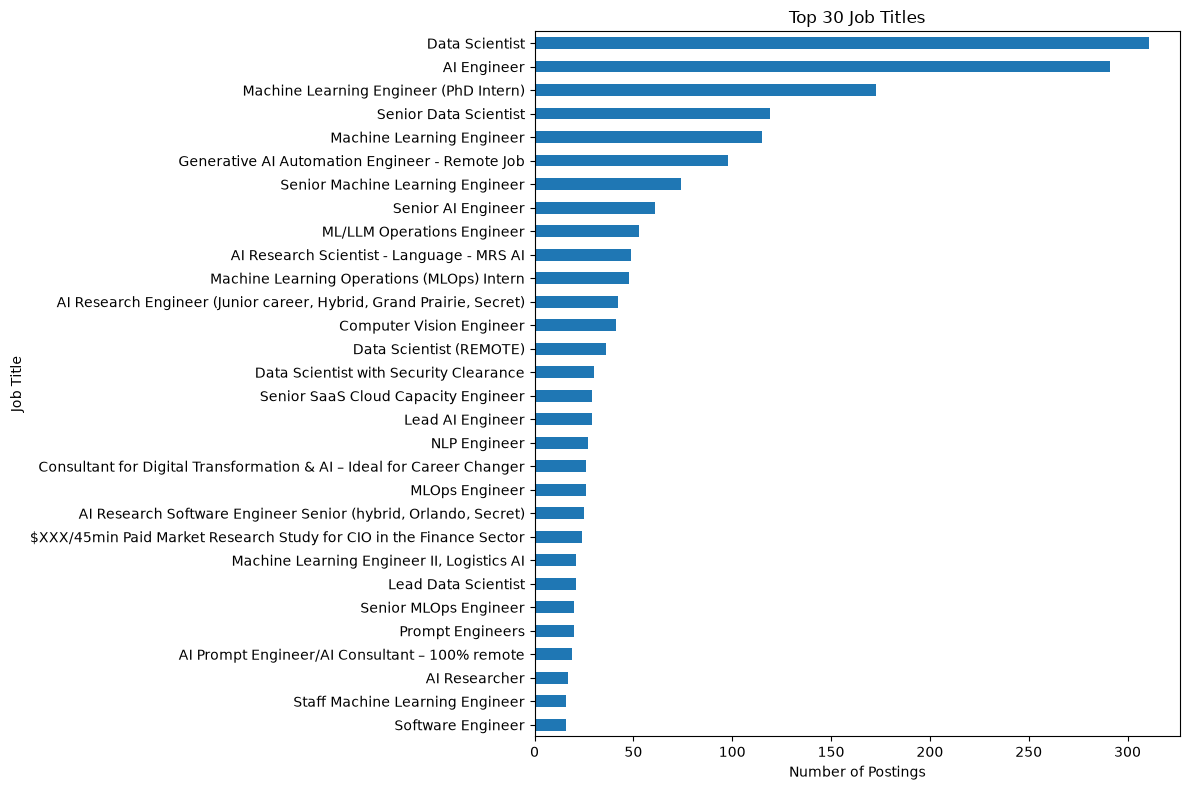

In [38]:
plt.figure(figsize=(12, 8))

top_titles.sort_values().plot(kind="barh")

plt.title("Top 30 Job Titles")
plt.xlabel("Number of Postings")
plt.ylabel("Job Title")

plt.tight_layout()
plt.show()

## 5.4 Prepare titles for text analysis

In [39]:
df_titles["job_title_for_analysis"] = (
    df_titles["job_title"]
    .fillna("")
    .astype(str)
    .str.lower()
    .str.strip()
)

## 5.5 Extract common words from job titles

In [40]:
TITLE_STOP_WORDS = {
    "senior",
    "junior",
    "lead",
    "staff",
    "principal",
    "manager",
    "director",
    "head",
    "remote",
    "hybrid",
    "intern",
    "internship",
    "phd",
    "ii",
    "iii",
    "iv",
    "of",
    "and",
    "the",
    "for",
    "with",
    "to",
    "in",
    "on",
    "at",
    "as",
    "a",
    "an"
}


def tokenize_title(title):
    tokens = re.findall(
        r"[a-zA-Z][a-zA-Z+#]*",
        str(title).lower()
    )

    return [
        token
        for token in tokens
        if token not in TITLE_STOP_WORDS
        and len(token) > 1
    ]


all_title_words = []

for title in df_titles["job_title_for_analysis"]:
    all_title_words.extend(tokenize_title(title))


common_words = pd.DataFrame(
    Counter(all_title_words).most_common(40),
    columns=["word", "count"]
)

display(common_words)

,word,count
0,engineer,3208
1,ai,2469
2,data,1222
3,scientist,1059
4,learning,901
5,machine,884
6,research,454
7,software,409
8,ml,271
9,llm,242


## 5.6 Visualize common words

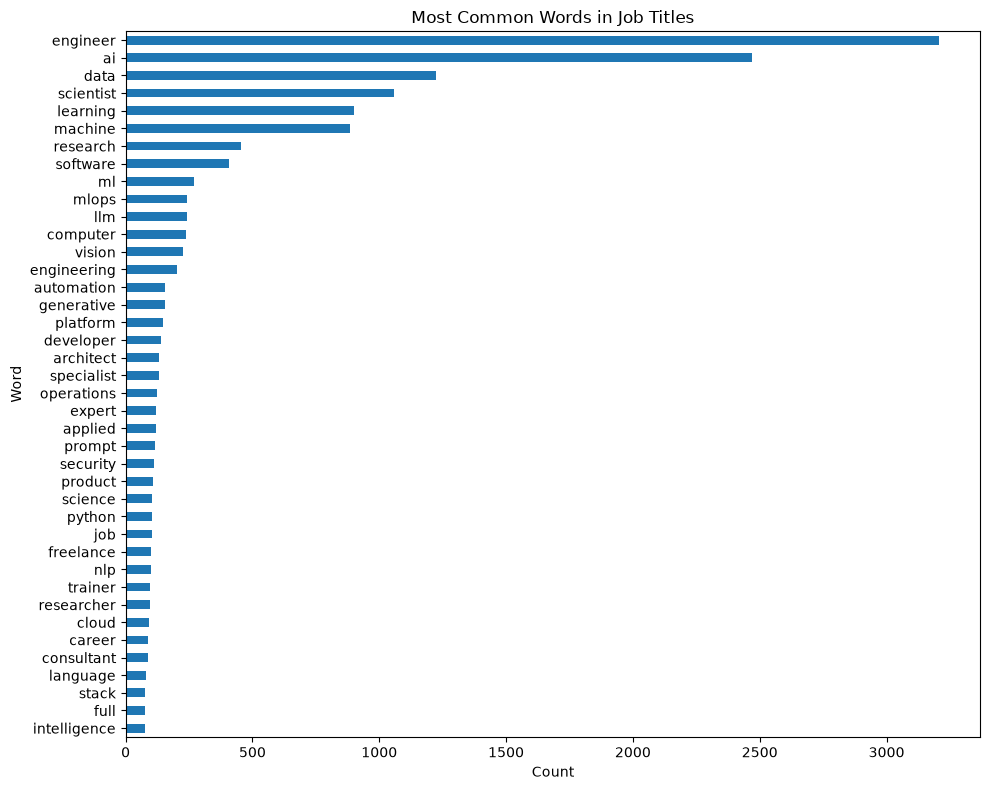

In [41]:
plt.figure(figsize=(10, 8))

common_words.set_index("word")["count"].sort_values().plot(
    kind="barh"
)

plt.title("Most Common Words in Job Titles")
plt.xlabel("Count")
plt.ylabel("Word")

plt.tight_layout()
plt.show()

## 5.7 Estimate job families

In [42]:
JOB_FAMILY_PATTERNS = {
    "AI Engineer": [
        r"\bai\b",
        r"\bartificial intelligence\b",
        r"\bgenai\b",
        r"\bgenerative ai\b",
        r"\bprompt engineer\b",
        r"\bprompt engineers\b",
        r"\bprompt engineering\b"
    ],

    "Machine Learning Engineer": [
        r"\bmachine learning\b",
        r"\bml\b"
    ],

    "Data Scientist": [
        r"\bdata scientist\b",
        r"\bdata science\b"
    ],

    "Data Engineer": [
        r"\bdata engineer\b",
        r"\bdata engineering\b",
        r"\bdata pipeline\b"
    ],

    "Research Scientist": [
        r"\bresearch scientist\b",
        r"\bresearch engineer\b",
        r"\bresearcher\b",
        r"\bresearch\b"
    ],

    "Computer Vision Engineer": [
        r"\bcomputer vision\b",
        r"\bvision\b"
    ],

    "NLP Engineer": [
        r"\bnlp\b",
        r"\bnatural language\b"
    ],

    "LLM Engineer": [
        r"\bllm\b",
        r"\blanguage model\b",
        r"\blarge language\b"
    ],

    "MLOps Engineer": [
        r"\bmlops\b",
        r"\bml ops\b",
        r"\bmachine learning operations\b"
    ],

    "DevOps Engineer": [
        r"\bdevops\b"
    ],

    "Platform Engineer": [
        r"\bplatform\b",
        r"\bcloud\b",
        r"\binfrastructure\b"
    ],

    "Software Engineer": [
        r"\bsoftware\b",
        r"\bdeveloper\b",
        r"\bfull stack\b",
        r"\bbackend\b",
        r"\bfrontend\b"
    ],

    "Solutions Architect": [
        r"\bsolutions architect\b",
        r"\bsolution architect\b",
        r"\barchitect\b"
    ],

    "Product / Management": [
        r"\bproduct manager\b",
        r"\bproject manager\b",
        r"\bprogram manager\b",
        r"\bmanager\b"
    ],

    "Consultant": [
        r"\bconsultant\b",
        r"\bconsulting\b"
    ]
}


def matches_patterns(title, patterns):
    return any(
        re.search(pattern, title, flags=re.IGNORECASE)
        for pattern in patterns
    )


family_counts = pd.Series({
    family: df_titles["job_title_for_analysis"]
    .apply(lambda title: matches_patterns(title, patterns))
    .sum()

    for family, patterns in JOB_FAMILY_PATTERNS.items()
}).sort_values(ascending=False)

display(family_counts)

AI Engineer                  2455
Machine Learning Engineer    1142
Data Scientist                941
Software Engineer             586
Research Scientist            531
Platform Engineer             267
MLOps Engineer                259
LLM Engineer                  242
Computer Vision Engineer      227
Product / Management          211
Solutions Architect           128
NLP Engineer                  105
Consultant                     98
Data Engineer                  91
DevOps Engineer                36
dtype: int64

## 5.8 Visualize job families

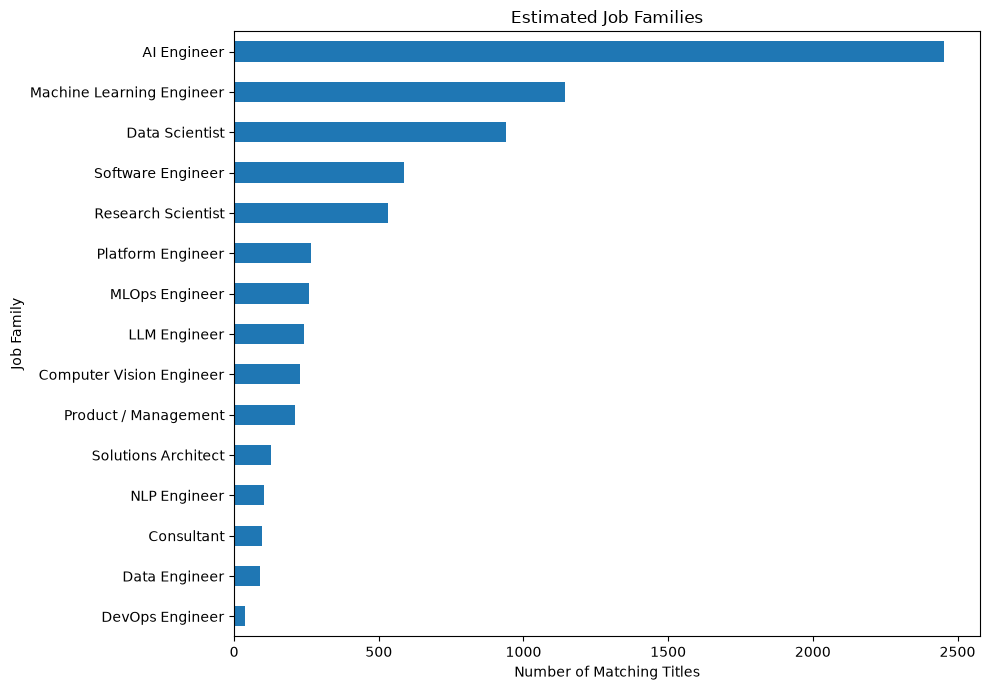

In [43]:
plt.figure(figsize=(10, 7))

family_counts.sort_values().plot(kind="barh")

plt.title("Estimated Job Families")
plt.xlabel("Number of Matching Titles")
plt.ylabel("Job Family")

plt.tight_layout()
plt.show()

## 5.9 Identify unmatched titles

In [44]:
def matches_any_family(title):
    return any(
        matches_patterns(title, patterns)
        for patterns in JOB_FAMILY_PATTERNS.values()
    )


df_titles["matched_any_family"] = (
    df_titles["job_title_for_analysis"]
    .apply(matches_any_family)
)

unmatched_titles = (
    df_titles.loc[
        ~df_titles["matched_any_family"],
        "job_title"
    ]
    .value_counts()
    .head(50)
)

display(unmatched_titles)

job_title
Operating System Expert (Windows, MacOS, Linux)                     7
Development & Programming Expert                                    7
Office Suite Expert                                                 7
CAD and Engineering Expert                                          7
Azure Agent Orchestrierung Engineer                                 6
Clinical Laboratory Scientist                                       6
Outside Sales Product Specialist - Data Management, London          4
ENGINEER/SCIENTIST                                                  4
Analytics Engineer                                                  3
Graduate Implementation Specialist                                  3
Lead Engineer- Financial Services                                   3
Technical Lead - TypeScript/Node.js                                 3
Product Engineer                                                    3
Medical Expert                                                      3
STEM PhDs 

## 5.10 Define standard job title taxonomy

In [45]:
STANDARD_TITLES = [
    "AI Engineer",
    "Machine Learning Engineer",
    "Data Scientist",
    "Data Engineer",
    "Research Scientist",
    "Computer Vision Engineer",
    "NLP Engineer",
    "LLM Engineer",
    "MLOps Engineer",
    "DevOps Engineer",
    "Platform Engineer",
    "Software Engineer",
    "Solutions Architect",
    "Product / Management",
    "Consultant",
    "Other"
]

## 5.11 Add category descriptions

In [46]:
TAXONOMY_DESCRIPTION = {
    "AI Engineer":
        "Builds AI applications and generative AI systems.",

    "Machine Learning Engineer":
        "Develops, trains and deploys machine learning models.",

    "Data Scientist":
        "Performs data analysis, statistical modeling and experimentation.",

    "Data Engineer":
        "Builds and maintains data pipelines and data infrastructure.",

    "Research Scientist":
        "Conducts research in AI, machine learning and related fields.",

    "Computer Vision Engineer":
        "Develops image-based and computer vision systems.",

    "NLP Engineer":
        "Builds natural language processing systems.",

    "LLM Engineer":
        "Builds systems and applications based on large language models.",

    "MLOps Engineer":
        "Deploys, monitors and maintains machine learning systems.",

    "DevOps Engineer":
        "Builds software deployment, automation and infrastructure workflows.",

    "Platform Engineer":
        "Builds cloud, infrastructure and developer platform systems.",

    "Software Engineer":
        "Develops general software systems and applications.",

    "Solutions Architect":
        "Designs technical architectures and enterprise solutions.",

    "Product / Management":
        "Manages products, projects, programs or technical teams.",

    "Consultant":
        "Provides technical or business consulting services.",

    "Other":
        "Titles that cannot be confidently assigned to a standard category."
}

## 5.12 Create taxonomy DataFrame

In [47]:
taxonomy_df = pd.DataFrame({
    "standard_title": STANDARD_TITLES,
    "description": [
        TAXONOMY_DESCRIPTION[title]
        for title in STANDARD_TITLES
    ]
})

display(taxonomy_df)

,standard_title,description
0,AI Engineer,Builds AI applications and generative AI systems.
1,Machine Learning Engineer,"Develops, trains and deploys machine learning ..."
2,Data Scientist,"Performs data analysis, statistical modeling a..."
3,Data Engineer,Builds and maintains data pipelines and data i...
4,Research Scientist,"Conducts research in AI, machine learning and ..."
5,Computer Vision Engineer,Develops image-based and computer vision systems.
6,NLP Engineer,Builds natural language processing systems.
7,LLM Engineer,Builds systems and applications based on large...
8,MLOps Engineer,"Deploys, monitors and maintains machine learni..."
9,DevOps Engineer,"Builds software deployment, automation and inf..."


## 5.13 Save taxonomy

In [48]:
TAXONOMY_PATH = (
    DATA_DIR
    / "data"
    / "JobMarket2026"
    / "job_title_taxonomy.csv"
)

taxonomy_df.to_csv(
    TAXONOMY_PATH,
    index=False
)

print("Taxonomy saved.")
print("Output path:", TAXONOMY_PATH)

Taxonomy saved.
Output path: C:\Users\jerem\job_analysis\2026_ai_job_market_analysis\data\JobMarket2026\job_title_taxonomy.csv


## Section 5 Summary

This section explored the cleaned job titles before normalization.

The goal was to understand how job titles are distributed and to prepare a standard title taxonomy.

The section:

- loaded the cleaned dataset
- counted unique job titles
- displayed the most frequent titles
- extracted the most common words used in job titles
- estimated broad job families using regex patterns
- identified titles that did not clearly match any family
- defined the standard job title categories
- saved the taxonomy as `job_title_taxonomy.csv`

The job family counts are exploratory only. They are not the final classification, because one job title can match more than one family.

# 6. ESCO Occupation Mapping

This section connects the internal job title taxonomy to ESCO occupations.

ESCO is used as an external occupation reference. However, some modern AI roles do not have perfect ESCO equivalents.

For example:

- `LLM Engineer`
- `MLOps Engineer`
- `AI Engineer`

Some roles can be mapped directly to ESCO occupations, while others require a partial or custom mapping.

The goal of this section is to create a bridge between our internal categories and the closest ESCO occupation labels.

## 6.1 Load ESCO occupations

In [49]:
ESCO_PATH = (
    DATA_DIR
    / "data"
    / "ESCO"
    / "EscoDBen"
    / "occupations_en.csv"
)

esco = pd.read_csv(ESCO_PATH)

print("ESCO dataset loaded.")
print("Shape:", esco.shape)

display(esco.head())

ESCO dataset loaded.
Shape: (3043, 15)


,conceptType,conceptUri,iscoGroup,preferredLabel,altLabels,hiddenLabels,status,modifiedDate,regulatedProfessionNote,scopeNote,definition,inScheme,description,code,naceCode
0,Occupation,http://data.europa.eu/esco/occupation/00030d09...,2654,technical director,director of technical arts\ntechnical supervis...,NaN,released,2024-01-25T11:28:50.295Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Technical directors realise the artistic visio...,2654.1.7,http://data.europa.eu/ux2/nace2.1/9031
1,Occupation,http://data.europa.eu/esco/occupation/000e93a3...,8121,metal drawing machine operator,wire drawer\nforming machine operative\ndraw m...,NaN,released,2024-01-23T10:09:32.099Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Metal drawing machine operators set up and ope...,8121.4,http://data.europa.eu/ux2/nace2.1/242
2,Occupation,http://data.europa.eu/esco/occupation/0019b951...,7543,precision device inspector,precision device quality control supervisor\np...,NaN,released,2024-01-25T15:00:12.188Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Precision device inspectors make sure precisio...,7543.10.3,http://data.europa.eu/ux2/nace2.1/2651
3,Occupation,http://data.europa.eu/esco/occupation/0022f466...,3155,air traffic safety technician,air traffic safety electronics hardware specia...,NaN,released,2024-01-29T16:01:13.998Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Air traffic safety technicians provide technic...,3155.1,http://data.europa.eu/ux2/nace2.1/5223
4,Occupation,http://data.europa.eu/esco/occupation/002da35b...,2431,hospitality revenue manager,yield manager\nhospitality yields manager\nhos...,NaN,released,2024-01-11T10:28:45.871Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Hospitality revenue managers maximise revenue ...,2431.9,"http://data.europa.eu/ux2/nace2.1/701,\nhttp:/..."


## 6.2 Keep only useful ESCO columns

In [50]:
ESCO_COLUMNS = [
    "conceptUri",
    "preferredLabel",
    "altLabels",
    "description"
]

esco_small = esco[ESCO_COLUMNS].copy()

display(esco_small.head())

,conceptUri,preferredLabel,altLabels,description
0,http://data.europa.eu/esco/occupation/00030d09...,technical director,director of technical arts\ntechnical supervis...,Technical directors realise the artistic visio...
1,http://data.europa.eu/esco/occupation/000e93a3...,metal drawing machine operator,wire drawer\nforming machine operative\ndraw m...,Metal drawing machine operators set up and ope...
2,http://data.europa.eu/esco/occupation/0019b951...,precision device inspector,precision device quality control supervisor\np...,Precision device inspectors make sure precisio...
3,http://data.europa.eu/esco/occupation/0022f466...,air traffic safety technician,air traffic safety electronics hardware specia...,Air traffic safety technicians provide technic...
4,http://data.europa.eu/esco/occupation/002da35b...,hospitality revenue manager,yield manager\nhospitality yields manager\nhos...,Hospitality revenue managers maximise revenue ...


## 6.3 Clean ESCO text columns

In [51]:
ESCO_TEXT_COLUMNS = [
    "preferredLabel",
    "altLabels",
    "description"
]

for column in ESCO_TEXT_COLUMNS:
    esco_small[column] = (
        esco_small[column]
        .fillna("")
        .astype(str)
        .str.lower()
        .str.strip()
    )

## 6.4 Create ESCO search function

In [52]:
def search_esco(term, max_results=10):
    """
    Search ESCO occupations using a keyword.

    The search is applied to:
    - preferred labels
    - alternative labels
    - descriptions
    """

    term = str(term).lower().strip()

    if term == "":
        return esco_small.iloc[0:0]

    mask = pd.Series(False, index=esco_small.index)

    for column in ESCO_TEXT_COLUMNS:
        mask = mask | esco_small[column].str.contains(
            term,
            regex=False,
            na=False
        )

    return esco_small.loc[
        mask,
        [
            "preferredLabel",
            "altLabels",
            "description"
        ]
    ].head(max_results)

## 6.5 Quickly inspect important ESCO matches

In [53]:
ESCO_SEARCH_TERMS = [
    "artificial intelligence",
    "data scientist",
    "data engineer",
    "computer vision",
    "devops",
    "cloud engineer",
    "research engineer",
    "software developer",
    "project manager",
    "consultant"
]

esco_search_summary = []

for term in ESCO_SEARCH_TERMS:
    matches = search_esco(term, max_results=5)

    top_matches = ", ".join(
        matches["preferredLabel"]
        .drop_duplicates()
        .head(3)
        .tolist()
    )

    esco_search_summary.append({
        "search_term": term,
        "matches_displayed": len(matches),
        "top_matches": top_matches
    })

esco_search_summary = pd.DataFrame(esco_search_summary)

display(esco_search_summary)

,search_term,matches_displayed,top_matches
0,artificial intelligence,4,"computer vision engineer, artificial intellige..."
1,data scientist,4,"data engineer, data scientist, bioinformatics ..."
2,data engineer,4,"data engineer, artificial intelligence enginee..."
3,computer vision,1,computer vision engineer
4,devops,2,"cloud architect, cloud devops engineer"
5,cloud engineer,1,cloud engineer
6,research engineer,5,"energy systems engineer, research engineer, pr..."
7,software developer,5,"embedded system designer, satellite engineer, ..."
8,project manager,5,"oil and gas production manager, quantity surve..."
9,consultant,5,"food safety specialist, insurance claims handl..."


## 6.6 Define manual ESCO mapping

In [54]:
ESCO_MAPPING = {
    "AI Engineer":
        "artificial intelligence engineer",

    "Machine Learning Engineer":
        "artificial intelligence engineer",

    "Data Scientist":
        "data scientist",

    "Data Engineer":
        "data engineer",

    "Research Scientist":
        "research engineer",

    "Computer Vision Engineer":
        "computer vision engineer",

    "NLP Engineer":
        "language engineer",

    "LLM Engineer":
        "language engineer",

    "MLOps Engineer":
        "cloud devops engineer",

    "DevOps Engineer":
        "cloud devops engineer",

    "Platform Engineer":
        "cloud engineer",

    "Software Engineer":
        "software developer",

    "Solutions Architect":
        "cloud architect",

    "Product / Management":
        "ict project manager",

    "Consultant":
        "ict consultant",

    "Other":
        "Other"
}

## 6.7 Convert mapping to DataFrame

In [55]:
esco_mapping_df = pd.DataFrame({
    "standard_title": list(ESCO_MAPPING.keys()),
    "esco_preferred_label": list(ESCO_MAPPING.values())
})

display(esco_mapping_df)

,standard_title,esco_preferred_label
0,AI Engineer,artificial intelligence engineer
1,Machine Learning Engineer,artificial intelligence engineer
2,Data Scientist,data scientist
3,Data Engineer,data engineer
4,Research Scientist,research engineer
5,Computer Vision Engineer,computer vision engineer
6,NLP Engineer,language engineer
7,LLM Engineer,language engineer
8,MLOps Engineer,cloud devops engineer
9,DevOps Engineer,cloud devops engineer


## 6.8 Add mapping type

In [56]:
CUSTOM_OR_PARTIAL_MATCHES = [
    "LLM Engineer",
    "MLOps Engineer",
    "Other"
]

esco_mapping_df["mapping_type"] = np.where(
    esco_mapping_df["standard_title"].isin(CUSTOM_OR_PARTIAL_MATCHES),
    "custom_or_partial_match",
    "esco_match"
)

display(esco_mapping_df)

,standard_title,esco_preferred_label,mapping_type
0,AI Engineer,artificial intelligence engineer,esco_match
1,Machine Learning Engineer,artificial intelligence engineer,esco_match
2,Data Scientist,data scientist,esco_match
3,Data Engineer,data engineer,esco_match
4,Research Scientist,research engineer,esco_match
5,Computer Vision Engineer,computer vision engineer,esco_match
6,NLP Engineer,language engineer,esco_match
7,LLM Engineer,language engineer,custom_or_partial_match
8,MLOps Engineer,cloud devops engineer,custom_or_partial_match
9,DevOps Engineer,cloud devops engineer,esco_match


## 6.9 Validate ESCO labels

In [57]:
esco_labels = set(
    esco_small["preferredLabel"]
    .str.lower()
    .tolist()
)

esco_mapping_df["found_in_esco"] = (
    esco_mapping_df["esco_preferred_label"]
    .str.lower()
    .isin(esco_labels)
)

display(esco_mapping_df)

,standard_title,esco_preferred_label,mapping_type,found_in_esco
0,AI Engineer,artificial intelligence engineer,esco_match,True
1,Machine Learning Engineer,artificial intelligence engineer,esco_match,True
2,Data Scientist,data scientist,esco_match,True
3,Data Engineer,data engineer,esco_match,True
4,Research Scientist,research engineer,esco_match,True
5,Computer Vision Engineer,computer vision engineer,esco_match,True
6,NLP Engineer,language engineer,esco_match,True
7,LLM Engineer,language engineer,custom_or_partial_match,True
8,MLOps Engineer,cloud devops engineer,custom_or_partial_match,True
9,DevOps Engineer,cloud devops engineer,esco_match,True


## 6.10 Check mapping quality

In [58]:
mapping_quality_summary = (
    esco_mapping_df
    .groupby(["mapping_type", "found_in_esco"])
    .size()
    .reset_index(name="count")
)

display(mapping_quality_summary)

,mapping_type,found_in_esco,count
0,custom_or_partial_match,False,1
1,custom_or_partial_match,True,2
2,esco_match,True,13


## 6.11 Save ESCO mapping

In [59]:
ESCO_MAPPING_PATH = (
    DATA_DIR
    / "data"
    / "JobMarket2026"
    / "esco_occupation_mapping.csv"
)

esco_mapping_df.to_csv(
    ESCO_MAPPING_PATH,
    index=False
)

print("ESCO mapping saved.")
print("Output path:", ESCO_MAPPING_PATH)

ESCO mapping saved.
Output path: C:\Users\jerem\job_analysis\2026_ai_job_market_analysis\data\JobMarket2026\esco_occupation_mapping.csv


## Section 6 Summary

This section connected the internal job title taxonomy to ESCO occupations.

The main steps were:

1. The ESCO occupation dataset was loaded.
2. Only the useful ESCO columns were kept:
   - `conceptUri`
   - `preferredLabel`
   - `altLabels`
   - `description`
3. ESCO text fields were cleaned and converted to lowercase.
4. A search function was created to inspect ESCO occupation labels.
5. The internal job title taxonomy was manually mapped to the closest ESCO occupation labels.
6. Each mapping was classified as either:
   - `esco_match`
   - `custom_or_partial_match`
7. The mapping was validated by checking whether the ESCO label exists in the official ESCO file.
8. The final mapping was saved as:

`esco_occupation_mapping.csv`

The result is a hybrid occupation mapping.

Most categories are aligned with ESCO, but some modern AI roles, such as `LLM Engineer` and `MLOps Engineer`, are kept as partial or custom mappings because ESCO does not perfectly represent these newer job titles.

# 7. Hybrid Job Title Normalization

This section normalizes raw job titles into standardized job categories.

The normalization uses a hybrid approach:

1. Rule-based matching for clear and obvious job titles.
2. Semantic similarity for titles that are harder to classify.
3. A confidence threshold to send uncertain titles to `Other`.

The goal is to reduce thousands of raw job titles into a small set of consistent categories.

## 7.1 Create working copy

In [60]:
df_normalized = df_clean.copy()

print("Rows:", len(df_normalized))
print("Columns:", df_normalized.shape[1])

Rows: 5773
Columns: 25


## 7.2 Import embedding tools

In [61]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

### 7.3 Load taxonomy and ESCO mapping

In [62]:
TAXONOMY_PATH = (
    DATA_DIR
    / "data"
    / "JobMarket2026"
    / "job_title_taxonomy.csv"
)

ESCO_MAPPING_PATH = (
    DATA_DIR
    / "data"
    / "JobMarket2026"
    / "esco_occupation_mapping.csv"
)

taxonomy_df = pd.read_csv(TAXONOMY_PATH)
esco_mapping_df = pd.read_csv(ESCO_MAPPING_PATH)

STANDARD_TITLES = taxonomy_df["standard_title"].tolist()

ESCO_MAPPING = dict(
    zip(
        esco_mapping_df["standard_title"],
        esco_mapping_df["esco_preferred_label"]
    )
)

display(taxonomy_df)
display(esco_mapping_df)

,standard_title,description
0,AI Engineer,Builds AI applications and generative AI systems.
1,Machine Learning Engineer,"Develops, trains and deploys machine learning ..."
2,Data Scientist,"Performs data analysis, statistical modeling a..."
3,Data Engineer,Builds and maintains data pipelines and data i...
4,Research Scientist,"Conducts research in AI, machine learning and ..."
5,Computer Vision Engineer,Develops image-based and computer vision systems.
6,NLP Engineer,Builds natural language processing systems.
7,LLM Engineer,Builds systems and applications based on large...
8,MLOps Engineer,"Deploys, monitors and maintains machine learni..."
9,DevOps Engineer,"Builds software deployment, automation and inf..."


,standard_title,esco_preferred_label,mapping_type,found_in_esco
0,AI Engineer,artificial intelligence engineer,esco_match,True
1,Machine Learning Engineer,artificial intelligence engineer,esco_match,True
2,Data Scientist,data scientist,esco_match,True
3,Data Engineer,data engineer,esco_match,True
4,Research Scientist,research engineer,esco_match,True
5,Computer Vision Engineer,computer vision engineer,esco_match,True
6,NLP Engineer,language engineer,esco_match,True
7,LLM Engineer,language engineer,custom_or_partial_match,True
8,MLOps Engineer,cloud devops engineer,custom_or_partial_match,True
9,DevOps Engineer,cloud devops engineer,esco_match,True


## 7.4 Load embedding model

In [63]:
model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

## 7.5 Define rule-based normalization patterns

In [64]:
TITLE_RULES = [
    (
        "LLM Engineer",
        [
            "llm",
            "large language model",
            "prompt engineer",
            "prompt engineering",
            "prompting",
            "copilot",
            "prompt automation"
        ]
    ),

    (
        "NLP Engineer",
        [
            "nlp",
            "natural language",
            "language engineer",
            "linguist"
        ]
    ),

    (
        "Computer Vision Engineer",
        [
            "computer vision",
            "vision engineer",
            "image processing"
        ]
    ),

    (
        "MLOps Engineer",
        [
            "mlops",
            "ml operations",
            "machine learning operations"
        ]
    ),

    (
        "DevOps Engineer",
        [
            "devops"
        ]
    ),

    (
        "Platform Engineer",
        [
            "platform engineer",
            "cloud engineer",
            "infrastructure engineer",
            "site reliability",
            "sre",
            "ingénieur plateforme"
        ]
    ),

    (
        "Machine Learning Engineer",
        [
            "machine learning",
            "ml engineer",
            "ai/ml engineer",
            "ai ml engineer"
        ]
    ),

    (
        "Data Scientist",
        [
            "data scientist",
            "data science",
            "scientifique des données",
            "sciences de la donnée",
            "head of data"
        ]
    ),

    (
        "Data Engineer",
        [
            "data engineer",
            "databricks",
            "data pipeline",
            "analytics engineer"
        ]
    ),

    (
        "Research Scientist",
        [
            "research scientist",
            "research engineer",
            "ai researcher",
            "researcher",
            "phd intern",
            "postdoctoral",
            "research fellow",
            "research associate"
        ]
    ),

    (
        "AI Engineer",
        [
            "ai engineer",
            "artificial intelligence engineer",
            "genai engineer",
            "generative ai engineer",
            "applied ai engineer",
            "ai software engineer",
            "développeur ia",
            "agentique ia",
            "ai developer",
            "ai specialist"
        ]
    ),

    (
        "Software Engineer",
        [
            "software engineer",
            "software developer",
            "developer",
            "full stack",
            "frontend",
            "front end",
            "backend",
            "back end",
            "typescript",
            "node.js",
            "java angular",
            "application developer"
        ]
    ),

    (
        "Solutions Architect",
        [
            "solutions architect",
            "solution architect",
            "cloud architect",
            "data cloud architect",
            "it architekt",
            "architecte ia"
        ]
    ),

    (
        "AI Engineer",
        [
            "genai technical lead",
            "ai enablement",
            "ai/ml sector lead",
            "product group technology lead - ai",
            "prompt automation"
        ]
    ),

    (
        "Software Engineer",
        [
            "développement d'applications",
            "applications logicielles",
            "softwareentwickler",
            "softwareentwicklung",
            "web core product",
            "android core product",
            "technical lead",
            "tech lead",
            "interoperability & embedded software"
        ]
    ),

    (
        "Data Scientist",
        [
            "precision medicine data lead",
            "insights lead",
            "data management",
            "senior advisor, ecosystem data",
            "market research analyst",
            "without compensation (woc) research mathematical statistician"
        ]
    ),

    (
        "Research Scientist",
        [
            "phd scholarship",
            "phd position",
            "scientific imaging",
            "quantum sensing",
            "ai-driven microscopy",
            "foundation and generative models",
            "biomolecules",
            "research mathematical statistician"
        ]
    ),

    (
        "Product / Management",
        [
            "product manager",
            "program manager",
            "project manager",
            "engineering manager",
            "head of",
            "director",
            "team lead",
            "manager"
        ]
    ),

    (
        "Consultant",
        [
            "consultant",
            "berater",
            "conseiller"
        ]
    )
]

## 7.6 Create rule-based normalization function

In [65]:
def normalize_title_rules(title):
    """
    Normalize a job title using ordered rule-based matching.

    If a keyword is found in the title, the corresponding standard title is returned.
    If no rule matches, the function returns None.
    """

    title = str(title).lower()

    for standard_title, keywords in TITLE_RULES:
        for keyword in keywords:
            if keyword in title:
                return standard_title

    return None

## 7.7 Create embeddings for standard titles

In [66]:
STANDARD_TITLES_FOR_EMBEDDING = [
    title
    for title in STANDARD_TITLES
    if title != "Other"
]

standard_embeddings = model.encode(
    STANDARD_TITLES_FOR_EMBEDDING,
    show_progress_bar=False
)

## 7.8 Create semantic fallback function

In [67]:
def normalize_title_semantic(title):
    """
    Normalize a job title using semantic similarity.

    The title is compared to all standard titles.
    The closest standard title and its similarity score are returned.
    """

    title_embedding = model.encode(
        [str(title)],
        show_progress_bar=False
    )

    similarities = cosine_similarity(
        title_embedding,
        standard_embeddings
    )[0]

    best_index = similarities.argmax()

    best_title = STANDARD_TITLES_FOR_EMBEDDING[best_index]
    best_score = similarities[best_index]

    return best_title, best_score

## 7.9 Combine rule-based and semantic normalization

In [68]:
TITLE_SIMILARITY_THRESHOLD = 0.40


def normalize_job_title(title):
    """
    Normalize a job title using the hybrid method.

    Step 1:
    Try rule-based normalization.

    Step 2:
    If no rule matches, use semantic similarity.

    Step 3:
    If the semantic score is too low, classify the title as Other.
    """

    rule_result = normalize_title_rules(title)

    if rule_result is not None:
        return pd.Series([
            rule_result,
            1.0,
            "rule"
        ])

    semantic_title, semantic_score = normalize_title_semantic(title)

    if semantic_score < TITLE_SIMILARITY_THRESHOLD:
        return pd.Series([
            "Other",
            semantic_score,
            "semantic_low_confidence"
        ])

    return pd.Series([
        semantic_title,
        semantic_score,
        "semantic"
    ])

## 7.10 Apply job title normalization

In [69]:
df_normalized[
    [
        "normalized_title",
        "title_similarity",
        "normalization_method"
    ]
] = (
    df_normalized["job_title"]
    .apply(normalize_job_title)
)

## 7.11 Inspect a random sample

In [70]:
display(
    df_normalized[
        [
            "job_title",
            "normalized_title",
            "title_similarity",
            "normalization_method"
        ]
    ]
    .sample(
        20,
        random_state=42
    )
)

,job_title,normalized_title,title_similarity,normalization_method
426,Data Scientist,Data Scientist,1.000000,rule
1181,Computer Vision Engineer,Computer Vision Engineer,1.000000,rule
5291,Consultant for Digital Transformation & AI – I...,Consultant,1.000000,rule
3835,Physics Researcher (Python) - Freelance AI Tra...,Research Scientist,1.000000,rule
3053,Senior AI Platform Engineer,Platform Engineer,1.000000,rule
4938,Databricks Platform Engineer,Platform Engineer,1.000000,rule
3821,"Senior Manager of Research Engineering, AI",Research Scientist,1.000000,rule
1328,Machine Learning Engineer III – Computer Visio...,Computer Vision Engineer,1.000000,rule
4478,Medicine Specialist - Freelance AI Trainer Pro...,AI Engineer,0.500178,semantic
2209,Data Scientist,Data Scientist,1.000000,rule


## 7.12 Check normalization method distribution

In [71]:
method_counts = (
    df_normalized["normalization_method"]
    .value_counts()
)

display(method_counts)

normalization_method
rule                       4656
semantic                    951
semantic_low_confidence     166
Name: count, dtype: int64

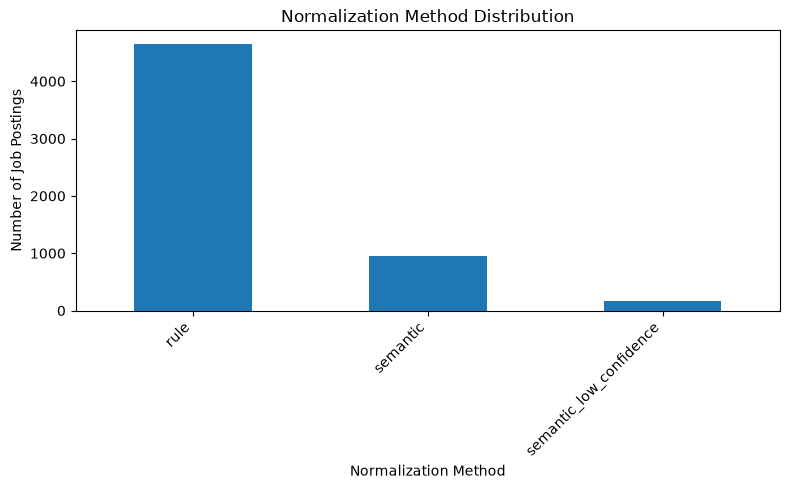

In [72]:
plt.figure(figsize=(8, 5))

method_counts.plot(kind="bar")

plt.title("Normalization Method Distribution")
plt.xlabel("Normalization Method")
plt.ylabel("Number of Job Postings")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 7.13 Check normalized title distribution

In [73]:
normalized_counts = (
    df_normalized["normalized_title"]
    .value_counts()
)

display(normalized_counts)

normalized_title
AI Engineer                  1329
Data Scientist                969
Machine Learning Engineer     822
Software Engineer             439
LLM Engineer                  396
Research Scientist            382
MLOps Engineer                251
Computer Vision Engineer      240
Product / Management          219
Other                         166
Consultant                    117
Data Engineer                 116
NLP Engineer                  114
Solutions Architect            79
DevOps Engineer                72
Platform Engineer              62
Name: count, dtype: int64

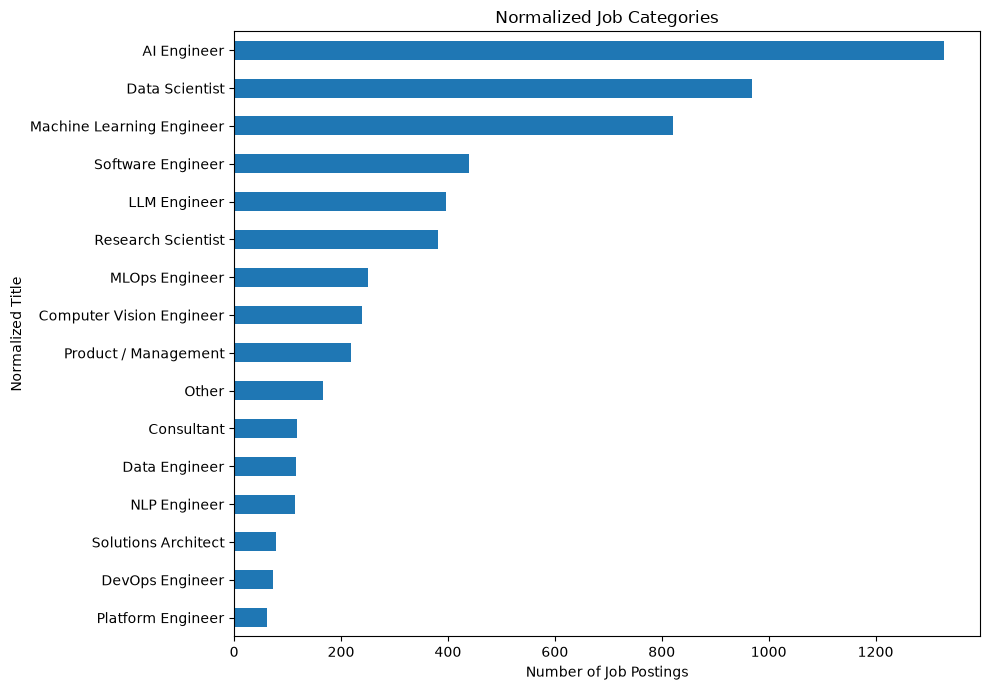

In [74]:
plt.figure(figsize=(10, 7))

normalized_counts.sort_values().plot(kind="barh")

plt.title("Normalized Job Categories")
plt.xlabel("Number of Job Postings")
plt.ylabel("Normalized Title")

plt.tight_layout()
plt.show()

## 7.14 Review low-confidence matches

In [75]:
low_confidence_matches = (
    df_normalized[
        df_normalized["normalization_method"]
        .isin([
            "semantic",
            "semantic_low_confidence"
        ])
    ]
    .sort_values("title_similarity")
)

display(
    low_confidence_matches[
        [
            "job_title",
            "normalized_title",
            "title_similarity",
            "normalization_method"
        ]
    ]
    .head(50)
)

,job_title,normalized_title,title_similarity,normalization_method
4405,Life Scientist - Vegetation Structure & LiDAR ...,Other,0.197085,semantic_low_confidence
3859,"Child, Family, and School Social Worker",Other,0.209069,semantic_low_confidence
3942,Voice Actor - German Speakers,Other,0.210564,semantic_low_confidence
5638,Senior Account Executive - Germany,Other,0.210929,semantic_low_confidence
5610,Founding VC Investor,Other,0.211633,semantic_low_confidence
5554,"External Affairs, Germany",Other,0.225573,semantic_low_confidence
5719,Bindery Machine Operator,Other,0.239505,semantic_low_confidence
1084,"Travel Nurse RN - Telemetry - $2,147 per week",Other,0.239737,semantic_low_confidence
5702,Trial Attorney (Enforcement and Affirmative Li...,Other,0.245366,semantic_low_confidence
1309,$XXX/45min Paid Market Research Study for CIO ...,Other,0.248816,semantic_low_confidence


## 7.15 Inspect titles classified as Other

In [76]:
other_titles = (
    df_normalized.loc[
        df_normalized["normalized_title"] == "Other",
        "job_title"
    ]
    .value_counts()
    .head(1000)
)

display(other_titles)

job_title
$XXX/45min Paid Market Research Study for CIO in the Finance Sector                       24
Operating System Expert (Windows, MacOS, Linux)                                            7
STEM PhDs - Math                                                                           3
Judicial Law Clerks                                                                        2
Account Executive                                                                          2
                                                                                          ..
Supervisory Physical Scientist (Firearms) - Direct Hire (Open Continuous Announcement)     1
Clinical Laboratory Scientist - Micro-Molecular                                            1
Clinical Laboratory Scientist (Technical Specialist) - Blood Bank                          1
Clinical Laboratory Scientist - Chemistry/Urinalysis                                       1
Lead Clinical Laboratory Scientist - Toxicology             

## 7.16 Add ESCO occupation

In [77]:
df_normalized["esco_occupation"] = (
    df_normalized["normalized_title"]
    .map(ESCO_MAPPING)
)

## 7.17 Inspect final normalized dataset

In [78]:
display(
    df_normalized[
        [
            "job_title",
            "normalized_title",
            "esco_occupation",
            "title_similarity",
            "normalization_method"
        ]
    ]
    .sample(
        20,
        random_state=42
    )
)

,job_title,normalized_title,esco_occupation,title_similarity,normalization_method
426,Data Scientist,Data Scientist,data scientist,1.000000,rule
1181,Computer Vision Engineer,Computer Vision Engineer,computer vision engineer,1.000000,rule
5291,Consultant for Digital Transformation & AI – I...,Consultant,ict consultant,1.000000,rule
3835,Physics Researcher (Python) - Freelance AI Tra...,Research Scientist,research engineer,1.000000,rule
3053,Senior AI Platform Engineer,Platform Engineer,cloud engineer,1.000000,rule
4938,Databricks Platform Engineer,Platform Engineer,cloud engineer,1.000000,rule
3821,"Senior Manager of Research Engineering, AI",Research Scientist,research engineer,1.000000,rule
1328,Machine Learning Engineer III – Computer Visio...,Computer Vision Engineer,computer vision engineer,1.000000,rule
4478,Medicine Specialist - Freelance AI Trainer Pro...,AI Engineer,artificial intelligence engineer,0.500178,semantic
2209,Data Scientist,Data Scientist,data scientist,1.000000,rule


## 7.18 Create normalization summary table

In [79]:
normalization_summary = pd.DataFrame({
    "metric": [
        "Total job postings",
        "Unique raw job titles",
        "Standard title categories",
        "Rule-based matches",
        "Semantic matches",
        "Low-confidence semantic matches",
        "Titles classified as Other"
    ],
    "value": [
        len(df_normalized),
        df_normalized["job_title"].nunique(),
        df_normalized["normalized_title"].nunique(),
        (df_normalized["normalization_method"] == "rule").sum(),
        (df_normalized["normalization_method"] == "semantic").sum(),
        (df_normalized["normalization_method"] == "semantic_low_confidence").sum(),
        (df_normalized["normalized_title"] == "Other").sum()
    ]
})

display(normalization_summary)

,metric,value
0,Total job postings,5773
1,Unique raw job titles,2773
2,Standard title categories,16
3,Rule-based matches,4656
4,Semantic matches,951
5,Low-confidence semantic matches,166
6,Titles classified as Other,166


## 7.19 Save normalized dataset

In [80]:
NORMALIZED_DATASET_PATH = (
    DATA_DIR
    / "data"
    / "JobMarket2026"
    / "jobs_normalized.csv"
)

df_normalized.to_csv(
    NORMALIZED_DATASET_PATH,
    index=False
)

print("Normalized dataset saved.")
print("Output path:", NORMALIZED_DATASET_PATH)
print("Final shape:", df_normalized.shape)

Normalized dataset saved.
Output path: C:\Users\jerem\job_analysis\2026_ai_job_market_analysis\data\JobMarket2026\jobs_normalized.csv
Final shape: (5773, 29)


## Section 7 Summary

This section normalized raw job titles into standardized job categories.

The main steps were:

1. A working copy of the cleaned dataset was created.
2. The job title taxonomy from Section 5 was loaded.
3. The ESCO mapping from Section 6 was loaded.
4. A rule-based normalization system was created for clear job titles.
5. A semantic similarity fallback was added for ambiguous job titles.
6. Each job title received:
   - a normalized title
   - a similarity score
   - a normalization method
7. Low-confidence semantic matches were assigned to `Other`.
8. Each normalized title was linked to an ESCO occupation.
9. The final normalized dataset was saved as:

`jobs_normalized.csv`

The result is a cleaner dataset where thousands of raw job titles are reduced into a smaller and more consistent set of job categories.

This normalized title column will be used in the next sections to build skill taxonomies and infer missing skills.

# 8. Hybrid Skill Taxonomy Construction

This section builds a hybrid skill taxonomy for each normalized job category.

The taxonomy combines two sources:

1. ESCO skills linked to official ESCO occupations.
2. Market skills observed directly in the job postings.

ESCO provides structured occupation knowledge, but it can be too broad or outdated.

Market skills are more modern and closer to the current AI job market, but they are incomplete because many job postings have missing `required_skills`.

The goal is to combine both sources into a cleaner and more useful skill taxonomy.

## 8.1 Load normalized dataset

In [81]:
NORMALIZED_DATASET_PATH = (
    DATA_DIR
    / "data"
    / "JobMarket2026"
    / "jobs_normalized.csv"
)

df_taxonomy = pd.read_csv(NORMALIZED_DATASET_PATH)

print("Normalized dataset loaded.")
print("Shape:", df_taxonomy.shape)

Normalized dataset loaded.
Shape: (5773, 29)


## 8.2 Load ESCO skill files

In [82]:
ESCO_EN_PATH = (
    DATA_DIR
    / "data"
    / "ESCO"
    / "EscoDBen"
)

df_skills = pd.read_csv(
    ESCO_EN_PATH / "skills_en.csv"
)

df_occ_skill = pd.read_csv(
    ESCO_EN_PATH / "occupationSkillRelations_en.csv"
)

print("ESCO skills:", df_skills.shape)
print("ESCO occupation-skill relations:", df_occ_skill.shape)

ESCO skills: (13960, 13)
ESCO occupation-skill relations: (126051, 6)


## 8.3 Build ESCO occupation-to-skills mapping

In [83]:
df_occ_skill_clean = df_occ_skill[
    [
        "occupationLabel",
        "skillLabel"
    ]
].dropna().copy()

df_occ_skill_clean["occupation_clean"] = (
    df_occ_skill_clean["occupationLabel"]
    .str.lower()
    .str.strip()
)

df_occ_skill_clean["skill_clean"] = (
    df_occ_skill_clean["skillLabel"]
    .str.lower()
    .str.strip()
)

occupation_to_skills = (
    df_occ_skill_clean
    .groupby("occupation_clean")["skill_clean"]
    .apply(list)
    .to_dict()
)

print("ESCO occupations with skills:", len(occupation_to_skills))

ESCO occupations with skills: 3039


## 8.4 Define skill name normalization

In [84]:
SKILL_REPLACEMENTS = {
    "python": "python",
    "python ": "python",
    "r": "r",
    "java": "java",
    "javascript": "javascript",
    "typescript": "typescript",
    "c++": "c++",
    "c#": "c#",

    "natural language processing": "nlp",
    "principles of artificial intelligence": "artificial intelligence",
    "artificial neural networks": "neural networks",
    "utilise machine learning": "machine learning",

    "resource description framework query language": "sparql",
    "query languages": "sql",
    "use query languages": "sql",

    "use databases": "databases",
    "database development tools": "databases",

    "data models": "data modeling",
    "create data models": "data modeling",
    "create data sets": "data preparation",
    "normalise data": "data normalization",
    "perform data cleansing": "data cleaning",

    "data visualisation software": "data visualization",
    "deliver visual presentation of data": "data visualization",

    "develop with cloud services": "cloud",
    "cloud technologies": "cloud",

    "develop computer vision system": "computer vision",
    "image recognition": "computer vision",
    "digital image processing": "computer vision",

    "statistical modeling techniques": "statistical modeling",
    "apply statistical analysis techniques": "statistical analysis",

    "task algorithmisation": "algorithms"
}


def normalize_skill_name(skill):
    """
    Normalize a skill name so that ESCO skills and market skills
    can be compared more easily.
    """

    if pd.isna(skill):
        return ""

    skill = str(skill).lower().strip()

    skill = (
        skill.replace("(computer programming)", "")
        .replace("(programming language)", "")
        .replace("programming language", "")
        .strip()
    )

    skill = re.sub(
        r"\s+",
        " ",
        skill
    )

    return SKILL_REPLACEMENTS.get(
        skill,
        skill
    )

## 8.5 Define relevant AI market skill filter

In [85]:
ESCO_BLACKLIST = {
    "cobol",
    "pascal",
    "smalltalk",
    "vbscript",
    "visual basic",
    "sap r3",
    "scratch",
    "common lisp",
    "lisp",
    "prolog",
    "openedge advanced business language",
    "coffeescript",
    "assembly",
    "objective-c",
    "perl",
    "ruby",
    "erlang",
    "groovy",
    "microsoft visual c++",
    "screen reader",
    "use technical drawing software",
    "technical drawings",
    "use word processing software",
    "speak different languages"
}


EXACT_RELEVANT_SKILLS = {
    "python",
    "r",
    "sql",
    "java",
    "javascript",
    "typescript",
    "c++",
    "c#",
    "scala",
    "go",

    "aws",
    "azure",
    "gcp",
    "docker",
    "kubernetes",
    "spark",
    "hadoop",
    "airflow",
    "databricks",
    "snowflake",

    "pytorch",
    "tensorflow",
    "scikit-learn",
    "sklearn",
    "transformers",
    "mlflow",

    "rag",
    "llm",
    "nlp",
    "openai",
    "langchain",
    "mlops",
    "devops",

    "databases",
    "algorithms",
    "statistics"
}


RELEVANT_SKILL_PHRASES = [
    "machine learning",
    "deep learning",
    "artificial intelligence",
    "neural network",
    "computer vision",
    "natural language",
    "large language model",

    "data science",
    "data mining",
    "data engineering",
    "data modeling",
    "data cleaning",
    "data preparation",
    "data visualization",
    "data processing",
    "unstructured data",
    "information extraction",

    "statistical",
    "predictive",
    "recommender",

    "cloud",
    "database",
    "big data",
    "software development",
    "software engineering",

    "computational linguistics",
    "machine translation",
    "speech recognition",
    "semantics"
]


def tokenize_skill(skill):
    """
    Split a skill into clean tokens.

    This prevents short skills like 'r' from matching inside
    unrelated words such as 'project' or 'research'.
    """

    return set(
        re.findall(
            r"[a-z0-9+#]+",
            str(skill).lower()
        )
    )


def is_relevant_ai_skill(skill):
    """
    Keep only skills relevant to AI, data, software, cloud,
    or modern technical job market analysis.
    """

    skill = normalize_skill_name(skill)

    if skill == "":
        return False

    if skill in ESCO_BLACKLIST:
        return False

    if skill in EXACT_RELEVANT_SKILLS:
        return True

    tokens = tokenize_skill(skill)

    if tokens.intersection(EXACT_RELEVANT_SKILLS):
        return True

    return any(
        phrase in skill
        for phrase in RELEVANT_SKILL_PHRASES
    )

## 8.6 Retrieve filtered ESCO skills

In [86]:
def get_filtered_esco_skills(occupation):
    """
    Retrieve ESCO skills for a given occupation and keep only
    the skills relevant to this AI job market analysis.
    """

    if pd.isna(occupation):
        return []

    occupation = (
        str(occupation)
        .lower()
        .strip()
    )

    raw_skills = occupation_to_skills.get(
        occupation,
        []
    )

    clean_skills = []

    for skill in raw_skills:
        skill = normalize_skill_name(skill)

        if is_relevant_ai_skill(skill):
            clean_skills.append(skill)

    return sorted(
        list(set(clean_skills))
    )

## 8.7 Inspect ESCO skills for key occupations

In [87]:
ESCO_TEST_OCCUPATIONS = [
    "artificial intelligence engineer",
    "data scientist",
    "data engineer",
    "language engineer",
    "cloud devops engineer"
]

esco_skill_check = []

for occupation in ESCO_TEST_OCCUPATIONS:
    skills = get_filtered_esco_skills(occupation)

    esco_skill_check.append({
        "esco_occupation": occupation,
        "n_filtered_skills": len(skills),
        "sample_skills": skills[:15]
    })

esco_skill_check = pd.DataFrame(esco_skill_check)

display(esco_skill_check)

,esco_occupation,n_filtered_skills,sample_skills
0,artificial intelligence engineer,29,"[algorithms, analyse big data, artificial inte..."
1,data scientist,20,"[build recommender systems, computer vision, d..."
2,data engineer,13,"[analyse pipeline database information, cloud,..."
3,language engineer,8,"[algorithms, artificial intelligence, computat..."
4,cloud devops engineer,14,"[automate cloud tasks, cloud, cloud monitoring..."


## 8.8 Normalize market skills from job postings

In [88]:
def split_and_normalize_market_skills(skill_text):
    """
    Split the skills already present in the dataset and normalize them.
    """

    if pd.isna(skill_text):
        return []

    skills = str(skill_text).split(",")

    clean_skills = []

    for skill in skills:
        skill = normalize_skill_name(skill)

        if skill != "":
            clean_skills.append(skill)

    return sorted(
        list(set(clean_skills))
    )


df_taxonomy["market_skills_list"] = (
    df_taxonomy["required_skills"]
    .apply(split_and_normalize_market_skills)
)

## 8.9 Build market skill taxonomy

In [89]:
TAXONOMY_PATH = (
    DATA_DIR
    / "data"
    / "JobMarket2026"
    / "job_title_taxonomy.csv"
)

taxonomy_df = pd.read_csv(TAXONOMY_PATH)

STANDARD_TITLES = taxonomy_df["standard_title"].tolist()

In [90]:
MAX_MARKET_SKILLS_PER_TITLE = 30

market_skill_taxonomy = {}

for title in STANDARD_TITLES:

    subset = df_taxonomy[
        df_taxonomy["normalized_title"] == title
    ]

    skills = []

    for skill_list in subset["market_skills_list"]:
        skills.extend(skill_list)

    counter = Counter(skills)

    market_skill_taxonomy[title] = [
        skill
        for skill, count in counter.most_common(
            MAX_MARKET_SKILLS_PER_TITLE
        )
    ]

## 8.10 Inspect market skills

In [91]:
for title in [
    "AI Engineer",
    "Data Scientist",
    "LLM Engineer",
    "MLOps Engineer"
]:

    print("\n" + "=" * 60)
    print(title)
    print("=" * 60)
    print(market_skill_taxonomy.get(title, [])[:20])


AI Engineer
['python', 'azure', 'rag', 'sql', 'openai', 'nlp', 'r', 'aws', 'fine-tuning', 'computer vision', 'langchain', 'gcp', 'docker', 'pytorch', 'tensorflow', 'mlflow', 'transformers', 'kubernetes', 'hadoop', 'scikit-learn']

Data Scientist
['python', 'r', 'sql', 'aws', 'nlp', 'azure', 'computer vision', 'rag', 'spark', 'gcp', 'pytorch', 'tensorflow', 'docker', 'hadoop', 'scikit-learn', 'langchain', 'transformers']

LLM Engineer
['python', 'rag', 'fine-tuning', 'azure', 'nlp', 'openai', 'aws', 'r', 'computer vision', 'transformers', 'pytorch', 'gcp', 'langchain', 'spark', 'scikit-learn', 'docker']

MLOps Engineer
['aws', 'azure', 'python', 'kubernetes', 'openai', 'nlp', 'docker', 'gcp', 'sql', 'pytorch', 'spark', 'mlflow', 'r', 'transformers', 'scikit-learn', 'tensorflow', 'langchain', 'hadoop', 'rag', 'airflow']


## 8.11 Build hybrid skill taxonomy

In [92]:
hybrid_skill_taxonomy = {}

for title in STANDARD_TITLES:

    if title == "Other":
        hybrid_skill_taxonomy[title] = {
            "esco_occupation": "Other",
            "esco_skills": [],
            "market_skills": [],
            "combined_skills": []
        }

        continue

    subset = df_taxonomy[
        df_taxonomy["normalized_title"] == title
    ]

    if subset.empty:
        hybrid_skill_taxonomy[title] = {
            "esco_occupation": pd.NA,
            "esco_skills": [],
            "market_skills": [],
            "combined_skills": []
        }

        continue

    esco_occupation = (
        subset["esco_occupation"]
        .dropna()
        .mode()
        .iloc[0]
    )

    esco_skills = get_filtered_esco_skills(
        esco_occupation
    )

    market_skills = market_skill_taxonomy.get(
        title,
        []
    )

    combined_skills = sorted(
        list(
            set(esco_skills + market_skills)
        )
    )

    hybrid_skill_taxonomy[title] = {
        "esco_occupation": esco_occupation,
        "esco_skills": esco_skills,
        "market_skills": market_skills,
        "combined_skills": combined_skills
    }

## 8.12 Convert taxonomy to DataFrame

In [93]:
df_hybrid_taxonomy = (
    pd.DataFrame
    .from_dict(
        hybrid_skill_taxonomy,
        orient="index"
    )
    .reset_index()
    .rename(
        columns={
            "index": "normalized_title"
        }
    )
)

df_hybrid_taxonomy["n_esco_skills"] = (
    df_hybrid_taxonomy["esco_skills"]
    .apply(len)
)

df_hybrid_taxonomy["n_market_skills"] = (
    df_hybrid_taxonomy["market_skills"]
    .apply(len)
)

df_hybrid_taxonomy["n_combined_skills"] = (
    df_hybrid_taxonomy["combined_skills"]
    .apply(len)
)

display(df_hybrid_taxonomy.head())

,normalized_title,esco_occupation,esco_skills,market_skills,combined_skills,n_esco_skills,n_market_skills,n_combined_skills
0,AI Engineer,artificial intelligence engineer,"[algorithms, analyse big data, artificial inte...","[python, azure, rag, sql, openai, nlp, r, aws,...","[algorithms, analyse big data, artificial inte...",29,21,47
1,Machine Learning Engineer,artificial intelligence engineer,"[algorithms, analyse big data, artificial inte...","[python, computer vision, nlp, rag, kubernetes...","[airflow, algorithms, analyse big data, artifi...",29,19,45
2,Data Scientist,data scientist,"[build recommender systems, computer vision, d...","[python, r, sql, aws, nlp, azure, computer vis...","[aws, azure, build recommender systems, comput...",20,17,34
3,Data Engineer,data engineer,"[analyse pipeline database information, cloud,...","[gcp, aws, azure, openai, spark, sql, python, ...","[airflow, analyse pipeline database informatio...",13,10,23
4,Research Scientist,research engineer,[],"[python, r, computer vision, rag, transformers...","[computer vision, nlp, openai, python, pytorch...",0,10,10


## 8.13 Check taxonomy size by job category

In [94]:
taxonomy_size_check = (
    df_hybrid_taxonomy[
        [
            "normalized_title",
            "esco_occupation",
            "n_esco_skills",
            "n_market_skills",
            "n_combined_skills"
        ]
    ]
    .sort_values(
        "n_combined_skills",
        ascending=False
    )
)

display(taxonomy_size_check)

,normalized_title,esco_occupation,n_esco_skills,n_market_skills,n_combined_skills
0,AI Engineer,artificial intelligence engineer,29,21,47
1,Machine Learning Engineer,artificial intelligence engineer,29,19,45
2,Data Scientist,data scientist,20,17,34
8,MLOps Engineer,cloud devops engineer,14,20,34
12,Solutions Architect,cloud architect,10,14,24
7,LLM Engineer,language engineer,8,16,23
5,Computer Vision Engineer,computer vision engineer,16,9,23
3,Data Engineer,data engineer,13,10,23
10,Platform Engineer,cloud engineer,18,6,23
11,Software Engineer,software developer,15,11,22


## 8.14 Visualize hybrid taxonomy size

<Figure size 1000x700 with 0 Axes>

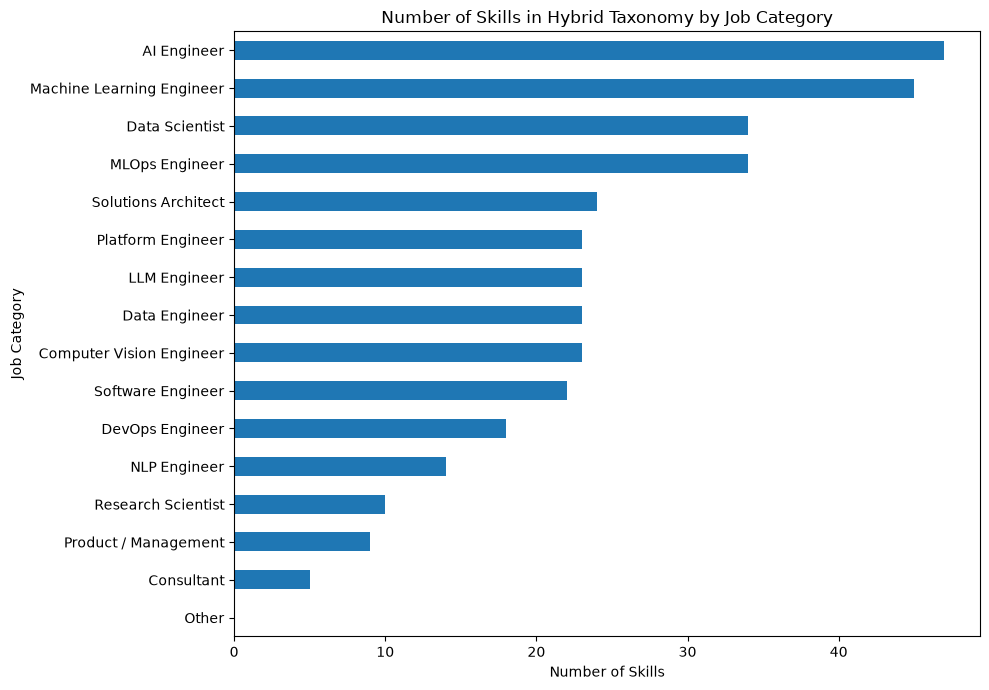

In [95]:
plt.figure(figsize=(10, 7))

taxonomy_size_check.sort_values(
    "n_combined_skills"
).plot(
    x="normalized_title",
    y="n_combined_skills",
    kind="barh",
    legend=False,
    figsize=(10, 7)
)

plt.title("Number of Skills in Hybrid Taxonomy by Job Category")
plt.xlabel("Number of Skills")
plt.ylabel("Job Category")

plt.tight_layout()
plt.show()

## 8.15 Compare ESCO skills and market skills

In [96]:
source_comparison = (
    df_hybrid_taxonomy[
        [
            "normalized_title",
            "n_esco_skills",
            "n_market_skills"
        ]
    ]
    .sort_values(
        "n_esco_skills",
        ascending=False
    )
)

display(source_comparison)

,normalized_title,n_esco_skills,n_market_skills
0,AI Engineer,29,21
1,Machine Learning Engineer,29,19
2,Data Scientist,20,17
10,Platform Engineer,18,6
5,Computer Vision Engineer,16,9
11,Software Engineer,15,11
8,MLOps Engineer,14,20
9,DevOps Engineer,14,4
3,Data Engineer,13,10
12,Solutions Architect,10,14


<Figure size 1000x700 with 0 Axes>

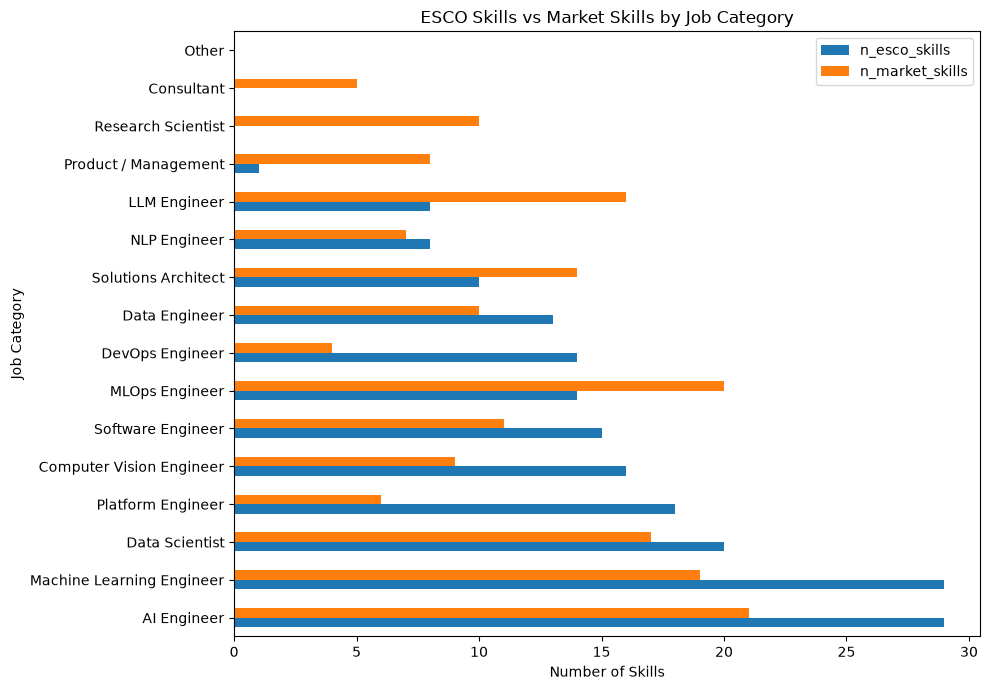

In [97]:
plt.figure(figsize=(10, 7))

source_comparison.set_index(
    "normalized_title"
)[
    [
        "n_esco_skills",
        "n_market_skills"
    ]
].plot(
    kind="barh",
    figsize=(10, 7)
)

plt.title("ESCO Skills vs Market Skills by Job Category")
plt.xlabel("Number of Skills")
plt.ylabel("Job Category")

plt.tight_layout()
plt.show()

## 8.16 Check for outdated skills

In [98]:
outdated_examples = [
    "cobol",
    "pascal",
    "smalltalk",
    "visual basic",
    "sap r3"
]

outdated_skill_check = []

for skill in outdated_examples:

    found = any(
        skill in skills
        for skills in df_hybrid_taxonomy["combined_skills"]
    )

    outdated_skill_check.append({
        "skill": skill,
        "found_in_taxonomy": found
    })

outdated_skill_check = pd.DataFrame(outdated_skill_check)

display(outdated_skill_check)

,skill,found_in_taxonomy
0,cobol,False
1,pascal,False
2,smalltalk,False
3,visual basic,False
4,sap r3,False


## 8.17 Inspect important categories

In [99]:
for title in [
    "AI Engineer",
    "Data Scientist",
    "LLM Engineer",
    "MLOps Engineer"
]:

    print("\n" + "=" * 60)
    print(title)
    print("=" * 60)

    skills = (
        df_hybrid_taxonomy.loc[
            df_hybrid_taxonomy["normalized_title"] == title,
            "combined_skills"
        ]
        .iloc[0]
    )

    print(skills[:40])


AI Engineer
['algorithms', 'analyse big data', 'artificial intelligence', 'aws', 'azure', 'build predictive models', 'build recommender systems', 'c#', 'c++', 'computer vision', 'data mining', 'data modeling', 'data preparation', 'data science', 'data visualization', 'databases', 'deep learning', 'design database scheme', 'develop statistical software', 'digital data processing', 'docker', 'fine-tuning', 'gcp', 'hadoop', 'information extraction', 'java', 'javascript', 'kubernetes', 'langchain', 'machine learning', 'mlflow', 'neural networks', 'nlp', 'openai', 'python', 'pytorch', 'r', 'rag', 'scala', 'scikit-learn']

Data Scientist
['aws', 'azure', 'build recommender systems', 'computer vision', 'data cleaning', 'data engineering', 'data mining', 'data modeling', 'data science', 'data visualization', 'databases', 'design database in the cloud', 'design database scheme', 'develop data processing applications', 'docker', 'gcp', 'hadoop', 'information extraction', 'langchain', 'nlp', 'pe

## 8.18 Create section summary table

In [100]:
section_8_summary = pd.DataFrame({
    "metric": [
        "Job categories",
        "Categories with combined skills",
        "Categories with no combined skills",
        "Average ESCO skills per category",
        "Average market skills per category",
        "Average combined skills per category"
    ],
    "value": [
        len(df_hybrid_taxonomy),
        (df_hybrid_taxonomy["n_combined_skills"] > 0).sum(),
        (df_hybrid_taxonomy["n_combined_skills"] == 0).sum(),
        round(df_hybrid_taxonomy["n_esco_skills"].mean(), 2),
        round(df_hybrid_taxonomy["n_market_skills"].mean(), 2),
        round(df_hybrid_taxonomy["n_combined_skills"].mean(), 2)
    ]
})

display(section_8_summary)

,metric,value
0,Job categories,16.00
1,Categories with combined skills,15.00
2,Categories with no combined skills,1.00
3,Average ESCO skills per category,12.19
4,Average market skills per category,11.06
5,Average combined skills per category,22.12


## 8.19 Save hybrid skill taxonomy

In [101]:
HYBRID_TAXONOMY_PATH = (
    DATA_DIR
    / "data"
    / "JobMarket2026"
    / "hybrid_skill_taxonomy.csv"
)

df_hybrid_taxonomy.to_csv(
    HYBRID_TAXONOMY_PATH,
    index=False
)

print("Hybrid skill taxonomy saved.")
print("Output path:", HYBRID_TAXONOMY_PATH)

Hybrid skill taxonomy saved.
Output path: C:\Users\jerem\job_analysis\2026_ai_job_market_analysis\data\JobMarket2026\hybrid_skill_taxonomy.csv


## Section 8 Summary

This section created the hybrid skill taxonomy used for skill inference.

The main steps were:

1. The normalized job dataset was loaded.
2. ESCO skill files were loaded.
3. ESCO occupation-skill relations were converted into an occupation-to-skills dictionary.
4. ESCO skill names were normalized.
5. Outdated or irrelevant ESCO skills were removed.
6. A safer relevance filter was created to avoid false matches from short skills like `r`.
7. Existing market skills from job postings were normalized.
8. A market skill taxonomy was built for each normalized job category.
9. ESCO skills and market skills were combined into one hybrid taxonomy.
10. The final taxonomy was saved as:

`hybrid_skill_taxonomy.csv`

The final taxonomy contains, for each job category:

- the ESCO occupation
- the filtered ESCO skills
- the market skills observed in job postings
- the combined hybrid skill list

This hybrid taxonomy will be used in the next section to infer missing skills.

# 9. Similarity-Based Skill Inference

This section infers missing skills using similar job postings.

The dataset contains many rows where `required_skills` is missing. The goal is not to generate random skills, but to infer plausible skills using controlled constraints.

The inference uses three main rules:

1. The job must belong to the same normalized job category.
2. The job text must be similar to other job postings with known skills.
3. The inferred skills must exist in the hybrid skill taxonomy created in Section 8.

This section also handles multilingual data.

German skills are mapped to English using the German and English ESCO skill files.

German job descriptions are not translated manually. Instead, they are processed with a multilingual SentenceTransformer model, which allows German, English and French job descriptions to be compared in the same embedding space.

To improve performance, this section also uses:

- shorter similarity text
- cached embeddings
- batch embedding
- category-level progress messages
- timers to measure slow steps

The final result is a completed skills column that preserves original skills when available and uses inferred skills only when the original skills are missing.

## 9.1 Load required datasets

In [102]:
NORMALIZED_DATASET_PATH = (
    DATA_DIR
    / "data"
    / "JobMarket2026"
    / "jobs_normalized.csv"
)

HYBRID_TAXONOMY_PATH = (
    DATA_DIR
    / "data"
    / "JobMarket2026"
    / "hybrid_skill_taxonomy.csv"
)

df_inference = pd.read_csv(NORMALIZED_DATASET_PATH)
df_hybrid_taxonomy = pd.read_csv(HYBRID_TAXONOMY_PATH)

print("Normalized dataset:", df_inference.shape)
print("Hybrid taxonomy:", df_hybrid_taxonomy.shape)

Normalized dataset: (5773, 29)
Hybrid taxonomy: (16, 8)


## 9.2 Convert saved list columns back to Python lists

In [103]:
import ast


def parse_list_value(value):
    """
    Convert a saved CSV list back into a real Python list.
    """

    if isinstance(value, list):
        return value

    if pd.isna(value):
        return []

    try:
        parsed_value = ast.literal_eval(str(value))

        if isinstance(parsed_value, list):
            return parsed_value

        return []

    except Exception:
        return []


LIST_COLUMNS = [
    "esco_skills",
    "market_skills",
    "combined_skills"
]

for column in LIST_COLUMNS:
    df_hybrid_taxonomy[column] = (
        df_hybrid_taxonomy[column]
        .apply(parse_list_value)
    )

## 9.3 Load German ESCO skills

In [104]:
ESCO_EN_PATH = (
    DATA_DIR
    / "data"
    / "ESCO"
    / "EscoDBen"
)

ESCO_DE_PATH = (
    DATA_DIR
    / "data"
    / "ESCO"
    / "EscoDBde"
)

df_skills_en = pd.read_csv(
    ESCO_EN_PATH / "skills_en.csv"
)

df_skills_de = pd.read_csv(
    ESCO_DE_PATH / "skills_de.csv"
)

print("English ESCO skills:", df_skills_en.shape)
print("German ESCO skills:", df_skills_de.shape)

display(df_skills_en.head())
display(df_skills_de.head())

English ESCO skills: (13960, 13)
German ESCO skills: (13960, 13)


,conceptType,conceptUri,skillType,reuseLevel,preferredLabel,altLabels,hiddenLabels,status,modifiedDate,scopeNote,definition,inScheme,description
0,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/0005c151-5b5a...,skill/competence,sector-specific,manage musical staff,manage music staff\ncoordinate duties of music...,NaN,released,2023-11-30T15:53:37.136Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/skil...,Assign and manage staff tasks in areas such as...
1,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/00064735-8fad...,skill/competence,occupation-specific,supervise correctional procedures,manage prison procedures\nmonitor correctional...,NaN,released,2023-11-30T15:04:00.689Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/skil...,Supervise the operations of a correctional fac...
2,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/000709ed-2be5...,skill/competence,sector-specific,apply anti-oppressive practices,make use of anti-oppressive practices\nuse ant...,NaN,released,2023-11-28T10:45:53.54Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/skil...,"Identify oppression in societies, economies, c..."
3,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/0007bdc2-dd15...,skill/competence,sector-specific,control compliance of railway vehicles regulat...,checking compliance with rolling stock regulat...,NaN,released,2023-11-30T16:29:18.273Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/skil...,"Inspect rolling stock, components and systems ..."
4,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/00090cc1-1f27...,skill/competence,cross-sector,identify available services,determine available services\nclassify availab...,NaN,released,2023-11-28T10:38:49.206Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/skil...,Identify the different services available for ...


,conceptType,conceptUri,skillType,reuseLevel,preferredLabel,altLabels,hiddenLabels,status,modifiedDate,scopeNote,definition,inScheme,description
0,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/0005c151-5b5a...,skill/competence,sector-specific,Musikpersonal verwalten,NaN,NaN,released,2023-11-30T15:53:37.136Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/skil...,Zuweisen und Verwalten der Aufgaben des Person...
1,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/00064735-8fad...,skill/competence,occupation-specific,Strafvollzugsverfahren beaufsichtigen,NaN,NaN,released,2023-11-30T15:04:00.689Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/skil...,Überwachen des Betriebs einer Justizvollzugsan...
2,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/000709ed-2be5...,skill/competence,sector-specific,nicht unterdrückende Praktiken anwenden,NaN,NaN,released,2023-11-28T10:45:53.54Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/skil...,"Ermitteln von Repressionen in Gesellschaften, ..."
3,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/0007bdc2-dd15...,skill/competence,sector-specific,Einhaltung von Vorschriften von Eisenbahnfahrz...,NaN,NaN,released,2023-11-30T16:29:18.273Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/skil...,"Kontrollieren von Fahrzeugen, Komponenten und ..."
4,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/00090cc1-1f27...,skill/competence,cross-sector,verfügbare Dienste ermitteln,NaN,NaN,released,2023-11-28T10:38:49.206Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/skil...,Ermitteln der verschiedenen verfügbaren Dienst...


## 9.4 Build German-to-English skill mapping

In [105]:
def split_esco_labels(text):
    """
    Split ESCO label fields into individual labels.

    ESCO alternative labels can contain multiple labels
    separated by new lines or semicolons.
    """

    if pd.isna(text):
        return []

    labels = re.split(
        r"[\n;|]",
        str(text)
    )

    return [
        label.strip().lower()
        for label in labels
        if label.strip()
    ]


def clean_skill_label(label):
    """
    Clean a skill label before using it as a dictionary key.
    """

    label = str(label).lower().strip()

    label = re.sub(
        r"\s+",
        " ",
        label
    )

    return label


de_en_skills = df_skills_de.merge(
    df_skills_en,
    on="conceptUri",
    suffixes=("_de", "_en")
)

german_to_english_skill = {}

for _, row in de_en_skills.iterrows():

    english_skill = normalize_skill_name(
        row["preferredLabel_en"]
    )

    german_labels = []

    german_labels.extend(
        split_esco_labels(row.get("preferredLabel_de", ""))
    )

    german_labels.extend(
        split_esco_labels(row.get("altLabels_de", ""))
    )

    german_labels.extend(
        split_esco_labels(row.get("hiddenLabels_de", ""))
    )

    for german_label in german_labels:

        german_label = clean_skill_label(
            german_label
        )

        if german_label != "":
            german_to_english_skill[german_label] = english_skill


print("German skill labels mapped to English:", len(german_to_english_skill))

German skill labels mapped to English: 23207


## 9.5 Normalize skills with multilingual support

In [106]:
def normalize_skill_multilingual(skill):
    """
    Normalize a skill that may be written in English or German.

    Step 1:
    Clean the skill text.

    Step 2:
    If the skill exists in the German ESCO mapping,
    convert it to the English ESCO label.

    Step 3:
    Otherwise, apply the regular English skill normalization.
    """

    if pd.isna(skill):
        return ""

    skill = clean_skill_label(skill)

    if skill in german_to_english_skill:
        return german_to_english_skill[skill]

    return normalize_skill_name(skill)

## 9.6 Create clean original skill lists

In [107]:
def split_and_normalize_skills(skill_text):
    """
    Split the original required_skills column into a clean list.

    This function supports English and German skill names.
    """

    if pd.isna(skill_text):
        return []

    raw_skills = re.split(
        r"[,;|]",
        str(skill_text)
    )

    clean_skills = []

    for skill in raw_skills:

        skill = normalize_skill_multilingual(skill)

        if skill != "":
            clean_skills.append(skill)

    return sorted(
        list(set(clean_skills))
    )


df_inference["original_skills_list"] = (
    df_inference["required_skills"]
    .apply(split_and_normalize_skills)
)

## 9.7 Identify rows with missing skills

In [108]:
df_inference["has_original_skills"] = (
    df_inference["original_skills_list"]
    .apply(len)
    .gt(0)
)

rows_with_original_skills = (
    df_inference["has_original_skills"]
    .sum()
)

rows_missing_skills = (
    ~df_inference["has_original_skills"]
).sum()

print("Rows with original skills:", rows_with_original_skills)
print("Rows missing skills:", rows_missing_skills)

Rows with original skills: 1084
Rows missing skills: 4689


## 9.8 Prepare multilingual text for similarity search

In [109]:
# 9.8 Prepare faster multilingual text for similarity search

def clean_similarity_text(text):
    """
    Clean text before embedding.

    The goal is not to translate the text.
    The goal is only to remove excessive spaces.
    """

    if pd.isna(text):
        return ""

    text = str(text)

    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()


# Speed settings
USE_JOB_DESCRIPTION = True
MAX_DESCRIPTION_CHARS = 500

# If you want maximum speed, set this to False.
# This will use only normalized_title + job_title.
# USE_JOB_DESCRIPTION = False


if USE_JOB_DESCRIPTION:

    short_description = (
        df_inference["job_description"]
        .fillna("")
        .astype(str)
        .str.slice(0, MAX_DESCRIPTION_CHARS)
    )

else:

    short_description = ""


df_inference["similarity_text"] = (
    df_inference["normalized_title"]
    .fillna("")
    .astype(str)
    + " "
    + df_inference["job_title"]
    .fillna("")
    .astype(str)
    + " "
    + short_description
)

df_inference["similarity_text"] = (
    df_inference["similarity_text"]
    .apply(clean_similarity_text)
)

print("Similarity text prepared.")
print("Use job description:", USE_JOB_DESCRIPTION)
print("Max description characters:", MAX_DESCRIPTION_CHARS)

Similarity text prepared.
Use job description: True
Max description characters: 500


## 9.9 Load multilingual embedding model

In [110]:
# 9.9 Load multilingual embedding model with device detection

import torch

from time import perf_counter
from contextlib import contextmanager

from sentence_transformers import SentenceTransformer
from sklearn.neighbors import NearestNeighbors


@contextmanager
def timer(label):
    """
    Simple timer used to measure slow notebook steps.
    """

    start_time = perf_counter()

    yield

    end_time = perf_counter()
    elapsed_time = end_time - start_time

    print(f"{label}: {elapsed_time:.2f} seconds")


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Embedding device:", DEVICE)

with timer("Model loading time"):

    similarity_model = SentenceTransformer(
        "paraphrase-multilingual-MiniLM-L12-v2",
        device=DEVICE
    )

Embedding device: cuda


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Model loading time: 8.75 seconds


## 9.9b Validate German text handling

In [111]:
GERMAN_TEXT_MARKERS = [
    " der ",
    " die ",
    " das ",
    " und ",
    " mit ",
    " für ",
    " erfahrung ",
    " kenntnisse ",
    " daten ",
    " maschinelles lernen ",
    " künstliche intelligenz ",
    " softwareentwicklung ",
    " entwickler ",
    " ingenieur "
]


def is_likely_german_text(text):
    """
    Detect whether a text is likely written in German.

    This is only a diagnostic helper.
    It is not used to translate the text.
    """

    text = " " + str(text).lower() + " "

    return any(
        marker in text
        for marker in GERMAN_TEXT_MARKERS
    )


df_inference["is_likely_german_description"] = (
    df_inference["job_description"]
    .apply(is_likely_german_text)
)

df_inference["is_likely_german_title"] = (
    df_inference["job_title"]
    .apply(is_likely_german_text)
)

german_handling_summary = pd.DataFrame({
    "metric": [
        "Rows from Germany",
        "Likely German job titles",
        "Likely German job descriptions",
        "German descriptions with missing original skills"
    ],
    "value": [
        (df_inference["country"] == "Germany").sum(),
        df_inference["is_likely_german_title"].sum(),
        df_inference["is_likely_german_description"].sum(),
        (
            df_inference["is_likely_german_description"]
            &
            df_inference["original_skills_list"].apply(len).eq(0)
        ).sum()
    ]
})

display(german_handling_summary)

,metric,value
0,Rows from Germany,944
1,Likely German job titles,4
2,Likely German job descriptions,467
3,German descriptions with missing original skills,350


## 9.9c Inspect German examples

In [112]:
german_examples = (
    df_inference[
        df_inference["is_likely_german_description"]
        |
        df_inference["is_likely_german_title"]
        |
        (df_inference["country"] == "Germany")
    ][
        [
            "job_title",
            "normalized_title",
            "country",
            "required_skills",
            "original_skills_list",
            "job_description"
        ]
    ]
    .head(20)
)

display(german_examples)

,job_title,normalized_title,country,required_skills,original_skills_list,job_description
4706,Senior Site Reliability Engineer - AI Platform,Platform Engineer,Germany,NaN,[],About the opportunity We are seeking a Senior ...
4707,AI & Medical Data Engineer,Data Engineer,Germany,NaN,[],Die LS medcap GmbH unterstützt eine internatio...
4708,Senior AI Engineer,AI Engineer,Germany,NaN,[],Sorge gemeinsam mit uns für die digitale Zukun...
4709,Senior AI Engineer,AI Engineer,Germany,NaN,[],Sorge gemeinsam mit uns für die digitale Zukun...
4710,AI Engineer Translation Management,AI Engineer,Germany,NaN,[],AI Engineer (m/w/d) Translation Management Die...
4711,AI Engineer for the Analytics Plateau - Inclus...,AI Engineer,Germany,NLP,[nlp],Job Description: Airbus Defence and Space is l...
4712,Data Scientist/AI Engineer * - Inclusive Role,Data Scientist,Germany,NaN,[],Our Data & Analytics division coordinates and ...
4713,Azure AI Engineer with Focus on Agents,AI Engineer,Germany,Azure,[azure],"Werde auch du ""part of netgo group"" - einem de..."
4714,Azure AI Engineer with Focus on Agents,AI Engineer,Germany,Azure,[azure],"Werde auch du ""part of netgo group"" - einem de..."
4715,Azure AI Engineer with Focus on Agents,AI Engineer,Germany,Azure,[azure],"Werde auch du ""part of netgo group"" - einem de..."


## 9.9d Precompute and cache embeddings

In [113]:
EMBEDDING_CACHE_PATH = (
    DATA_DIR
    / "data"
    / "JobMarket2026"
    / "section_9_similarity_embeddings.npy"
)

TEXT_CACHE_PATH = (
    DATA_DIR
    / "data"
    / "JobMarket2026"
    / "section_9_similarity_text.csv"
)


def embeddings_cache_is_valid():
    """
    Check whether cached embeddings can be reused.

    The cache is valid only if the similarity text is identical.
    """

    if not EMBEDDING_CACHE_PATH.exists():
        return False

    if not TEXT_CACHE_PATH.exists():
        return False

    cached_text = pd.read_csv(TEXT_CACHE_PATH)

    if len(cached_text) != len(df_inference):
        return False

    return cached_text["similarity_text"].equals(
        df_inference["similarity_text"].reset_index(drop=True)
    )


if embeddings_cache_is_valid():

    with timer("Loading cached embeddings"):

        all_embeddings = np.load(
            EMBEDDING_CACHE_PATH
        )

else:

    with timer("Computing all embeddings"):

        all_embeddings = similarity_model.encode(
            df_inference["similarity_text"].tolist(),
            batch_size=64,
            show_progress_bar=True,
            convert_to_numpy=True,
            normalize_embeddings=True
        )

    np.save(
        EMBEDDING_CACHE_PATH,
        all_embeddings
    )

    df_inference[["similarity_text"]].to_csv(
        TEXT_CACHE_PATH,
        index=False
    )

    print("Embeddings saved to cache.")


print("Embedding matrix shape:", all_embeddings.shape)

Loading cached embeddings: 0.00 seconds
Embedding matrix shape: (5773, 384)


## 9.10 Create taxonomy lookups

In [114]:
taxonomy_skill_lookup = dict(
    zip(
        df_hybrid_taxonomy["normalized_title"],
        df_hybrid_taxonomy["combined_skills"]
    )
)

market_skill_lookup = dict(
    zip(
        df_hybrid_taxonomy["normalized_title"],
        df_hybrid_taxonomy["market_skills"]
    )
)

## 9.11 Filter inferred skills using the hybrid taxonomy

In [115]:
def filter_skills_with_taxonomy(skills, normalized_title):
    """
    Keep only skills that belong to the hybrid taxonomy
    of the normalized job category.
    """

    allowed_skills = taxonomy_skill_lookup.get(
        normalized_title,
        []
    )

    allowed_skills = set(allowed_skills)

    return [
        skill
        for skill in skills
        if skill in allowed_skills
    ]

## 9.12 Initialize inference columns

In [116]:
df_inference["inferred_skills_knn"] = [
    []
    for _ in range(len(df_inference))
]

df_inference["skill_inference_method"] = "missing_not_processed"

df_inference.loc[
    df_inference["has_original_skills"],
    "skill_inference_method"
] = "original"

df_inference["knn_similarity_score"] = np.nan

## 9.13 Define inference settings

In [117]:
K_NEIGHBORS = 5
MAX_SKILLS = 8
MIN_KNN_SIMILARITY = 0.55

# Debug mode lets you test the pipeline on fewer rows.
DEBUG_FAST_RUN = False
DEBUG_MAX_MISSING_ROWS_PER_CATEGORY = 50

print("K neighbors:", K_NEIGHBORS)
print("Max skills:", MAX_SKILLS)
print("Min KNN similarity:", MIN_KNN_SIMILARITY)
print("Debug fast run:", DEBUG_FAST_RUN)

K neighbors: 5
Max skills: 8
Min KNN similarity: 0.55
Debug fast run: False


## 9.14 Infer skills within each job category

In [118]:
# 9.14 Infer skills within each job category using cached embeddings

with timer("Total skill inference time"):

    for normalized_title in df_inference["normalized_title"].unique():

        category_start_time = perf_counter()

        # Do not infer skills for out-of-scope jobs.
        if normalized_title == "Other":

            other_missing_mask = (
                (df_inference["normalized_title"] == "Other")
                &
                (~df_inference["has_original_skills"])
            )

            df_inference.loc[
                other_missing_mask,
                "skill_inference_method"
            ] = "out_of_scope"

            print(
                f"{normalized_title}: skipped as out of scope"
            )

            continue

        group = df_inference[
            df_inference["normalized_title"] == normalized_title
        ].copy()

        known_rows = group[
            group["has_original_skills"]
        ]

        missing_rows = group[
            ~group["has_original_skills"]
        ]

        if DEBUG_FAST_RUN:

            missing_rows = missing_rows.head(
                DEBUG_MAX_MISSING_ROWS_PER_CATEGORY
            )

        if missing_rows.empty:

            print(
                f"{normalized_title}: no missing skills"
            )

            continue

        # If no examples have original skills, use taxonomy fallback.
        if known_rows.empty:

            fallback_skills = market_skill_lookup.get(
                normalized_title,
                []
            )[:MAX_SKILLS]

            for row_index in missing_rows.index:

                df_inference.at[
                    row_index,
                    "inferred_skills_knn"
                ] = fallback_skills

                df_inference.at[
                    row_index,
                    "skill_inference_method"
                ] = "taxonomy_fallback"

            category_elapsed_time = (
                perf_counter()
                - category_start_time
            )

            print(
                f"{normalized_title}: taxonomy fallback "
                f"for {len(missing_rows)} rows "
                f"in {category_elapsed_time:.2f} seconds"
            )

            continue

        n_neighbors = min(
            K_NEIGHBORS,
            len(known_rows)
        )

        known_embeddings = all_embeddings[
            known_rows.index
        ]

        missing_embeddings = all_embeddings[
            missing_rows.index
        ]

        knn = NearestNeighbors(
            n_neighbors=n_neighbors,
            metric="cosine"
        )

        knn.fit(
            known_embeddings
        )

        distances, indices = knn.kneighbors(
            missing_embeddings
        )

        for row_position, row_index in enumerate(missing_rows.index):

            neighbor_indices = indices[row_position]
            neighbor_distances = distances[row_position]

            similarity_score = 1 - np.mean(
                neighbor_distances
            )

            if similarity_score < MIN_KNN_SIMILARITY:

                final_skills = []
                method = "low_similarity_no_inference"

            else:

                candidate_skills = []

                for neighbor_index in neighbor_indices:

                    neighbor_skills = known_rows.iloc[
                        neighbor_index
                    ]["original_skills_list"]

                    candidate_skills.extend(
                        neighbor_skills
                    )

                skill_counts = Counter(
                    candidate_skills
                )

                ranked_skills = [
                    skill
                    for skill, count in skill_counts.most_common()
                ]

                filtered_skills = filter_skills_with_taxonomy(
                    ranked_skills,
                    normalized_title
                )

                final_skills = filtered_skills[:MAX_SKILLS]

                if len(final_skills) == 0:

                    final_skills = market_skill_lookup.get(
                        normalized_title,
                        []
                    )[:MAX_SKILLS]

                    method = "taxonomy_fallback"

                else:

                    method = "knn_inference"

            df_inference.at[
                row_index,
                "inferred_skills_knn"
            ] = final_skills

            df_inference.at[
                row_index,
                "skill_inference_method"
            ] = method

            df_inference.at[
                row_index,
                "knn_similarity_score"
            ] = similarity_score

        category_elapsed_time = (
            perf_counter()
            - category_start_time
        )

        print(
            f"{normalized_title}: "
            f"{len(missing_rows)} missing rows processed, "
            f"{len(known_rows)} known rows used, "
            f"time = {category_elapsed_time:.2f} seconds"
        )

AI Engineer: 1080 missing rows processed, 249 known rows used, time = 1.54 seconds
Machine Learning Engineer: 722 missing rows processed, 100 known rows used, time = 0.88 seconds
Research Scientist: 346 missing rows processed, 36 known rows used, time = 0.24 seconds
Data Engineer: 100 missing rows processed, 16 known rows used, time = 0.07 seconds
Computer Vision Engineer: 16 missing rows processed, 224 known rows used, time = 0.02 seconds
Data Scientist: 858 missing rows processed, 111 known rows used, time = 1.09 seconds
LLM Engineer: 324 missing rows processed, 72 known rows used, time = 0.41 seconds
Software Engineer: 364 missing rows processed, 75 known rows used, time = 0.27 seconds
Other: skipped as out of scope
Product / Management: 207 missing rows processed, 12 known rows used, time = 0.09 seconds
MLOps Engineer: 202 missing rows processed, 49 known rows used, time = 0.32 seconds
Consultant: 110 missing rows processed, 7 known rows used, time = 0.06 seconds
Solutions Architec

## 9.15 Create final completed skills column

In [119]:
def choose_final_skills(row):
    """
    Keep original skills when available.
    Otherwise, use inferred skills.
    """

    if row["has_original_skills"]:
        return row["original_skills_list"]

    return row["inferred_skills_knn"]


df_inference["completed_skills_list"] = (
    df_inference.apply(
        choose_final_skills,
        axis=1
    )
)

df_inference["completed_skills"] = (
    df_inference["completed_skills_list"]
    .apply(
        lambda skills:
        ", ".join(skills)
    )
)

df_inference["n_completed_skills"] = (
    df_inference["completed_skills_list"]
    .apply(len)
)

## 9.16 Check completion results

In [120]:
completion_summary = pd.DataFrame({
    "metric": [
        "Total rows",
        "Rows with original skills",
        "Rows with completed skills",
        "Rows still without skills",
        "Completion rate (%)"
    ],
    "value": [
        len(df_inference),
        df_inference["has_original_skills"].sum(),
        df_inference["completed_skills_list"].apply(len).gt(0).sum(),
        df_inference["completed_skills_list"].apply(len).eq(0).sum(),
        round(
            df_inference["completed_skills_list"]
            .apply(len)
            .gt(0)
            .mean() * 100,
            2
        )
    ]
})

display(completion_summary)

,metric,value
0,Total rows,5773.00
1,Rows with original skills,1084.00
2,Rows with completed skills,4999.00
3,Rows still without skills,774.00
4,Completion rate (%),86.59


## 9.17 Check inference methods

In [121]:
method_counts = (
    df_inference["skill_inference_method"]
    .value_counts()
)

display(method_counts)

skill_inference_method
knn_inference                  3915
original                       1084
low_similarity_no_inference     613
out_of_scope                    161
Name: count, dtype: int64

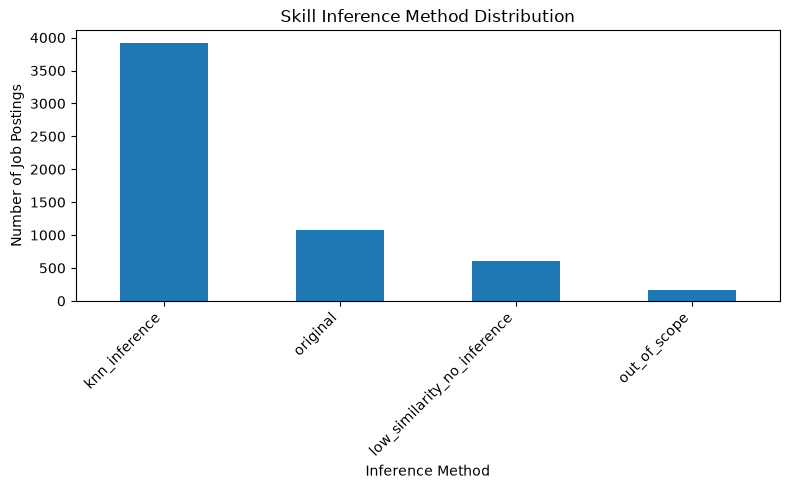

In [122]:
plt.figure(figsize=(8, 5))

method_counts.plot(kind="bar")

plt.title("Skill Inference Method Distribution")
plt.xlabel("Inference Method")
plt.ylabel("Number of Job Postings")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 9.18 Check missing skills by category

In [123]:
missing_by_category = (
    df_inference[
        df_inference["completed_skills_list"]
        .apply(len)
        .eq(0)
    ]
    ["normalized_title"]
    .value_counts()
)

display(missing_by_category)

normalized_title
Other                        161
Product / Management         124
Software Engineer             78
Research Scientist            74
Data Scientist                63
Machine Learning Engineer     56
Consultant                    47
Platform Engineer             43
MLOps Engineer                34
Data Engineer                 31
AI Engineer                   23
LLM Engineer                  17
DevOps Engineer               14
Solutions Architect            7
NLP Engineer                   2
Name: count, dtype: int64

## 9.19 Inspect inferred skills

In [124]:
inferred_examples = (
    df_inference[
        ~df_inference["has_original_skills"]
    ][
        [
            "job_title",
            "normalized_title",
            "skill_inference_method",
            "knn_similarity_score",
            "inferred_skills_knn"
        ]
    ]
    .sample(
        50,
        random_state=42
    )
)

display(inferred_examples)

,job_title,normalized_title,skill_inference_method,knn_similarity_score,inferred_skills_knn
2015,Machine Learning Engineer Intern,Machine Learning Engineer,knn_inference,0.630755,"[nlp, rag, azure, computer vision]"
5407,Senior Expert Artificial Intelligence (AI),AI Engineer,knn_inference,0.678364,"[azure, python, nlp]"
3590,GenAI Engineer,AI Engineer,knn_inference,0.723084,"[rag, fine-tuning, gcp, langchain, python]"
650,LLM Ops Engineer,LLM Engineer,knn_inference,0.688471,"[nlp, fine-tuning, rag, spark]"
3002,AI Performance Engineer (Cloud AI Engineering)...,AI Engineer,knn_inference,0.697385,"[azure, python]"
2867,"Staff Software Engineer, Inference",Software Engineer,knn_inference,0.690555,"[rag, kubernetes, r, spark]"
4085,Freelance Energy Systems Engineer - AI Trainer,AI Engineer,knn_inference,0.906228,[python]
5079,Data Scientist,Data Scientist,knn_inference,0.726899,"[computer vision, r, python, azure, aws, nlp]"
5021,"You are interested in a job at QuantPi, but th...",Other,out_of_scope,NaN,[]
407,Data Scientist,Data Scientist,knn_inference,0.735643,"[aws, r, computer vision, nlp]"


## 9.20 Review low-confidence KNN examples

In [125]:
low_confidence_examples = (
    df_inference[
        df_inference["skill_inference_method"]
        == "knn_inference"
    ]
    .sort_values("knn_similarity_score")
    [
        [
            "job_title",
            "normalized_title",
            "knn_similarity_score",
            "inferred_skills_knn"
        ]
    ]
    .head(50)
)

display(low_confidence_examples)

,job_title,normalized_title,knn_similarity_score,inferred_skills_knn
3262,Senior Software Engineer II- Machine Learning,Machine Learning Engineer,0.550075,"[python, aws, kubernetes, azure, keras, pytorc..."
4772,Senior GEN-AI Engineer - Germany,AI Engineer,0.550090,"[rag, r, kubernetes]"
4141,"Senior Software Engineer (TypeScript, Node, AI)",Software Engineer,0.550485,"[r, kubernetes, rag, aws, azure]"
3133,Sr. Machine Learning Engineer,Machine Learning Engineer,0.551148,"[nlp, python, aws, computer vision, rag]"
1608,"AI Research Scientist, FAIR Chemistry",Research Scientist,0.551197,"[r, rag]"
3254,Platform Engineer,Platform Engineer,0.551579,"[azure, python, aws, openai, kubernetes]"
3923,Research Chemist | Upto $90/hr Hourly,Research Scientist,0.551929,"[python, r, pytorch, tensorflow, computer visi..."
1066,"Senior Data & ML Engineer, MLOps",MLOps Engineer,0.552052,"[nlp, r]"
1042,MLOps Software Engineer,MLOps Engineer,0.552117,"[nlp, airflow, aws, azure, docker, gcp, kubern..."
3044,Senior AI Platform Engineer,Platform Engineer,0.552161,"[azure, aws, python, openai, kubernetes]"


## 9.21 Check KNN similarity distribution

In [126]:
knn_scores = (
    df_inference[
        df_inference["skill_inference_method"]
        == "knn_inference"
    ]
    ["knn_similarity_score"]
)

display(knn_scores.describe())

count    3915.000000
mean        0.681536
std         0.069105
min         0.550075
25%         0.633287
50%         0.675556
75%         0.729696
max         0.925413
Name: knn_similarity_score, dtype: float64

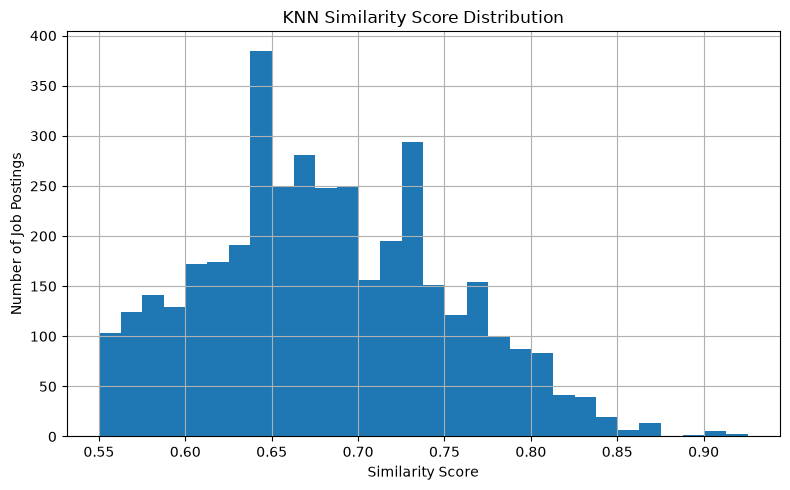

In [127]:
plt.figure(figsize=(8, 5))

knn_scores.hist(bins=30)

plt.title("KNN Similarity Score Distribution")
plt.xlabel("Similarity Score")
plt.ylabel("Number of Job Postings")

plt.tight_layout()
plt.show()

## 9.22 Check average number of skills by category

In [128]:
skills_by_category = (
    df_inference
    .groupby("normalized_title")["n_completed_skills"]
    .mean()
    .sort_values(ascending=False)
)

display(skills_by_category)

normalized_title
Solutions Architect          4.443038
MLOps Engineer               4.247012
AI Engineer                  3.856283
Data Engineer                3.801724
Data Scientist               3.565531
LLM Engineer                 3.409091
Machine Learning Engineer    3.340633
Software Engineer            2.838269
Research Scientist           2.416230
DevOps Engineer              2.263889
Consultant                   1.829060
Product / Management         1.383562
Platform Engineer            1.193548
NLP Engineer                 1.192982
Computer Vision Engineer     1.170833
Other                        0.048193
Name: n_completed_skills, dtype: float64

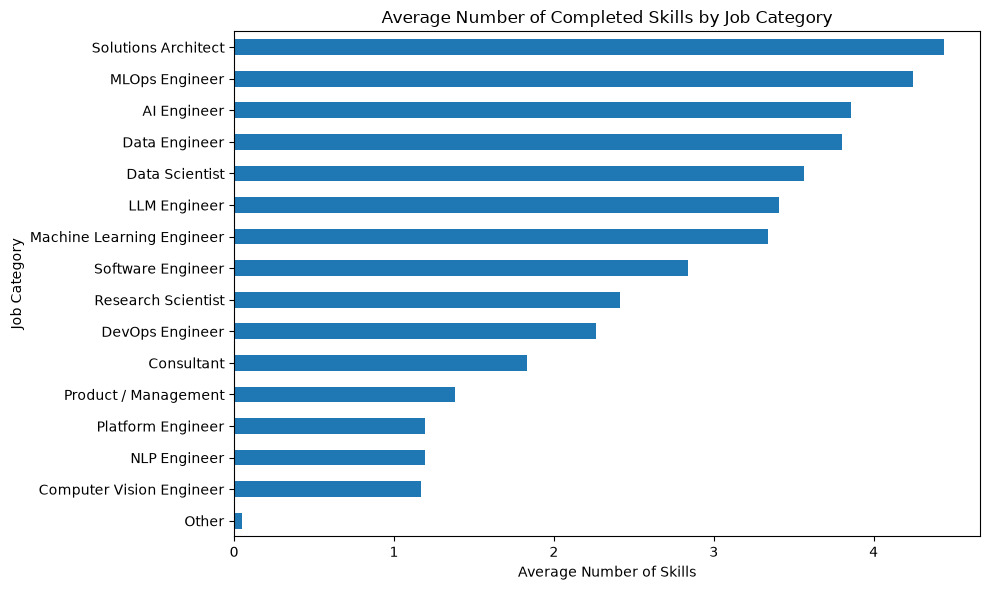

In [129]:
plt.figure(figsize=(10, 6))

skills_by_category.sort_values().plot(kind="barh")

plt.title("Average Number of Completed Skills by Job Category")
plt.xlabel("Average Number of Skills")
plt.ylabel("Job Category")

plt.tight_layout()
plt.show()

## 9.23 Validate that original skills were preserved

In [130]:
original_rows = df_inference[
    df_inference["has_original_skills"]
].copy()

original_skills_preserved = (
    original_rows["original_skills_list"]
    ==
    original_rows["completed_skills_list"]
).sum()

print("Rows checked:", len(original_rows))
print("Original skills preserved:", original_skills_preserved)

Rows checked: 1084
Original skills preserved: 1084


## 9.24 Final validation check

In [131]:
final_section_9_check = pd.DataFrame({
    "metric": [
        "Rows with original skills",
        "Rows marked as original",
        "KNN inferred rows",
        "Taxonomy fallback rows",
        "Low similarity rejected",
        "Out of scope rows",
        "Rows still missing skills",
        "Completion rate (%)"
    ],
    "value": [
        df_inference["has_original_skills"].sum(),
        (df_inference["skill_inference_method"] == "original").sum(),
        (df_inference["skill_inference_method"] == "knn_inference").sum(),
        (df_inference["skill_inference_method"] == "taxonomy_fallback").sum(),
        (df_inference["skill_inference_method"] == "low_similarity_no_inference").sum(),
        (df_inference["skill_inference_method"] == "out_of_scope").sum(),
        df_inference["completed_skills_list"].apply(len).eq(0).sum(),
        round(
            df_inference["completed_skills_list"]
            .apply(len)
            .gt(0)
            .mean() * 100,
            2
        )
    ]
})

display(final_section_9_check)

,metric,value
0,Rows with original skills,1084.00
1,Rows marked as original,1084.00
2,KNN inferred rows,3915.00
3,Taxonomy fallback rows,0.00
4,Low similarity rejected,613.00
5,Out of scope rows,161.00
6,Rows still missing skills,774.00
7,Completion rate (%),86.59


## 9.25 Save dataset with completed skills

In [132]:
COMPLETED_SKILLS_PATH = (
    DATA_DIR
    / "data"
    / "JobMarket2026"
    / "jobs_with_completed_skills.csv"
)

df_inference.to_csv(
    COMPLETED_SKILLS_PATH,
    index=False
)

print("Completed dataset saved.")
print("Output path:", COMPLETED_SKILLS_PATH)
print("Final shape:", df_inference.shape)

Completed dataset saved.
Output path: C:\Users\jerem\job_analysis\2026_ai_job_market_analysis\data\JobMarket2026\jobs_with_completed_skills.csv
Final shape: (5773, 39)


## Section 9 Summary

This section inferred missing skills using a similarity-based approach.

The main steps were:

1. The normalized job dataset was loaded.
2. The hybrid skill taxonomy from Section 8 was loaded.
3. Saved taxonomy skill lists were converted back into Python lists.
4. German ESCO skill labels were mapped to English skill labels using the German and English ESCO skill files.
5. The original `required_skills` column was converted into clean skill lists.
6. Rows with and without original skills were identified.
7. Job title, normalized title and a shortened job description were combined into a similarity text.
8. A multilingual embedding model was used to compare job postings across English, German and French text.
9. Embeddings were computed once and cached to disk to avoid recalculating them every time the notebook is rerun.
10. Missing skills were inferred only within the same normalized job category.
11. Inferred skills were filtered using the hybrid skill taxonomy.
12. Original skills were preserved when they already existed.
13. A final completed skills column was created.
14. Timers and progress messages were added to measure performance.
15. The completed dataset was saved as:

`jobs_with_completed_skills.csv`

The final dataset now contains:

- original skills when available
- inferred skills when original skills were missing
- the inference method used
- a KNN similarity score
- a completed skills column

German job postings are handled in two ways:

- German skill labels are translated to English through ESCO.
- German job descriptions are compared with other descriptions using a multilingual embedding model.

This section improves skill coverage while keeping the inference controlled. However, some inferred skills may still be too broad or questionable.

For that reason, the next section uses a local LLM with Ollama to validate the inferred skills.

# 10. Local LLM Skill Validation with Ollama

This section validates the skills inferred in Section 9 using a local LLM through Ollama.

The LLM does not generate new skills from scratch.

It only receives the candidate skills produced by the KNN pipeline and decides which ones should be kept.

This version uses a balanced validation strategy.

The goal is not to keep only skills explicitly mentioned in the job description, because many descriptions are short or truncated.

Instead, the LLM uses:

* the job title
* the normalized job category
* the job description
* the candidate skills inferred in Section 9

The LLM returns only a compact JSON decision:

```json
{
  "keep_skills": ["skill1", "skill2"],
  "reject_skills": ["skill3"]
}
```

No explanations are requested during the full run because explanations make the process much slower.

After the LLM validation, a rescue step is applied.

The rescue step adds back obvious core skills that the LLM removed too aggressively, but only if those skills were already present in the Section 9 candidate skill list.

This means the pipeline still does not invent new skills.

The section is optimized by using:

* limited job description length
* limited candidate skills
* parallel Ollama requests
* unique validation keys to avoid duplicate prompts
* checkpoints to resume the run
* a post-LLM rescue system to reduce excessive skill removal

The final output is a recommended skills column that combines:

* original skills when they existed
* LLM-validated and rescued skills for KNN-inferred rows
* Section 9 fallback skills when LLM validation failed or was not required


## 10.0 Load Section 9 output

In [362]:
import ast
import json
import re
import time
import hashlib
import threading
import requests

from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from collections import Counter

In [363]:
COMPLETED_SKILLS_PATH = (
    DATA_DIR
    / "data"
    / "JobMarket2026"
    / "jobs_with_completed_skills.csv"
)

df_llm = pd.read_csv(COMPLETED_SKILLS_PATH)

print("Section 9 dataset loaded.")
print("Shape:", df_llm.shape)

Section 9 dataset loaded.
Shape: (5773, 39)


## 10.1 Configuration

In [364]:
OLLAMA_URL = "http://localhost:11434/api/generate"
OLLAMA_TAGS_URL = "http://localhost:11434/api/tags"

MODEL_NAME = "llama3.2:latest"

MAX_WORKERS = 6
MAX_CANDIDATE_SKILLS = 8
DESCRIPTION_LIMIT = 700

CHECKPOINT_EVERY = 100

RUN_SAMPLE = False
SAMPLE_SIZE = 100

PROMPT_VERSION = "v7_balanced_skill_validation"

NUM_PREDICT = 120

CHECKPOINT_PATH = (
    DATA_DIR
    / "data"
    / "JobMarket2026"
    / "ollama_skill_validation_v7_balanced.csv"
)

print("Model:", MODEL_NAME)
print("Max workers:", MAX_WORKERS)
print("Run sample:", RUN_SAMPLE)
print("Prompt version:", PROMPT_VERSION)
print("Checkpoint path:", CHECKPOINT_PATH)

Model: llama3.2:latest
Max workers: 6
Run sample: False
Prompt version: v7_balanced_skill_validation
Checkpoint path: C:\Users\jerem\job_analysis\2026_ai_job_market_analysis\data\JobMarket2026\ollama_skill_validation_v7_balanced.csv


## 10.2 Clean and parse skill lists

In [365]:
def normalize_skill_label(skill):
    """
    Normalize a skill label returned by the LLM or stored in the dataset.
    """

    if skill is None:
        return ""

    skill = str(skill).lower().strip()

    if skill in ["", "nan", "none", "null"]:
        return ""

    return skill


def flatten_any(value):
    """
    Flatten nested lists if they exist.
    """

    if isinstance(value, (list, tuple, set)):

        for item in value:
            yield from flatten_any(item)

    else:
        yield value


def parse_skill_list(value):
    """
    Convert a saved CSV value into a clean Python list of skills.
    """

    if isinstance(value, (list, tuple, set)):
        parsed_value = value

    else:
        try:
            if pd.isna(value):
                return []
        except Exception:
            pass

        if isinstance(value, str):

            value = value.strip()

            if value == "" or value == "[]" or value.lower() == "nan":
                return []

            try:
                parsed_value = ast.literal_eval(value)

            except Exception:
                parsed_value = value.split(",")

        else:
            parsed_value = value

    clean_skills = []

    for item in flatten_any(parsed_value):

        skill = normalize_skill_label(item)

        if skill != "" and skill not in clean_skills:
            clean_skills.append(skill)

    return clean_skills

In [366]:
LIST_COLUMNS = [
    "original_skills_list",
    "inferred_skills_knn",
    "completed_skills_list"
]

for column in LIST_COLUMNS:

    if column in df_llm.columns:

        df_llm[column] = (
            df_llm[column]
            .apply(parse_skill_list)
        )

print("List columns parsed.")

List columns parsed.


## 10.3 Check Ollama connection

In [367]:
def check_ollama_connection():
    """
    Check if Ollama is running and if the selected model exists.
    """

    try:
        response = requests.get(
            OLLAMA_TAGS_URL,
            timeout=10
        )

        response.raise_for_status()

        models = response.json().get(
            "models",
            []
        )

        available_models = [
            model["name"]
            for model in models
        ]

        print("Ollama is running.")
        print("Available models:")

        for model in available_models:
            print("-", model)

        if MODEL_NAME not in available_models:
            print()
            print("Warning:")
            print(f"{MODEL_NAME} was not found.")

        return available_models

    except Exception as error:
        print("Ollama connection failed.")
        print("Error:", error)

        return []


available_models = check_ollama_connection()

Ollama is running.
Available models:
- llama3.2:latest


## 10.4 Quick Ollama JSON test

In [368]:
test_payload = {
    "model": MODEL_NAME,
    "prompt": 'Return only this JSON: {"keep_skills": ["python"], "reject_skills": []}',
    "stream": False,
    "format": "json",
    "keep_alive": "30m",
    "options": {
        "temperature": 0,
        "num_predict": 50,
        "num_ctx": 1024
    }
}

test_response = requests.post(
    OLLAMA_URL,
    json=test_payload,
    timeout=120
)

print("Status:", test_response.status_code)
print(test_response.json().get("response", ""))

Status: 200
{"keep_skills": ["python"], "reject_skills": []}


## 10.5 Select rows that need LLM validation

In [369]:
df_llm["needs_llm_validation"] = (
    (df_llm["skill_inference_method"] == "knn_inference")
    &
    (df_llm["completed_skills_list"].apply(len) > 0)
)

all_validation_rows = df_llm[
    df_llm["needs_llm_validation"]
].copy()

print("All KNN rows needing validation:", len(all_validation_rows))

if RUN_SAMPLE:

    validation_rows = all_validation_rows.sample(
        min(SAMPLE_SIZE, len(all_validation_rows)),
        random_state=42
    )

else:

    validation_rows = all_validation_rows.copy()

print("Rows selected for this run:", len(validation_rows))

All KNN rows needing validation: 3915
Rows selected for this run: 3915


## 10.6 Create validation keys

In [370]:
def create_validation_key(row):
    """
    Create a unique key for a validation prompt.

    If two rows have the same title, category, short description
    and candidate skills, they share the same validation result.
    """

    candidate_skills = parse_skill_list(
        row["completed_skills_list"]
    )[:MAX_CANDIDATE_SKILLS]

    description = str(
        row.get(
            "job_description",
            ""
        )
    )[:DESCRIPTION_LIMIT]

    key_data = {
        "prompt_version": PROMPT_VERSION,
        "job_title": str(row.get("job_title", "")).lower().strip(),
        "normalized_title": str(row.get("normalized_title", "")).lower().strip(),
        "job_description": description.lower().strip(),
        "candidate_skills": candidate_skills
    }

    key_text = json.dumps(
        key_data,
        sort_keys=True,
        ensure_ascii=False
    )

    return hashlib.md5(
        key_text.encode("utf-8")
    ).hexdigest()

In [371]:
df_llm["validation_key"] = None

df_llm.loc[
    df_llm["needs_llm_validation"],
    "validation_key"
] = (
    df_llm.loc[
        df_llm["needs_llm_validation"]
    ]
    .apply(
        create_validation_key,
        axis=1
    )
)

validation_rows["validation_key"] = (
    validation_rows.apply(
        create_validation_key,
        axis=1
    )
)

validation_tasks = (
    validation_rows
    .drop_duplicates("validation_key")
    .copy()
)

validation_tasks["row_index_example"] = validation_tasks.index

print("Selected rows:", len(validation_rows))
print("Unique LLM prompts:", len(validation_tasks))

Selected rows: 3915
Unique LLM prompts: 2713


## 10.7 Create compact LLM prompt

In [372]:
def create_validation_prompt(row):
    """
    Create a balanced prompt for LLM skill validation.

    The goal is to reduce obvious noise without removing plausible core skills.
    """

    candidate_skills = parse_skill_list(
        row["completed_skills_list"]
    )[:MAX_CANDIDATE_SKILLS]

    description = str(
        row.get(
            "job_description",
            ""
        )
    )[:DESCRIPTION_LIMIT]

    prompt = f"""
You are validating candidate technical skills for a job market dataset.

Important context:
The job descriptions may be truncated.
Do not require every skill to be explicitly mentioned.
Use the job title, normalized job category, and description together.

Job title:
{row.get("job_title", "")}

Normalized job category:
{row.get("normalized_title", "")}

Job description:
{description}

Candidate skills:
{json.dumps(candidate_skills, ensure_ascii=False)}

Task:
Classify each candidate skill as keep or reject.

Keep a skill if:
1. It is explicitly mentioned.
2. It is strongly implied by the job title.
3. It is a core skill for this type of technical role.
4. It is reasonably supported by the job category and description.

Reject a skill only if:
1. It is clearly unrelated to the job.
2. It looks like noise from a similar but different role.
3. The job description clearly points to another technical stack.
4. The skill is too specific and not supported at all.

Guidance:
- Keep "python" for AI, ML, data science, data engineering, LLM, MLOps, research, or software engineering roles unless the job clearly uses another stack only.
- Keep "r" mainly for Data Scientist or Research Scientist roles.
- Keep "rag" for AI, LLM, GenAI, prompt engineering, agentic AI, retrieval, knowledge base, embeddings, or vector database roles.
- Keep "computer vision" when the role or description suggests images, vision, perception, video, multimodal AI, robotics, or visual models.
- Keep "aws", "azure", or "gcp" when the role involves cloud, deployment, infrastructure, MLOps, platform engineering, data engineering, or architecture.
- Keep "nlp", "transformers", "openai", "langchain", and "fine-tuning" for LLM, GenAI, NLP, prompt engineering, or applied AI roles when plausible.

Important:
- Do not add new skills.
- Do not rename skills.
- Use exact strings from the candidate skills list.
- Return only valid JSON.
- Do not include explanations.

Expected format:
{{
  "keep_skills": ["skill1", "skill2"],
  "reject_skills": ["skill3"]
}}

Answer:
"""

    return prompt

## 10.8 Parse LLM output safely

In [373]:
def extract_json_from_text(text):
    """
    Extract a JSON object from the LLM response.
    """

    text = str(text).strip()

    try:
        return json.loads(text)

    except Exception:
        pass

    match = re.search(
        r"\{.*\}",
        text,
        flags=re.DOTALL
    )

    if match:

        try:
            return json.loads(
                match.group(0)
            )

        except Exception:
            return {}

    return {}


def parse_llm_response(response_text, candidate_skills):
    """
    Parse the LLM response and keep only skills from the candidate list.
    """

    candidate_skills = parse_skill_list(
        candidate_skills
    )[:MAX_CANDIDATE_SKILLS]

    allowed_skills = [
        normalize_skill_label(skill)
        for skill in candidate_skills
    ]

    allowed_set = set(allowed_skills)

    data = extract_json_from_text(
        response_text
    )

    raw_keep_skills = data.get(
        "keep_skills",
        []
    )

    keep_skills = []

    for skill in raw_keep_skills:

        skill = normalize_skill_label(skill)

        if skill in allowed_set and skill not in keep_skills:
            keep_skills.append(skill)

    ordered_keep_skills = [
        skill
        for skill in allowed_skills
        if skill in keep_skills
    ]

    return ordered_keep_skills

## 10.9 Thread-safe request session

In [374]:
thread_local = threading.local()


def get_session():
    """
    Create one requests session per thread.
    """

    if not hasattr(thread_local, "session"):
        thread_local.session = requests.Session()

    return thread_local.session

## 10.10 Validate one unique prompt

In [375]:
def validate_one_task(task):
    """
    Validate one unique prompt with Ollama.
    """

    candidate_skills = parse_skill_list(
        task["completed_skills_list"]
    )[:MAX_CANDIDATE_SKILLS]

    prompt = create_validation_prompt(
        task
    )

    payload = {
        "model": MODEL_NAME,
        "prompt": prompt,
        "stream": False,
        "keep_alive": "30m",
        "format": "json",
        "options": {
            "temperature": 0,
            "num_predict": NUM_PREDICT,
            "num_ctx": 2048
        }
    }

    try:
        session = get_session()

        response = session.post(
            OLLAMA_URL,
            json=payload,
            timeout=180
        )

        response.raise_for_status()

        raw_response = response.json().get(
            "response",
            ""
        )

        validated_skills = parse_llm_response(
            raw_response,
            candidate_skills
        )

        return {
            "validation_key": task["validation_key"],
            "row_index_example": task["row_index_example"],
            "llm_status": "ok",
            "llm_validated_skills": validated_skills,
            "llm_raw_response": raw_response,
            "n_candidate_skills": len(candidate_skills),
            "n_validated_skills": len(validated_skills)
        }

    except Exception as error:

        return {
            "validation_key": task["validation_key"],
            "row_index_example": task.get("row_index_example", None),
            "llm_status": "error",
            "llm_validated_skills": [],
            "llm_raw_response": str(error),
            "n_candidate_skills": len(candidate_skills),
            "n_validated_skills": 0
        }

## 10.11 Prepare validation tasks

In [376]:
TASK_COLUMNS = [
    "validation_key",
    "row_index_example",
    "job_title",
    "normalized_title",
    "job_description",
    "completed_skills_list"
]

tasks = (
    validation_tasks[TASK_COLUMNS]
    .to_dict(orient="records")
)

print("Unique tasks to validate:", len(tasks))

Unique tasks to validate: 2713


## 10.12 Checkpoint helpers

In [377]:
print("Checkpoint path:")
print(CHECKPOINT_PATH)

Checkpoint path:
C:\Users\jerem\job_analysis\2026_ai_job_market_analysis\data\JobMarket2026\ollama_skill_validation_v7_balanced.csv


In [378]:
def save_checkpoint(results, checkpoint_path):
    """
    Save LLM validation results to disk.
    """

    checkpoint_df = pd.DataFrame(results).copy()

    if checkpoint_df.empty:
        return

    checkpoint_df = checkpoint_df.drop_duplicates(
        "validation_key",
        keep="last"
    )

    if "llm_validated_skills" not in checkpoint_df.columns:
        checkpoint_df["llm_validated_skills"] = [
            []
            for _ in range(len(checkpoint_df))
        ]

    checkpoint_df["llm_validated_skills"] = (
        checkpoint_df["llm_validated_skills"]
        .apply(
            lambda skills:
            "|".join(skills)
            if isinstance(skills, list)
            else ""
        )
    )

    checkpoint_df.to_csv(
        checkpoint_path,
        index=False
    )

In [379]:
def load_checkpoint(checkpoint_path):
    """
    Load existing checkpoint if it exists.
    """

    if not checkpoint_path.exists():

        return pd.DataFrame(
            columns=[
                "validation_key",
                "row_index_example",
                "llm_status",
                "llm_validated_skills",
                "llm_raw_response",
                "n_candidate_skills",
                "n_validated_skills"
            ]
        )

    checkpoint_df = pd.read_csv(
        checkpoint_path
    )

    checkpoint_df["llm_validated_skills"] = (
        checkpoint_df["llm_validated_skills"]
        .fillna("")
        .apply(
            lambda text:
            [
                skill
                for skill in str(text).split("|")
                if skill.strip()
            ]
        )
    )

    return checkpoint_df

In [380]:
existing_checkpoint = load_checkpoint(
    CHECKPOINT_PATH
)

validated_keys = set(
    existing_checkpoint["validation_key"]
    .dropna()
    .astype(str)
)

tasks_to_run = [
    task
    for task in tasks
    if str(task["validation_key"]) not in validated_keys
]

print("Existing validated prompts:", len(validated_keys))
print("Tasks remaining:", len(tasks_to_run))

Existing validated prompts: 88
Tasks remaining: 2625


## 10.13 Run parallel LLM validation

In [381]:
results = existing_checkpoint.to_dict(
    orient="records"
)

start_time = time.time()

with ThreadPoolExecutor(
    max_workers=MAX_WORKERS
) as executor:

    futures = {
        executor.submit(
            validate_one_task,
            task
        ): task["validation_key"]
        for task in tasks_to_run
    }

    for counter, future in enumerate(
        as_completed(futures),
        start=1
    ):

        validation_key = futures[future]

        try:
            result = future.result()

        except Exception as error:

            result = {
                "validation_key": validation_key,
                "row_index_example": None,
                "llm_status": "error",
                "llm_validated_skills": [],
                "llm_raw_response": str(error),
                "n_candidate_skills": 0,
                "n_validated_skills": 0
            }

        results.append(result)

        if counter % CHECKPOINT_EVERY == 0:

            save_checkpoint(
                results,
                CHECKPOINT_PATH
            )

            elapsed_minutes = (
                time.time()
                - start_time
            ) / 60

            remaining = (
                len(tasks_to_run)
                - counter
            )

            minutes_per_task = (
                elapsed_minutes / counter
                if counter > 0
                else 0
            )

            estimated_remaining = (
                remaining
                * minutes_per_task
            )

            print(
                f"Checkpoint saved: {counter}/{len(tasks_to_run)} "
                f"- elapsed: {elapsed_minutes:.2f} min "
                f"- estimated remaining: {estimated_remaining:.2f} min"
            )


save_checkpoint(
    results,
    CHECKPOINT_PATH
)

print("LLM validation finished.")
print("Checkpoint saved.")

Checkpoint saved: 100/2625 - elapsed: 0.94 min - estimated remaining: 23.64 min
Checkpoint saved: 200/2625 - elapsed: 1.74 min - estimated remaining: 21.04 min
Checkpoint saved: 300/2625 - elapsed: 2.53 min - estimated remaining: 19.63 min
Checkpoint saved: 400/2625 - elapsed: 3.35 min - estimated remaining: 18.65 min
Checkpoint saved: 500/2625 - elapsed: 4.15 min - estimated remaining: 17.64 min
Checkpoint saved: 600/2625 - elapsed: 4.97 min - estimated remaining: 16.79 min
Checkpoint saved: 700/2625 - elapsed: 5.76 min - estimated remaining: 15.84 min
Checkpoint saved: 800/2625 - elapsed: 6.57 min - estimated remaining: 14.98 min
Checkpoint saved: 900/2625 - elapsed: 7.36 min - estimated remaining: 14.10 min
Checkpoint saved: 1000/2625 - elapsed: 8.12 min - estimated remaining: 13.20 min
Checkpoint saved: 1100/2625 - elapsed: 8.91 min - estimated remaining: 12.36 min
Checkpoint saved: 1200/2625 - elapsed: 9.72 min - estimated remaining: 11.54 min
Checkpoint saved: 1300/2625 - elapsed

## 10.14 Load LLM results

In [382]:
results_df = load_checkpoint(
    CHECKPOINT_PATH
)

results_df = (
    results_df
    .drop_duplicates(
        "validation_key",
        keep="last"
    )
)

results_df = results_df.rename(
    columns={
        "llm_validated_skills": "llm_validated_skills_from_llm"
    }
)

print("LLM results loaded:", results_df.shape)

display(
    results_df["llm_status"]
    .value_counts()
)

LLM results loaded: (2713, 7)


llm_status
ok    2713
Name: count, dtype: int64

## 10.15 Merge LLM results back into dataset

In [383]:
MERGE_COLUMNS = [
    "validation_key",
    "llm_status",
    "llm_validated_skills_from_llm",
    "llm_raw_response",
    "n_candidate_skills",
    "n_validated_skills"
]

df_llm = df_llm.drop(
    columns=[
        column
        for column in MERGE_COLUMNS
        if column in df_llm.columns
        and column != "validation_key"
    ],
    errors="ignore"
)

df_llm = df_llm.merge(
    results_df[MERGE_COLUMNS],
    on="validation_key",
    how="left"
)

df_llm["llm_status"] = (
    df_llm["llm_status"]
    .fillna("not_validated")
)

df_llm["llm_validated_skills_from_llm"] = (
    df_llm["llm_validated_skills_from_llm"]
    .apply(parse_skill_list)
)

## 10.16 Create LLM validation columns

In [384]:
def get_llm_validated_skills(row):
    """
    Return LLM-validated skills only when the LLM succeeded.
    """

    if row["llm_status"] == "ok":

        return parse_skill_list(
            row["llm_validated_skills_from_llm"]
        )

    return []


df_llm["llm_validated_skills_list"] = (
    df_llm.apply(
        get_llm_validated_skills,
        axis=1
    )
)

In [385]:
def get_llm_removed_skills(row):
    """
    Identify skills removed by the LLM.
    """

    if row["llm_status"] != "ok":
        return []

    before = set(
        parse_skill_list(
            row["completed_skills_list"]
        )
    )

    after = set(
        parse_skill_list(
            row["llm_validated_skills_list"]
        )
    )

    return sorted(
        list(before - after)
    )


df_llm["llm_removed_skills_list"] = (
    df_llm.apply(
        get_llm_removed_skills,
        axis=1
    )
)

In [386]:
df_llm["n_completed_skills"] = (
    df_llm["completed_skills_list"]
    .apply(len)
)

df_llm["n_llm_validated_skills"] = (
    df_llm["llm_validated_skills_list"]
    .apply(len)
)

df_llm["n_skills_removed_by_llm"] = (
    df_llm["llm_removed_skills_list"]
    .apply(len)
)

df_llm["llm_keep_rate"] = np.where(
    df_llm["n_completed_skills"] > 0,
    df_llm["n_llm_validated_skills"] / df_llm["n_completed_skills"],
    np.nan
)

## 10.17 Rescue over-removed skills

In [387]:
TECHNICAL_AI_CATEGORIES = [
    "AI Engineer",
    "Machine Learning Engineer",
    "Data Scientist",
    "Data Engineer",
    "Research Scientist",
    "LLM Engineer",
    "MLOps Engineer",
    "Software Engineer"
]

DATA_CATEGORIES = [
    "Data Scientist",
    "Research Scientist"
]

CLOUD_CATEGORIES = [
    "MLOps Engineer",
    "DevOps Engineer",
    "Platform Engineer",
    "Data Engineer",
    "Solutions Architect"
]

In [388]:
def rescue_over_removed_skills(row):
    """
    Add back obvious core skills removed too aggressively by the LLM.

    This does not add new skills from scratch.
    It only rescues skills that already existed in completed_skills_list.
    """

    # Rescue is only applied to rows successfully validated by the LLM.
    if row["llm_status"] != "ok":
        return parse_skill_list(
            row["llm_validated_skills_list"]
        )

    kept_skills = parse_skill_list(
        row["llm_validated_skills_list"]
    )

    candidate_skills = parse_skill_list(
        row["completed_skills_list"]
    )

    text = (
        str(row.get("job_title", "")) + " " +
        str(row.get("normalized_title", "")) + " " +
        str(row.get("job_description", ""))
    ).lower()

    category = row.get(
        "normalized_title",
        ""
    )

    rescued_skills = kept_skills.copy()

    for skill in candidate_skills:

        if skill in rescued_skills:
            continue

        if skill == "python" and category in TECHNICAL_AI_CATEGORIES:
            rescued_skills.append(skill)

        elif skill == "r" and category in DATA_CATEGORIES:
            rescued_skills.append(skill)

        elif skill == "rag" and re.search(
            r"rag|retrieval|vector|embedding|knowledge base|genai|generative ai|llm|agent|prompt",
            text
        ):
            rescued_skills.append(skill)

        elif skill == "computer vision" and re.search(
            r"computer vision|vision|image|video|visual|perception|multimodal|robotic|autonomous|object detection|image analysis|visual model",
            text
        ):
            rescued_skills.append(skill)

        elif skill in ["aws", "azure", "gcp"] and (
            category in CLOUD_CATEGORIES
            or re.search(
                r"cloud|deploy|deployment|infrastructure|platform|mlops|production|architecture|data pipeline",
                text
            )
        ):
            rescued_skills.append(skill)

        elif skill in ["nlp", "transformers", "openai", "langchain", "fine-tuning"] and re.search(
            r"nlp|llm|language model|genai|generative ai|prompt|agent|chatbot|natural language|large language",
            text
        ):
            rescued_skills.append(skill)

        elif skill in ["docker", "kubernetes"] and re.search(
            r"deploy|deployment|production|container|kubernetes|docker|mlops|platform|infrastructure",
            text
        ):
            rescued_skills.append(skill)

        elif skill in ["spark", "airflow"] and re.search(
            r"data engineer|data pipeline|etl|spark|airflow|big data|data platform",
            text
        ):
            rescued_skills.append(skill)

    return rescued_skills

In [389]:
df_llm["llm_validated_skills_rescued"] = (
    df_llm.apply(
        rescue_over_removed_skills,
        axis=1
    )
)

df_llm["n_llm_validated_skills_rescued"] = (
    df_llm["llm_validated_skills_rescued"]
    .apply(len)
)

df_llm["n_skills_rescued"] = (
    df_llm["n_llm_validated_skills_rescued"]
    - df_llm["n_llm_validated_skills"]
)

## 10.18 Create final recommended skills

In [390]:
def choose_recommended_skills(row):
    """
    Choose the final recommended skills.
    """

    if row["skill_inference_method"] == "original":

        return (
            row["original_skills_list"],
            "original"
        )

    if row["llm_status"] == "ok":

        return (
            row["llm_validated_skills_rescued"],
            "llm_validated_with_rescue"
        )

    if row["llm_status"] == "error":

        return (
            row["completed_skills_list"],
            "llm_error_keep_section9"
        )

    if row["llm_status"] == "not_validated":

        return (
            row["completed_skills_list"],
            "section9_not_llm_validated"
        )

    return (
        row["completed_skills_list"],
        "section9_fallback"
    )

In [391]:
recommended_results = (
    df_llm.apply(
        choose_recommended_skills,
        axis=1,
        result_type="expand"
    )
)

df_llm["recommended_skills_list"] = recommended_results[0]
df_llm["recommended_skill_source"] = recommended_results[1]

df_llm["recommended_skills"] = (
    df_llm["recommended_skills_list"]
    .apply(
        lambda skills:
        ", ".join(skills)
    )
)

df_llm["n_recommended_skills"] = (
    df_llm["recommended_skills_list"]
    .apply(len)
)

## 10.19 Final checks

In [392]:
print("Section 10 final check")
print("-" * 40)

print("Total rows:", len(df_llm))

print(
    "Rows needing LLM validation:",
    df_llm["needs_llm_validation"].sum()
)

print(
    "Rows validated by LLM:",
    (df_llm["llm_status"] == "ok").sum()
)

print(
    "LLM errors:",
    (df_llm["llm_status"] == "error").sum()
)

print(
    "Rows not validated:",
    (df_llm["llm_status"] == "not_validated").sum()
)

print(
    "Rows with Section 9 skills:",
    df_llm["completed_skills_list"]
    .apply(len)
    .gt(0)
    .sum()
)

print(
    "Rows with LLM skills before rescue:",
    df_llm["llm_validated_skills_list"]
    .apply(len)
    .gt(0)
    .sum()
)

print(
    "Rows with LLM skills after rescue:",
    df_llm["llm_validated_skills_rescued"]
    .apply(len)
    .gt(0)
    .sum()
)

print(
    "Rows with rescued skills:",
    df_llm["n_skills_rescued"]
    .gt(0)
    .sum()
)

print(
    "Rows with recommended skills:",
    df_llm["recommended_skills_list"]
    .apply(len)
    .gt(0)
    .sum()
)

print(
    "Recommended coverage:",
    round(
        df_llm["recommended_skills_list"]
        .apply(len)
        .gt(0)
        .mean() * 100,
        2
    ),
    "%"
)

source_counts = (
    df_llm["recommended_skill_source"]
    .value_counts()
)

display(source_counts)

status_counts = (
    df_llm["llm_status"]
    .value_counts()
)

display(status_counts)

Section 10 final check
----------------------------------------
Total rows: 5773
Rows needing LLM validation: 3915
Rows validated by LLM: 3915
LLM errors: 0
Rows not validated: 1858
Rows with Section 9 skills: 4999
Rows with LLM skills before rescue: 3914
Rows with LLM skills after rescue: 3914
Rows with rescued skills: 1328
Rows with recommended skills: 4998
Recommended coverage: 86.58 %


recommended_skill_source
llm_validated_with_rescue     3915
original                      1084
section9_not_llm_validated     774
Name: count, dtype: int64

llm_status
ok               3915
not_validated    1858
Name: count, dtype: int64

In [393]:
source_counts = (
    df_llm["recommended_skill_source"]
    .value_counts()
)

display(source_counts)

recommended_skill_source
llm_validated_with_rescue     3915
original                      1084
section9_not_llm_validated     774
Name: count, dtype: int64

In [394]:
status_counts = (
    df_llm["llm_status"]
    .value_counts()
)

display(status_counts)

llm_status
ok               3915
not_validated    1858
Name: count, dtype: int64

## 10.20 Inspect validation examples

In [395]:
validated_examples = (
    df_llm[
        df_llm["llm_status"] == "ok"
    ][
        [
            "job_title",
            "normalized_title",
            "completed_skills_list",
            "llm_validated_skills_list",
            "llm_validated_skills_rescued",
            "llm_removed_skills_list",
            "n_skills_rescued",
            "recommended_skills_list",
            "recommended_skill_source",
            "llm_keep_rate",
            "job_description"
        ]
    ]
)

display(
    validated_examples.sample(
        min(30, len(validated_examples)),
        random_state=42
    )
)

,job_title,normalized_title,completed_skills_list,llm_validated_skills_list,llm_validated_skills_rescued,llm_removed_skills_list,n_skills_rescued,recommended_skills_list,recommended_skill_source,llm_keep_rate,job_description
324,Machine Learning Engineer (PhD Intern),Machine Learning Engineer,"[computer vision, r, rag, nlp]","[computer vision, r, nlp]","[computer vision, r, nlp]",[rag],0,"[computer vision, r, nlp]",llm_validated_with_rescue,0.750000,"We're transforming the grocery industry At Instacart, we invite the world to share love through food because we believe everyone should have access to the food they love and more time to enjoy it together. Where others see a simple need for grocery delivery, we see exciting complexity and endless opportunity to serve the varied needs of our community. We work to deliver an essential service that customers rely on to get their groceries and household goods, while also offering safe and flexible …"
2863,Senior Machine Learning Scientist,Machine Learning Engineer,"[computer vision, nlp, pytorch, airflow]","[pytorch, airflow]","[pytorch, airflow]","[computer vision, nlp]",0,"[pytorch, airflow]",llm_validated_with_rescue,0.500000,"A fantastic opportunity for a Senior Machine Learning Scientist to work for a health-tech software company developing advanced machine learning models used within clinical research. The organisation applies modern machine learning techniques to complex medical datasets to support better understanding of patient outcomes and treatment response. This is a research-focused role, ideal for candidates who enjoy developing novel deep learning approaches and translating academic research into applied …"
934,Generative AI Automation Engineer - Remote Job,AI Engineer,"[azure, rag, transformers, openai, python, fine-tuning, nlp]","[azure, transformers, python, nlp]","[azure, transformers, python, nlp, rag, openai, fine-tuning]","[fine-tuning, openai, rag]",3,"[azure, transformers, python, nlp, rag, openai, fine-tuning]",llm_validated_with_rescue,0.571429,"About Us Our mission is to bring people together and connect them into a community to nurture each other. We aim to share a conducive environment, a joyous space to grow and excel; a world brimming with selfless love and enough kindness. We strive to enrich each of our lives with kaleidoscopic memories we make here - vibrant, lively, of all hues and colors. Job Description ​ This is a remote position. We are seeking a highly skilled and innovative Generative AI Automation Engineer to join our t…"
4154,Engineering Manager - Data Ingestion & AI,Product / Management,"[azure, aws, openai, nlp]","[azure, aws, nlp]","[azure, aws, nlp]",[openai],0,"[azure, aws, nlp]",llm_validated_with_rescue,0.750000,"Dovetail is a rapidly growing global company on a mission to improve the quality of every thing. Our AI-native customer intelligence platform helps thousands of teams from Fortune 500 companies to innovative startups to bring together customer insights from across their organization. We capture every sales call, survey, report, interview, support ticket, renewal call, usability test, and app review, and transform that raw data into actionable insights your product team can leverage. By helping …"
4085,Freelance Energy Systems Engineer - AI Trainer,AI Engineer,[python],[python],[python],[],0,[python],llm_validated_with_rescue,1.000000,"Please submit your CV in English and indicate your level of English proficiency. Mindrift connects specialists with project-based AI opportunities for leading tech companies, focused on testing, evaluating, and improving AI systems. Participation is project-based, not permanent employment. What this opportunity involves While each project involves unique tasks, contributors may: Design rigorous energy engineering problems reflecting professional practice; Evaluate AI solutions for correctness, …"
5284,Consultant for Digital Transformation & AI – Ideal for Career Changer,Consultant,"[r, azure, nlp

In [396]:
empty_after_llm = df_llm[
    (df_llm["llm_status"] == "ok")
    &
    (df_llm["completed_skills_list"].apply(len) > 0)
    &
    (df_llm["llm_validated_skills_list"].apply(len) == 0)
]

print("Rows where LLM removed all skills:", len(empty_after_llm))

display(
    empty_after_llm[
        [
            "job_title",
            "normalized_title",
            "completed_skills_list",
            "llm_validated_skills_list",
            "llm_removed_skills_list",
            "job_description"
        ]
    ].sample(
        min(100, len(empty_after_llm)),
        random_state=42
    )
)

Rows where LLM removed all skills: 1


,job_title,normalized_title,completed_skills_list,llm_validated_skills_list,llm_removed_skills_list,job_description
4141,"Senior Software Engineer (TypeScript, Node, AI)",Software Engineer,"[r, kubernetes, rag, aws, azure]",[],"[aws, azure, kubernetes, r, rag]","About Settify Settify, an AI-backed technology, helps legal clients in preparing and presenting their personal stories effectively. It streamlines the initial information-gathering process, helping clients articulate key details when seeking legal assistance, particularly in areas like family law and wills. Collecting new client information can involve significant time and cost spent on both sides. Using Settify saves time, increases the accuracy of their work and ultimately, helps their client…"


## 10.21 Inspect removed skills

In [397]:
rescued_skill_counter = Counter()

for index, row in df_llm.iterrows():

    before = set(
        parse_skill_list(
            row["llm_validated_skills_list"]
        )
    )

    after = set(
        parse_skill_list(
            row["llm_validated_skills_rescued"]
        )
    )

    rescued = after - before

    for skill in rescued:
        rescued_skill_counter[skill] += 1


rescued_skills_summary = pd.DataFrame(
    rescued_skill_counter.most_common(30),
    columns=[
        "skill",
        "rescued_count"
    ]
)

display(rescued_skills_summary)

,skill,rescued_count
0,rag,637
1,azure,282
2,fine-tuning,217
3,r,210
4,openai,171
5,gcp,147
6,aws,59
7,nlp,57
8,computer vision,51
9,langchain,16


## 10.21 Check original skills were preserved

In [398]:
original_rows = df_llm[
    df_llm["skill_inference_method"] == "original"
].copy()

original_preserved = (
    original_rows["original_skills_list"]
    ==
    original_rows["recommended_skills_list"]
).sum()

print("Original rows:", len(original_rows))
print("Original skills preserved:", original_preserved)

if len(original_rows) > 0:

    print(
        "Preservation rate:",
        round(
            original_preserved / len(original_rows) * 100,
            2
        ),
        "%"
    )

Original rows: 1084
Original skills preserved: 1084
Preservation rate: 100.0 %


## 10.22 Save LLM recommended dataset

In [399]:
if RUN_SAMPLE:

    OUTPUT_PATH = (
        DATA_DIR
        / "data"
        / "JobMarket2026"
        / "jobs_with_llm_recommended_skills_sample.csv"
    )

else:

    OUTPUT_PATH = (
        DATA_DIR
        / "data"
        / "JobMarket2026"
        / "jobs_with_llm_recommended_skills.csv"
    )


df_llm.to_csv(
    OUTPUT_PATH,
    index=False
)

print("LLM recommended skills dataset saved.")
print("Output path:", OUTPUT_PATH)
print("Final shape:", df_llm.shape)

LLM recommended skills dataset saved.
Output path: C:\Users\jerem\job_analysis\2026_ai_job_market_analysis\data\JobMarket2026\jobs_with_llm_recommended_skills.csv
Final shape: (5773, 58)


## Section 10 Summary

This section used a local LLM through Ollama to validate the KNN-inferred skills from Section 9.

The LLM was used as a validation layer, not as a skill generator.

The main steps were:

1. The Section 9 dataset was loaded.
2. Saved skill lists were converted back into Python lists.
3. Ollama was configured and tested.
4. Only KNN-inferred rows were selected for validation.
5. Duplicate prompts were removed using validation keys.
6. A balanced JSON prompt was created.
7. The LLM classified candidate skills as either kept or rejected.
8. Explanations were removed from the full run to improve speed.
9. Ollama requests were executed in parallel.
10. Checkpoints were saved during execution.
11. LLM results were merged back into the dataset.
12. Skills removed by the LLM were identified.
13. A rescue step added back obvious core skills removed too aggressively.
14. Original skills were preserved.
15. LLM-validated and rescued skills were used for inferred rows.
16. Section 9 skills were kept when rows were not validated or when validation failed.
17. A final recommended skills column was created.
18. The dataset was saved for the next evaluation section.

This version is designed to balance precision and coverage.

The LLM reduces noisy KNN-inferred skills, while the rescue system prevents the final dataset from becoming too sparse.

The final recommended skills should be interpreted as a conservative but usable market signal for skill analysis.


# 11. Evaluation

This section evaluates the final skill completion pipeline.

The goal is to understand how the dataset changed after each step:

1. Original `required_skills`
2. Section 9 KNN-completed skills
3. Section 10 LLM-validated skills
4. Final recommended skills

This evaluation does not call Ollama again.

It only analyzes the dataset produced by Section 10.

The evaluation focuses on:

- skill coverage
- average number of skills per row
- LLM keep rate
- removed skills
- recommended skills
- job category comparisons
- quality checks
- suspicious cases for manual review

## 11.0 Load Section 10 output

In [400]:
LLM_RECOMMENDED_PATH = (
    DATA_DIR
    / "data"
    / "JobMarket2026"
    / "jobs_with_llm_recommended_skills.csv"
)

df_eval = pd.read_csv(
    LLM_RECOMMENDED_PATH
)

print("Evaluation dataset loaded.")
print("Shape:", df_eval.shape)

Evaluation dataset loaded.
Shape: (5773, 58)


## 11.1 Parse list and dictionary columns

In [401]:
def parse_list_for_eval(value):
    """
    Convert saved CSV list values back into real Python lists.
    """

    if isinstance(value, list):
        return value

    try:
        if pd.isna(value):
            return []
    except Exception:
        pass

    if isinstance(value, str):

        value = value.strip()

        if value == "" or value == "[]" or value.lower() == "nan":
            return []

        try:
            parsed_value = ast.literal_eval(value)

            if isinstance(parsed_value, list):
                return parsed_value

            return []

        except Exception:
            return [
                item.strip()
                for item in value.split(",")
                if item.strip()
            ]

    return []


def parse_dict_for_eval(value):
    """
    Convert saved CSV dictionary values back into real Python dictionaries.
    """

    if isinstance(value, dict):
        return value

    try:
        if pd.isna(value):
            return {}
    except Exception:
        pass

    if isinstance(value, str):

        value = value.strip()

        if value == "" or value.lower() == "nan":
            return {}

        try:
            parsed_value = ast.literal_eval(value)

            if isinstance(parsed_value, dict):
                return parsed_value

            return {}

        except Exception:
            return {}

    return {}

In [402]:
LIST_COLUMNS_EVAL = [
    "original_skills_list",
    "inferred_skills_knn",
    "completed_skills_list",
    "llm_validated_skills_list",
    "llm_removed_skills_list",
    "llm_rejected_skills",
    "recommended_skills_list"
]

for column in LIST_COLUMNS_EVAL:

    if column in df_eval.columns:

        df_eval[column] = (
            df_eval[column]
            .apply(parse_list_for_eval)
        )


if "llm_skill_reasons" in df_eval.columns:

    df_eval["llm_skill_reasons"] = (
        df_eval["llm_skill_reasons"]
        .apply(parse_dict_for_eval)
    )

else:

    df_eval["llm_skill_reasons"] = [
        {}
        for _ in range(len(df_eval))
    ]


print("List and dictionary columns parsed.")

List and dictionary columns parsed.


## 11.2 Coverage comparison

In [403]:
coverage_summary = pd.DataFrame({
    "step": [
        "Original required skills",
        "Section 9 completed skills",
        "LLM validated skills",
        "Final recommended skills"
    ],
    "rows_with_skills": [
        df_eval["original_skills_list"].apply(len).gt(0).sum(),
        df_eval["completed_skills_list"].apply(len).gt(0).sum(),
        df_eval["llm_validated_skills_list"].apply(len).gt(0).sum(),
        df_eval["recommended_skills_list"].apply(len).gt(0).sum()
    ],
    "average_skills_per_row": [
        df_eval["original_skills_list"].apply(len).mean(),
        df_eval["completed_skills_list"].apply(len).mean(),
        df_eval["llm_validated_skills_list"].apply(len).mean(),
        df_eval["recommended_skills_list"].apply(len).mean()
    ]
})

coverage_summary["coverage_percent"] = (
    coverage_summary["rows_with_skills"]
    / len(df_eval)
    * 100
).round(2)

display(coverage_summary)

,step,rows_with_skills,average_skills_per_row,coverage_percent
0,Original required skills,1084,0.260870,18.78
1,Section 9 completed skills,4999,3.097523,86.59
2,LLM validated skills,3914,1.861251,67.80
3,Final recommended skills,4998,2.454703,86.58


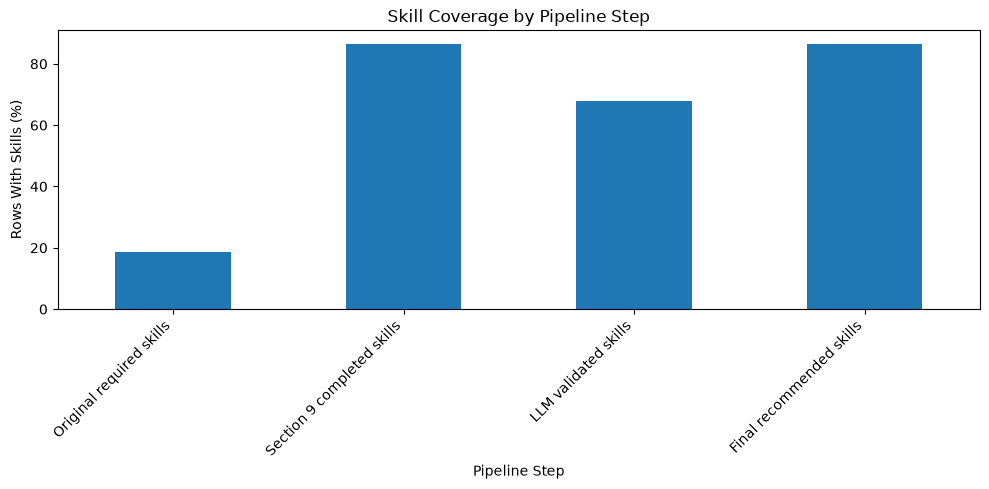

In [404]:
ax = coverage_summary.plot(
    x="step",
    y="coverage_percent",
    kind="bar",
    figsize=(10, 5),
    legend=False
)

ax.set_title("Skill Coverage by Pipeline Step")
ax.set_xlabel("Pipeline Step")
ax.set_ylabel("Rows With Skills (%)")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 11.3 Recommended skill source distribution

In [405]:
source_distribution = (
    df_eval["recommended_skill_source"]
    .value_counts()
    .reset_index()
)

source_distribution.columns = [
    "recommended_skill_source",
    "row_count"
]

source_distribution["percent"] = (
    source_distribution["row_count"]
    / len(df_eval)
    * 100
).round(2)

display(source_distribution)

,recommended_skill_source,row_count,percent
0,llm_validated_with_rescue,3915,67.82
1,original,1084,18.78
2,section9_not_llm_validated,774,13.41


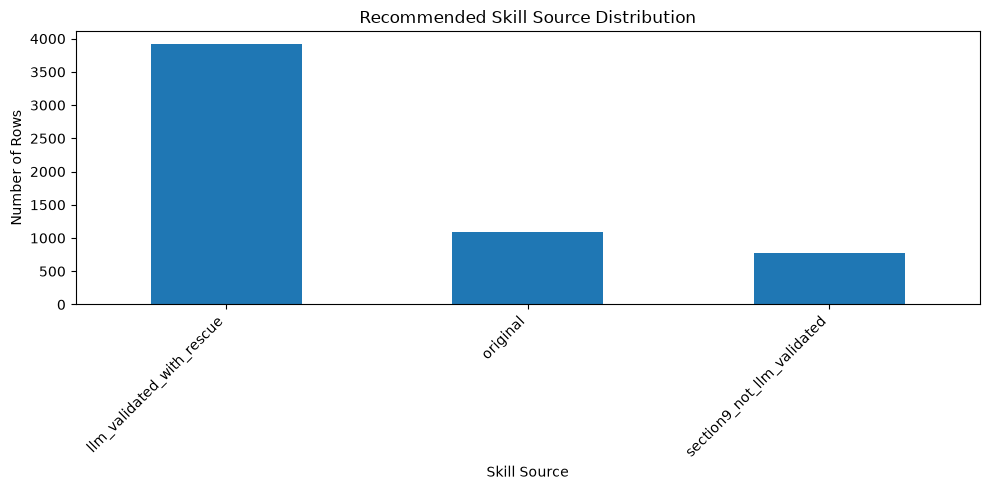

In [406]:
ax = (
    df_eval["recommended_skill_source"]
    .value_counts()
    .plot(
        kind="bar",
        figsize=(10, 5)
    )
)

ax.set_title("Recommended Skill Source Distribution")
ax.set_xlabel("Skill Source")
ax.set_ylabel("Number of Rows")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 11.4 LLM validation behavior

In [407]:
llm_rows = df_eval[
    df_eval["llm_status"] == "ok"
].copy()

print("Rows validated by LLM:", len(llm_rows))

llm_behavior_summary = llm_rows[
    [
        "n_completed_skills",
        "n_llm_validated_skills",
        "n_skills_removed_by_llm",
        "llm_keep_rate"
    ]
].describe()

display(llm_behavior_summary)

Rows validated by LLM: 3915


,n_completed_skills,n_llm_validated_skills,n_skills_removed_by_llm,llm_keep_rate
count,3915.000000,3915.000000,3915.000000,3915.000000
mean,4.182886,2.744572,1.438314,0.694589
std,1.561959,0.999306,1.132492,0.202855
min,1.000000,0.000000,0.000000,0.000000
25%,3.000000,2.000000,1.000000,0.500000
50%,4.000000,3.000000,1.000000,0.666667
75%,5.000000,3.000000,2.000000,0.800000
max,8.000000,8.000000,6.000000,1.000000


In [408]:
print("Average LLM keep rate:")
print(
    round(
        llm_rows["llm_keep_rate"].mean() * 100,
        2
    ),
    "%"
)

print("Median LLM keep rate:")
print(
    round(
        llm_rows["llm_keep_rate"].median() * 100,
        2
    ),
    "%"
)

Average LLM keep rate:
69.46 %
Median LLM keep rate:
66.67 %


## 11.5 Top skills removed by the LLM

In [409]:
removed_skill_counter = Counter()

for skills in df_eval["llm_removed_skills_list"]:

    for skill in skills:
        removed_skill_counter[skill] += 1


removed_skills_summary = pd.DataFrame(
    removed_skill_counter.most_common(30),
    columns=[
        "skill",
        "removed_count"
    ]
)

display(removed_skills_summary)

,skill,removed_count
0,rag,1462
1,r,693
2,azure,631
3,computer vision,543
4,nlp,415
5,fine-tuning,356
6,spark,354
7,openai,298
8,gcp,254
9,aws,171


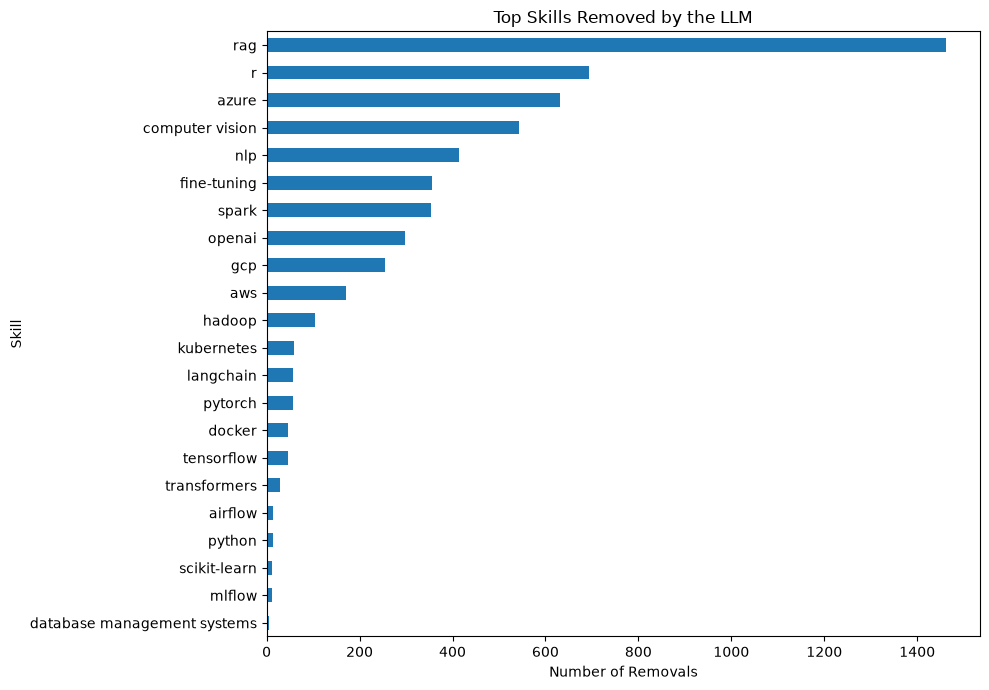

In [410]:
if len(removed_skills_summary) > 0:

    ax = (
        removed_skills_summary
        .set_index("skill")["removed_count"]
        .sort_values()
        .plot(
            kind="barh",
            figsize=(10, 7)
        )
    )

    ax.set_title("Top Skills Removed by the LLM")
    ax.set_xlabel("Number of Removals")
    ax.set_ylabel("Skill")

    plt.tight_layout()
    plt.show()

## 11.6 Top final recommended skills

In [411]:
recommended_skill_counter = Counter()

for skills in df_eval["recommended_skills_list"]:

    for skill in skills:
        recommended_skill_counter[skill] += 1


recommended_skills_summary = pd.DataFrame(
    recommended_skill_counter.most_common(30),
    columns=[
        "skill",
        "recommended_count"
    ]
)

display(recommended_skills_summary)

,skill,recommended_count
0,python,2467
1,nlp,1783
2,azure,1480
3,computer vision,1427
4,r,1418
5,aws,1252
6,rag,1193
7,fine-tuning,592
8,openai,446
9,gcp,431


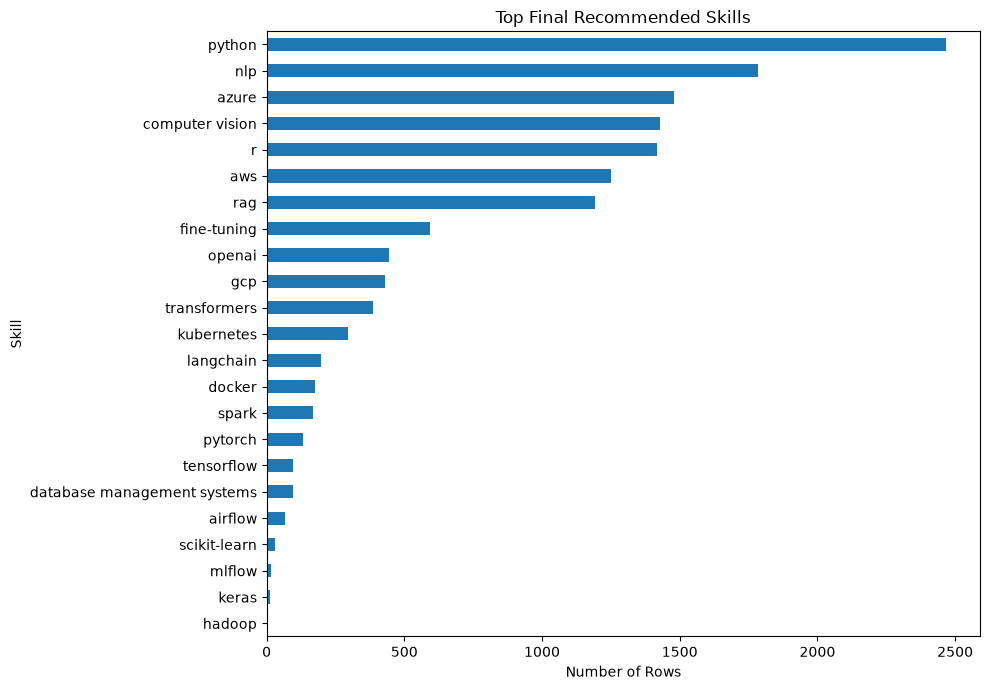

In [412]:
if len(recommended_skills_summary) > 0:

    ax = (
        recommended_skills_summary
        .set_index("skill")["recommended_count"]
        .sort_values()
        .plot(
            kind="barh",
            figsize=(10, 7)
        )
    )

    ax.set_title("Top Final Recommended Skills")
    ax.set_xlabel("Number of Rows")
    ax.set_ylabel("Skill")

    plt.tight_layout()
    plt.show()

## 11.7 Skill count comparison by job category

In [413]:
skill_count_by_category = (
    df_eval
    .groupby("normalized_title")
    .agg(
        rows=("job_title", "count"),
        avg_original_skills=(
            "original_skills_list",
            lambda values: values.apply(len).mean()
        ),
        avg_section9_skills=(
            "completed_skills_list",
            lambda values: values.apply(len).mean()
        ),
        avg_llm_validated_skills=(
            "llm_validated_skills_list",
            lambda values: values.apply(len).mean()
        ),
        avg_recommended_skills=(
            "recommended_skills_list",
            lambda values: values.apply(len).mean()
        )
    )
    .sort_values(
        "avg_recommended_skills",
        ascending=False
    )
)

display(skill_count_by_category)

,rows,avg_original_skills,avg_section9_skills,avg_llm_validated_skills,avg_recommended_skills
normalized_title,,,,,
Data Engineer,116,0.215517,3.801724,2.586207,3.508621
AI Engineer,1329,0.297216,3.856283,2.271633,3.079007
MLOps Engineer,251,0.410359,4.247012,1.996016,3.039841
LLM Engineer,396,0.260101,3.409091,1.934343,2.911616
Solutions Architect,79,0.316456,4.443038,2.202532,2.886076
Data Scientist,969,0.194014,3.565531,2.287926,2.843137
Machine Learning Engineer,822,0.159367,3.340633,2.216545,2.467153
DevOps Engineer,72,0.166667,2.263889,0.833333,2.208333
Software Engineer,439,0.195900,2.838269,1.699317,2.082005


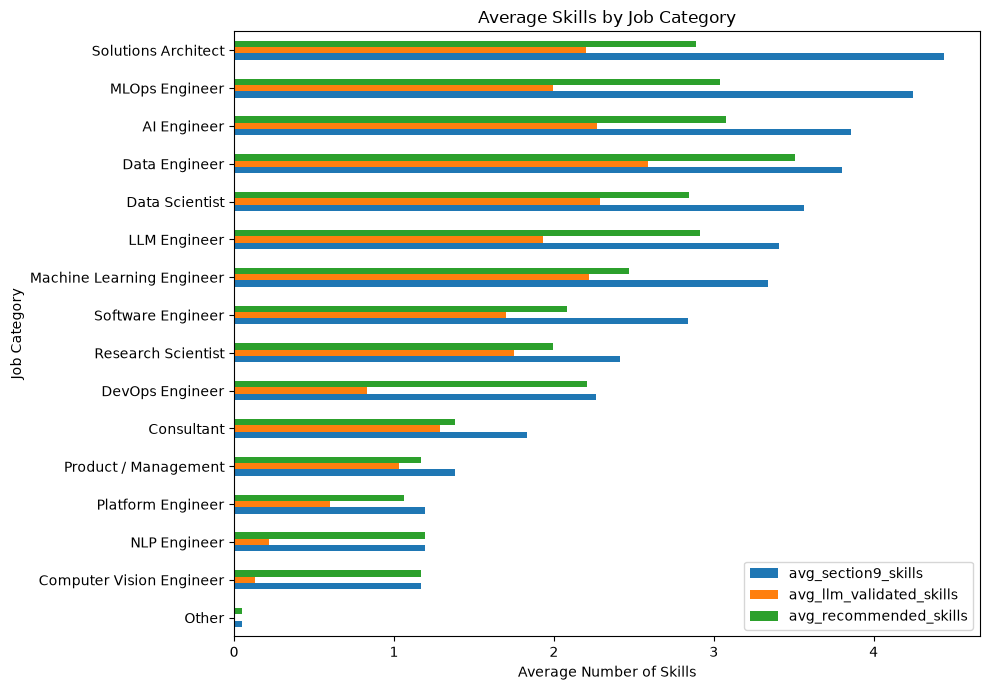

In [414]:
ax = (
    skill_count_by_category[
        [
            "avg_section9_skills",
            "avg_llm_validated_skills",
            "avg_recommended_skills"
        ]
    ]
    .sort_values("avg_section9_skills")
    .plot(
        kind="barh",
        figsize=(10, 7)
    )
)

ax.set_title("Average Skills by Job Category")
ax.set_xlabel("Average Number of Skills")
ax.set_ylabel("Job Category")

plt.tight_layout()
plt.show()

## 11.8 Top skills by selected job category

In [415]:
def get_top_skills_by_category(df, category, top_n=15):
    """
    Return the most common final recommended skills for one job category.
    """

    subset = df[
        df["normalized_title"] == category
    ]

    skill_counter = Counter()

    for skills in subset["recommended_skills_list"]:

        for skill in skills:
            skill_counter[skill] += 1

    return pd.DataFrame(
        skill_counter.most_common(top_n),
        columns=[
            "skill",
            "count"
        ]
    )

In [416]:
SELECTED_CATEGORIES = [
    "AI Engineer",
    "Machine Learning Engineer",
    "LLM Engineer",
    "Data Scientist",
    "Data Engineer",
    "MLOps Engineer",
    "Software Engineer"
]

for category in SELECTED_CATEGORIES:

    print("\n" + "=" * 60)
    print(category)
    print("=" * 60)

    display(
        get_top_skills_by_category(
            df_eval,
            category,
            top_n=15
        )
    )


AI Engineer


,skill,count
0,python,849
1,azure,622
2,nlp,597
3,rag,499
4,fine-tuning,346
5,aws,209
6,openai,208
7,computer vision,162
8,langchain,154
9,transformers,125



Machine Learning Engineer


,skill,count
0,nlp,459
1,computer vision,404
2,python,223
3,r,216
4,aws,155
5,rag,112
6,kubernetes,108
7,azure,107
8,tensorflow,55
9,transformers,45



LLM Engineer


...

,skill,count
0,aws,74
1,azure,72
2,gcp,70
3,spark,61
4,airflow,48
5,python,32
6,computer vision,20
7,openai,17
8,database management systems,9
9,rag,4



MLOps Engineer


,skill,count
0,aws,162
1,python,154
2,azure,113
3,docker,89
4,gcp,82
5,nlp,46
6,kubernetes,31
7,spark,18
8,transformers,17
9,mlflow,11



Software Engineer


,skill,count
0,python,259
1,aws,178
2,kubernetes,134
3,rag,70
4,azure,56
5,openai,54
6,r,47
7,nlp,44
8,computer vision,33
9,spark,33


## 11.9 Quality checks

In [417]:
print("Quality checks")
print("-" * 40)

print("Total rows:", len(df_eval))

print(
    "Rows with original skills:",
    df_eval["original_skills_list"]
    .apply(len)
    .gt(0)
    .sum()
)

print(
    "Rows with Section 9 completed skills:",
    df_eval["completed_skills_list"]
    .apply(len)
    .gt(0)
    .sum()
)

print(
    "Rows with final recommended skills:",
    df_eval["recommended_skills_list"]
    .apply(len)
    .gt(0)
    .sum()
)

Quality checks
----------------------------------------
Total rows: 5773
Rows with original skills: 1084
Rows with Section 9 completed skills: 4999
Rows with final recommended skills: 4998


In [418]:
original_rows = df_eval[
    df_eval["skill_inference_method"] == "original"
].copy()

original_preserved = (
    original_rows["original_skills_list"]
    ==
    original_rows["recommended_skills_list"]
).sum()

print("Original rows:", len(original_rows))
print("Original skills preserved:", original_preserved)

if len(original_rows) > 0:

    print(
        "Original preservation rate:",
        round(
            original_preserved / len(original_rows) * 100,
            2
        ),
        "%"
    )

Original rows: 1084
Original skills preserved: 1084
Original preservation rate: 100.0 %


In [419]:
def llm_output_is_subset(row):
    """
    Check that LLM-validated skills are always part of candidate skills.
    """

    if row["llm_status"] != "ok":
        return True

    candidate_skills = set(
        row["completed_skills_list"]
    )

    llm_skills = set(
        row["llm_validated_skills_list"]
    )

    return llm_skills.issubset(candidate_skills)


invalid_llm_subset_rows = df_eval[
    ~df_eval.apply(
        llm_output_is_subset,
        axis=1
    )
]

print("Invalid LLM subset rows:", len(invalid_llm_subset_rows))

Invalid LLM subset rows: 0


## 11.10 Inspect suspicious cases

In [420]:
empty_after_llm = df_eval[
    (df_eval["llm_status"] == "ok")
    &
    (df_eval["completed_skills_list"].apply(len) > 0)
    &
    (df_eval["llm_validated_skills_list"].apply(len) == 0)
].copy()

print("Rows where LLM removed all candidate skills:", len(empty_after_llm))

display(
    empty_after_llm[
        [
            "job_title",
            "normalized_title",
            "completed_skills_list",
            "llm_validated_skills_list",
            "llm_removed_skills_list",
            "llm_skill_reasons",
            "job_description"
        ]
    ]
    .sample(
        min(20, len(empty_after_llm)),
        random_state=42
    )
)

Rows where LLM removed all candidate skills: 1


,job_title,normalized_title,completed_skills_list,llm_validated_skills_list,llm_removed_skills_list,llm_skill_reasons,job_description
4141,"Senior Software Engineer (TypeScript, Node, AI)",Software Engineer,"[r, kubernetes, rag, aws, azure]",[],"[aws, azure, kubernetes, r, rag]",{},"About Settify Settify, an AI-backed technology, helps legal clients in preparing and presenting their personal stories effectively. It streamlines the initial information-gathering process, helping clients articulate key details when seeking legal assistance, particularly in areas like family law and wills. Collecting new client information can involve significant time and cost spent on both sides. Using Settify saves time, increases the accuracy of their work and ultimately, helps their client…"


In [421]:
low_keep_rate_cases = df_eval[
    (df_eval["llm_status"] == "ok")
    &
    (df_eval["llm_keep_rate"] <= 0.33)
    &
    (df_eval["completed_skills_list"].apply(len) > 0)
].copy()

print("Low keep rate cases:", len(low_keep_rate_cases))

display(
    low_keep_rate_cases[
        [
            "job_title",
            "normalized_title",
            "completed_skills_list",
            "llm_validated_skills_list",
            "llm_removed_skills_list",
            "llm_skill_reasons",
            "llm_keep_rate",
            "job_description"
        ]
    ]
    .sample(
        min(30, len(low_keep_rate_cases)),
        random_state=42
    )
)

Low keep rate cases: 63


,job_title,normalized_title,completed_skills_list,llm_validated_skills_list,llm_removed_skills_list,llm_skill_reasons,llm_keep_rate,job_description
4850,AI Engineer (PHP/Go),AI Engineer,"[rag, azure, fine-tuning, nlp]",[nlp],"[azure, fine-tuning, rag]",{},0.25,"Werde Teil unseres Teams und gestalte die Gesundheitsversorgung von morgen! Technologie. Intelligenz. Wirkung. Bei der apo.com Group entwickeln wir die nächste Generation von Online-Apotheken, E-Commerce-Plattformen und digitalen Gesundheitsservices. Als AI Engineer (PHP/Go) bringst du modernste KI-Technologien in echte Anwendungen – und hilfst dabei, unsere Systeme intelligenter, effizienter und zukunftsfähig zu machen. Deine Aufgaben bei uns KI integrieren: Du bindest AI-Service-APIs (z. B. O…"
4666,Frontend Engineer (Design Systems),Software Engineer,"[python, r, rag, kubernetes]",[python],"[kubernetes, r, rag]",{},0.25,"About Maincode Maincode is an applied AI lab. We turn research into practical tools: interfaces that support decision-making, surface insights, and communicate complex ideas with clarity. We believe AI’s next step forward isn’t scale, it’s design. Our work connects research and interface, helping people understand, navigate, and collaborate with intelligent systems. You’ll join the Design Engineering Group (DEG), a small, embedded team that works across brand, product, and early prototypes. We …"
156,Startup-Full Stack AI Engineer-Build AI Glasses and More!,AI Engineer,"[rag, fine-tuning, azure, python]",[python],"[azure, fine-tuning, rag]",{},0.25,"VP of Investor Relations (Remote, TX) — Lead the Narrative for a $1B Energy Innovator Powering Hyperscale Data Centers This Jobot Job is hosted by: John Armel Are you a fit? Easy Apply now by clicking the ""Apply"" button and sending us your resume. Salary: $250,000 - $300,000 per year A bit about us: Our client, a leading player in the Energy industry, is seeking an experienced and dynamic professional to join our executive team as the Vice President of Investor Relations. This role is pivotal i…"
3446,LLM Inference Deployment Engineer,LLM Engineer,"[transformers, spark, rag, fine-tuning]",[transformers],"[fine-tuning, rag, spark]",{},0.25,"EnCharge AI is a leader in advanced AI hardware and software systems for edge-to-cloud computing. EnCharge’s robust and scalable next-generation in-memory computing technology provides orders-of-magnitude higher compute efficiency and density compared to today’s best-in-class solutions. The high-performance architecture is coupled with seamless software integration and will enable the immense potential of AI to be accessible in power, energy, and space constrained applications. EnCharge AI laun…"
1119,Senior SaaS Cloud Capacity Engineer,DevOps Engineer,"[azure, openai, python, rag]",[python],"[azure, openai, rag]",{},0.25,"Job Description What You'll Do Capacity Engineering - Act as a strategic capacity partner, immersing in the end-to-end architecture and performance of SaaS production services. Ensure mission-critical workloads-including emerging agentic AI and MLOps pipelines -are forecasted, scaled, and optimized for OCI cloud capacity at enterprise scale. Cost Engineering - Translate SaaS capacity architectures into cost models that improve efficiency year over year. Partner with Cost Engineers to drive do…"
1976,Senior Machine Learning Engineer,Machine Learning Engineer,"[computer vision, nlp, airflow, pytorch]",[pytorch],"[airflow, computer vision, nlp]",{},0.25,"At Longshot Systems we build advanced platforms for sports betting analytics and trading. We're hiring Machine Learning Engineers for our modelling engineering team. You'd be working closely with the quantitative research teams to turn prototype trading models into production-ready systems, design and build the tooling, frameworks and data engineering required to support strategy research and development as well as architecting the high-level design of the strategy software to minimise trading …"
1130,

## 11.11 Create evaluation summary

In [422]:
evaluation_summary = pd.DataFrame({
    "metric": [
        "total_rows",
        "rows_with_original_skills",
        "rows_with_section9_completed_skills",
        "rows_validated_by_llm",
        "rows_with_final_recommended_skills",
        "final_recommended_coverage_percent",
        "average_original_skills_per_row",
        "average_section9_skills_per_row",
        "average_llm_validated_skills_per_row",
        "average_final_recommended_skills_per_row",
        "average_llm_keep_rate_percent",
        "median_llm_keep_rate_percent",
        "rows_where_llm_removed_all_skills",
        "invalid_llm_subset_rows"
    ],
    "value": [
        len(df_eval),

        df_eval["original_skills_list"]
        .apply(len)
        .gt(0)
        .sum(),

        df_eval["completed_skills_list"]
        .apply(len)
        .gt(0)
        .sum(),

        (df_eval["llm_status"] == "ok").sum(),

        df_eval["recommended_skills_list"]
        .apply(len)
        .gt(0)
        .sum(),

        round(
            df_eval["recommended_skills_list"]
            .apply(len)
            .gt(0)
            .mean() * 100,
            2
        ),

        round(
            df_eval["original_skills_list"]
            .apply(len)
            .mean(),
            2
        ),

        round(
            df_eval["completed_skills_list"]
            .apply(len)
            .mean(),
            2
        ),

        round(
            df_eval["llm_validated_skills_list"]
            .apply(len)
            .mean(),
            2
        ),

        round(
            df_eval["recommended_skills_list"]
            .apply(len)
            .mean(),
            2
        ),

        round(
            llm_rows["llm_keep_rate"].mean() * 100,
            2
        ),

        round(
            llm_rows["llm_keep_rate"].median() * 100,
            2
        ),

        len(empty_after_llm),

        len(invalid_llm_subset_rows)
    ]
})

display(evaluation_summary)

,metric,value
0,total_rows,5773.00
1,rows_with_original_skills,1084.00
2,rows_with_section9_completed_skills,4999.00
3,rows_validated_by_llm,3915.00
4,rows_with_final_recommended_skills,4998.00
5,final_recommended_coverage_percent,86.58
6,average_original_skills_per_row,0.26
7,average_section9_skills_per_row,3.10
8,average_llm_validated_skills_per_row,1.86
9,average_final_recommended_skills_per_row,2.45


## 11.12 Save evaluation outputs

In [423]:
EVALUATION_OUTPUT_DIR = (
    DATA_DIR
    / "outputs"
    / "tables"
)

EVALUATION_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [424]:
coverage_summary.to_csv(
    EVALUATION_OUTPUT_DIR / "coverage_summary.csv",
    index=False
)

source_distribution.to_csv(
    EVALUATION_OUTPUT_DIR / "recommended_skill_source_distribution.csv",
    index=False
)

removed_skills_summary.to_csv(
    EVALUATION_OUTPUT_DIR / "removed_skills_summary.csv",
    index=False
)

recommended_skills_summary.to_csv(
    EVALUATION_OUTPUT_DIR / "recommended_skills_summary.csv",
    index=False
)

skill_count_by_category.to_csv(
    EVALUATION_OUTPUT_DIR / "skill_count_by_category.csv"
)

evaluation_summary.to_csv(
    EVALUATION_OUTPUT_DIR / "evaluation_summary.csv",
    index=False
)

print("Evaluation tables saved.")
print("Output directory:", EVALUATION_OUTPUT_DIR)

Evaluation tables saved.
Output directory: C:\Users\jerem\job_analysis\2026_ai_job_market_analysis\outputs\tables


## 11.13 Save manual review sample

In [425]:
manual_review_sample = (
    df_eval[
        [
            "job_title",
            "normalized_title",
            "job_description",
            "completed_skills_list",
            "llm_validated_skills_list",
            "llm_removed_skills_list",
            "llm_skill_reasons",
            "recommended_skills_list",
            "recommended_skill_source",
            "llm_keep_rate"
        ]
    ]
    .sample(
        min(100, len(df_eval)),
        random_state=42
    )
)

MANUAL_REVIEW_PATH = (
    EVALUATION_OUTPUT_DIR
    / "manual_review_sample.csv"
)

manual_review_sample.to_csv(
    MANUAL_REVIEW_PATH,
    index=False
)

print("Manual review sample saved.")
print("Output path:", MANUAL_REVIEW_PATH)

Manual review sample saved.
Output path: C:\Users\jerem\job_analysis\2026_ai_job_market_analysis\outputs\tables\manual_review_sample.csv


## Section 11 Summary

This section evaluated the final skill completion pipeline.

The evaluation compared four stages:

1. Original required skills
2. Section 9 KNN-completed skills
3. Section 10 LLM-validated skills
4. Final recommended skills

The main findings are based on:

- coverage rate
- average skills per row
- LLM keep rate
- skills removed by the LLM
- final recommended skill frequency
- skill count by job category
- suspicious cases for manual review
- preservation of original skills

The evaluation also checked that the LLM did not introduce new skills outside the candidate skill list.

This confirms whether the final dataset is usable for market-level skill analysis.

The final recommended skills should be interpreted as a conservative market signal, not as a perfect extraction of every job requirement.

# 12. Final Dataset Creation

This section creates the final analysis-ready dataset.

It uses the output of Section 10 and the evaluation from Section 11.

The goal is to create two final files:

1. A complete final dataset with all useful audit columns
2. A lighter final dataset for visualization and market analysis

The final dataset keeps:

- original job posting information
- cleaned and normalized job titles
- ESCO-related information when available
- Section 9 completed skills
- Section 10 LLM-validated skills
- final recommended skills
- validation metadata

This dataset will be used in the next notebook for charts, insights and final analysis.

## 12.0 Load final recommended dataset

In [426]:
FINAL_INPUT_PATH = (
    DATA_DIR
    / "data"
    / "JobMarket2026"
    / "jobs_with_llm_recommended_skills.csv"
)

df_final = pd.read_csv(FINAL_INPUT_PATH)

print("Final input dataset loaded.")
print("Shape:", df_final.shape)

Final input dataset loaded.
Shape: (5773, 58)


## 12.1 Parse list and dictionary columns

In [427]:
def parse_list_final(value):
    """
    Convert saved CSV list values back into Python lists.
    """

    if isinstance(value, list):
        return value

    try:
        if pd.isna(value):
            return []
    except Exception:
        pass

    if isinstance(value, str):

        value = value.strip()

        if value == "" or value == "[]" or value.lower() == "nan":
            return []

        try:
            parsed_value = ast.literal_eval(value)

            if isinstance(parsed_value, list):
                return parsed_value

            return []

        except Exception:
            return [
                item.strip()
                for item in value.split(",")
                if item.strip()
            ]

    return []


def parse_dict_final(value):
    """
    Convert saved CSV dictionary values back into Python dictionaries.
    """

    if isinstance(value, dict):
        return value

    try:
        if pd.isna(value):
            return {}
    except Exception:
        pass

    if isinstance(value, str):

        value = value.strip()

        if value == "" or value.lower() == "nan":
            return {}

        try:
            parsed_value = ast.literal_eval(value)

            if isinstance(parsed_value, dict):
                return parsed_value

            return {}

        except Exception:
            return {}

    return {}

In [428]:
FINAL_LIST_COLUMNS = [
    "original_skills_list",
    "inferred_skills_knn",
    "completed_skills_list",
    "llm_validated_skills_list",
    "llm_removed_skills_list",
    "llm_rejected_skills",
    "recommended_skills_list"
]

for column in FINAL_LIST_COLUMNS:

    if column in df_final.columns:

        df_final[column] = (
            df_final[column]
            .apply(parse_list_final)
        )


if "llm_skill_reasons" in df_final.columns:

    df_final["llm_skill_reasons"] = (
        df_final["llm_skill_reasons"]
        .apply(parse_dict_final)
    )

else:

    df_final["llm_skill_reasons"] = [
        {}
        for _ in range(len(df_final))
    ]


print("List and dictionary columns parsed.")

List and dictionary columns parsed.


## 12.2 Create final analysis columns

In [429]:
df_final["job_posting_id"] = range(
    1,
    len(df_final) + 1
)

df_final["has_original_skills"] = (
    df_final["original_skills_list"]
    .apply(len)
    .gt(0)
)

df_final["has_section9_completed_skills"] = (
    df_final["completed_skills_list"]
    .apply(len)
    .gt(0)
)

df_final["has_recommended_skills"] = (
    df_final["recommended_skills_list"]
    .apply(len)
    .gt(0)
)

df_final["n_original_skills"] = (
    df_final["original_skills_list"]
    .apply(len)
)

df_final["n_section9_completed_skills"] = (
    df_final["completed_skills_list"]
    .apply(len)
)

df_final["n_final_recommended_skills"] = (
    df_final["recommended_skills_list"]
    .apply(len)
)

In [430]:
df_final["final_recommended_skills"] = (
    df_final["recommended_skills_list"]
    .apply(
        lambda skills:
        ", ".join(skills)
    )
)

df_final["final_skill_source"] = (
    df_final["recommended_skill_source"]
)

## 12.3 Final quality checks

In [431]:
print("Final dataset quality checks")
print("-" * 40)

print("Total rows:", len(df_final))

print(
    "Rows with original skills:",
    df_final["has_original_skills"].sum()
)

print(
    "Rows with Section 9 completed skills:",
    df_final["has_section9_completed_skills"].sum()
)

print(
    "Rows with final recommended skills:",
    df_final["has_recommended_skills"].sum()
)

print(
    "Final recommended coverage:",
    round(
        df_final["has_recommended_skills"].mean() * 100,
        2
    ),
    "%"
)

Final dataset quality checks
----------------------------------------
Total rows: 5773
Rows with original skills: 1084
Rows with Section 9 completed skills: 4999
Rows with final recommended skills: 4998
Final recommended coverage: 86.58 %


In [432]:
display(
    df_final["final_skill_source"]
    .value_counts()
    .to_frame("row_count")
)

,row_count
final_skill_source,
llm_validated_with_rescue,3915
original,1084
section9_not_llm_validated,774


## 12.4 Check that original skills are preserved

In [433]:
original_rows = df_final[
    df_final["skill_inference_method"] == "original"
].copy()

original_preserved = (
    original_rows["original_skills_list"]
    ==
    original_rows["recommended_skills_list"]
).sum()

print("Original rows:", len(original_rows))
print("Original skills preserved:", original_preserved)

if len(original_rows) > 0:

    print(
        "Original preservation rate:",
        round(
            original_preserved / len(original_rows) * 100,
            2
        ),
        "%"
    )

Original rows: 1084
Original skills preserved: 1084
Original preservation rate: 100.0 %


## 12.5 Define complete final dataset columns

In [434]:
COMPLETE_FINAL_COLUMNS = [
    # ID
    "job_posting_id",

    # Raw job information
    "job_title",
    "job_title_original",
    "company",
    "country",
    "city",
    "city_clean",
    "remote_type",
    "experience_level",
    "source",

    # Salary
    "salary_min",
    "salary_max",
    "salary_avg",
    "currency",

    # Dates
    "posted_date",
    "year",
    "month",
    "year_month",

    # Job description
    "job_description",
    "description_length",
    "description_truncated",

    # Title normalization
    "normalized_title",
    "title_similarity",
    "normalization_method",

    # ESCO
    "esco_occupation",
    "esco_preferred_label",
    "esco_uri",

    # Original skills
    "required_skills",
    "original_skills_list",
    "has_original_skills",
    "n_original_skills",

    # Section 9 skills
    "inferred_skills_knn",
    "completed_skills_list",
    "skill_inference_method",
    "has_section9_completed_skills",
    "n_section9_completed_skills",

    # Section 10 LLM validation
    "needs_llm_validation",
    "llm_status",
    "llm_validated_skills_list",
    "llm_removed_skills_list",
    "llm_rejected_skills",
    "llm_skill_reasons",
    "llm_keep_rate",

    # Final recommended skills
    "recommended_skills_list",
    "recommended_skills",
    "final_recommended_skills",
    "recommended_skill_source",
    "final_skill_source",
    "has_recommended_skills",
    "n_recommended_skills",
    "n_final_recommended_skills"
]

available_complete_columns = [
    column
    for column in COMPLETE_FINAL_COLUMNS
    if column in df_final.columns
]

df_final_complete = df_final[
    available_complete_columns
].copy()

print("Complete final dataset shape:", df_final_complete.shape)

Complete final dataset shape: (5773, 48)


## 12.6 Define light final dataset columns

In [435]:
LIGHT_FINAL_COLUMNS = [
    # ID
    "job_posting_id",

    # Job information
    "job_title",
    "company",
    "country",
    "city_clean",
    "remote_type",
    "experience_level",
    "source",

    # Salary and date
    "salary_min",
    "salary_max",
    "salary_avg",
    "currency",
    "posted_date",
    "year",
    "month",
    "year_month",

    # Normalized title
    "normalized_title",
    "title_similarity",
    "normalization_method",

    # ESCO
    "esco_occupation",

    # Final skills
    "final_recommended_skills",
    "recommended_skills_list",
    "final_skill_source",
    "has_recommended_skills",
    "n_final_recommended_skills",

    # Useful quality columns
    "has_original_skills",
    "has_section9_completed_skills",
    "llm_status",
    "llm_keep_rate"
]

available_light_columns = [
    column
    for column in LIGHT_FINAL_COLUMNS
    if column in df_final.columns
]

df_final_light = df_final[
    available_light_columns
].copy()

print("Light final dataset shape:", df_final_light.shape)

Light final dataset shape: (5773, 29)


## 12.7 Preview final datasets

In [436]:
display(
    df_final_complete.head()
)

,job_posting_id,job_title,job_title_original,company,country,city,city_clean,remote_type,experience_level,source,salary_min,salary_max,salary_avg,currency,posted_date,year,month,year_month,job_description,description_length,description_truncated,normalized_title,title_similarity,normalization_method,esco_occupation,required_skills,original_skills_list,has_original_skills,n_original_skills,inferred_skills_knn,completed_skills_list,skill_inference_method,has_section9_completed_skills,n_section9_completed_skills,needs_llm_validation,llm_status,llm_validated_skills_list,llm_removed_skills_list,llm_skill_reasons,llm_keep_rate,recommended_skills_list,recommended_skills,final_recommended_skills,recommended_skill_source,final_skill_source,has_recommended_skills,n_recommended_skills,n_final_recommended_skills
0,1,AI Engineer,AI Engineer,Jobot,United States,Mount Carmel,mount carmel,Unspecified,Lead,Adzuna,160000.0,160000.0,160000.0,USD,2026-02-16,2026.0,2.0,2026-02,"RAG - Vector Databases - Cloud - AI/ML This Jobot Job is hosted by: Chuck Wirtz Are you a fit? Easy Apply now by clicking the ""Apply"" button and sending us your resume. Salary: $175,000 - $200,000 per year A bit about us: We are a rapidly-growing and well-funded women-lead AI start-up that innovates our client's projects from concept to delivery. Why join us? We work with highly recognizable enterprise clients to deliver a fully customized solution. Our technology solution is best-in-class and …",500,True,AI Engineer,1.0,rule,artificial intelligence engineer,RAG,[rag],True,1,[],[rag],original,True,1,False,not_validated,[],[],{},0.000000,[rag],rag,rag,original,original,True,1,1
1,2,AI Engineer,AI Engineer,Jobot,United States,The Gap,the gap,Unspecified,Lead,Adzuna,175000.0,175000.0,175000.0,USD,2026-02-16,2026.0,2.0,2026-02,"RAG - Vector Databases - Cloud - AI/ML This Jobot Job is hosted by: Chuck Wirtz Are you a fit? Easy Apply now by clicking the ""Apply"" button and sending us your resume. Salary: $175,000 - $200,000 per year A bit about us: We are a rapidly-growing and well-funded women-lead AI start-up that innovates our client's projects from concept to delivery. Why join us? We work with highly recognizable enterprise clients to deliver a fully customized solution. Our technology solution is best-in-class and …",500,True,AI Engineer,1.0,rule,artificial intelligence engineer,RAG,[rag],True,1,[],[rag],original,True,1,False,not_validated,[],[],{},0.000000,[rag],rag,rag,original,original,True,1,1
2,3,AI Engineer,AI Engineer,Jobot,United States,Nashville,nashville,Unspecified,Lead,Adzuna,218000.0,218000.0,218000.0,USD,2026-02-16,2026.0,2.0,2026-02,"RAG - Vector Databases - Cloud - AI/ML This Jobot Job is hosted by: Chuck Wirtz Are you a fit? Easy Apply now by clicking the ""Apply"" button and sending us your resume. Salary: $175,000 - $200,000 per year A bit about us: We are a rapidly-growing and well-funded women-lead AI start-up that innovates our client's projects from concept to delivery. Why join us? We work with highly recognizable enterprise clients to deliver a fully customized solution. Our technology solution is best-in-class and …",500,True,AI Engineer,1.0,rule,artificial intelligence engineer,RAG,[rag],True,1,[],[rag],original,True,1,False,not_validated,[],[],{},0.000000,[rag],rag,rag,original,original,True,1,1
3,4,Frontend/AI Engineer,Frontend/AI Engineer,Jobot,United States,New York City,new york city,Unspecified,Mid-level,Adzuna,112000.0,112000.0,112000.0,USD,2026-02-16,2026.0,2.0,2026-02,"Manufacturing Company looking for Business System Analyst This Jobot Job is hosted by: John Erwin Are you a fit? Easy Apply now by clicking the ""Apply"" button and sending us your resume. Salary: $100,000 - $140,000 per year A bit about us: We are a Manufacturer of Electronic Components Why join us? Generous Compensation Great Benefits (Medical, Vision, Dental) Career Growth PTO Sick Pay Holidays Paid Job Details Job Details: We are seeking a dynamic and experienced Bus

In [437]:
display(
    df_final_light.head()
)

,job_posting_id,job_title,company,country,city_clean,remote_type,experience_level,source,salary_min,salary_max,salary_avg,currency,posted_date,year,month,year_month,normalized_title,title_similarity,normalization_method,esco_occupation,final_recommended_skills,recommended_skills_list,final_skill_source,has_recommended_skills,n_final_recommended_skills,has_original_skills,has_section9_completed_skills,llm_status,llm_keep_rate
0,1,AI Engineer,Jobot,United States,mount carmel,Unspecified,Lead,Adzuna,160000.0,160000.0,160000.0,USD,2026-02-16,2026.0,2.0,2026-02,AI Engineer,1.0,rule,artificial intelligence engineer,rag,[rag],original,True,1,True,True,not_validated,0.000000
1,2,AI Engineer,Jobot,United States,the gap,Unspecified,Lead,Adzuna,175000.0,175000.0,175000.0,USD,2026-02-16,2026.0,2.0,2026-02,AI Engineer,1.0,rule,artificial intelligence engineer,rag,[rag],original,True,1,True,True,not_validated,0.000000
2,3,AI Engineer,Jobot,United States,nashville,Unspecified,Lead,Adzuna,218000.0,218000.0,218000.0,USD,2026-02-16,2026.0,2.0,2026-02,AI Engineer,1.0,rule,artificial intelligence engineer,rag,[rag],original,True,1,True,True,not_validated,0.000000
3,4,Frontend/AI Engineer,Jobot,United States,new york city,Unspecified,Mid-level,Adzuna,112000.0,112000.0,112000.0,USD,2026-02-16,2026.0,2.0,2026-02,AI Engineer,1.0,rule,artificial intelligence engineer,"aws, azure, computer vision, nlp, python","[aws, azure, computer vision, nlp, python]",llm_validated_with_rescue,True,5,False,True,ok,0.625000
4,5,AI Engineering Lead,Jobot,United States,irvine,Unspecified,Senior,Adzuna,92000.0,92000.0,92000.0,USD,2026-02-16,2026.0,2.0,2026-02,AI Engineer,1.0,rule,artificial intelligence engineer,azure,[azure],llm_validated_with_rescue,True,1,False,True,ok,0.333333


## 12.8 Save final datasets

In [438]:
FINAL_COMPLETE_PATH = (
    DATA_DIR
    / "data"
    / "JobMarket2026"
    / "final_ai_job_market_dataset.csv"
)

FINAL_LIGHT_PATH = (
    DATA_DIR
    / "data"
    / "JobMarket2026"
    / "final_ai_job_market_dataset_light.csv"
)

In [439]:
df_final_complete.to_csv(
    FINAL_COMPLETE_PATH,
    index=False
)

df_final_light.to_csv(
    FINAL_LIGHT_PATH,
    index=False
)

print("Final datasets saved.")
print("Complete dataset:", FINAL_COMPLETE_PATH)
print("Light dataset:", FINAL_LIGHT_PATH)

Final datasets saved.
Complete dataset: C:\Users\jerem\job_analysis\2026_ai_job_market_analysis\data\JobMarket2026\final_ai_job_market_dataset.csv
Light dataset: C:\Users\jerem\job_analysis\2026_ai_job_market_analysis\data\JobMarket2026\final_ai_job_market_dataset_light.csv


## 12.9 Save a data dictionary

In [440]:
data_dictionary = pd.DataFrame({
    "column": df_final_complete.columns,
    "description": [
        "Unique row identifier generated for the final dataset"
        if column == "job_posting_id"

        else "Original or cleaned job title"
        if column == "job_title"

        else "Original job title before non-English cleanup"
        if column == "job_title_original"

        else "Company name"
        if column == "company"

        else "Country of the job posting"
        if column == "country"

        else "Cleaned city value"
        if column == "city_clean"

        else "Remote, hybrid, onsite or unspecified"
        if column == "remote_type"

        else "Experience level from the source dataset"
        if column == "experience_level"

        else "Average salary calculated from salary_min and salary_max"
        if column == "salary_avg"

        else "Normalized job category assigned by the hybrid title normalization step"
        if column == "normalized_title"

        else "Similarity score used during semantic title normalization"
        if column == "title_similarity"

        else "Method used for title normalization"
        if column == "normalization_method"

        else "Closest ESCO occupation when available"
        if column == "esco_occupation"

        else "Original skill list extracted from required_skills"
        if column == "original_skills_list"

        else "Skill list completed by Section 9"
        if column == "completed_skills_list"

        else "Method used to complete skills in Section 9"
        if column == "skill_inference_method"

        else "Skills kept by the local LLM validation step"
        if column == "llm_validated_skills_list"

        else "Skills removed by the local LLM validation step"
        if column == "llm_removed_skills_list"

        else "Short LLM reasons for keeping or rejecting skills"
        if column == "llm_skill_reasons"

        else "Final recommended skill list used for analysis"
        if column == "recommended_skills_list"

        else "Final recommended skills as a comma-separated string"
        if column == "final_recommended_skills"

        else "Source of the final recommended skills"
        if column == "final_skill_source"

        else "Number of final recommended skills"
        if column == "n_final_recommended_skills"

        else "Dataset column"
        for column in df_final_complete.columns
    ]
})

display(data_dictionary)

,column,description
0,job_posting_id,Unique row identifier generated for the final dataset
1,job_title,Original or cleaned job title
2,job_title_original,Original job title before non-English cleanup
3,company,Company name
4,country,Country of the job posting
5,city,Dataset column
6,city_clean,Cleaned city value
7,remote_type,"Remote, hybrid, onsite or unspecified"
8,experience_level,Experience level from the source dataset
9,source,Dataset column


In [441]:
DATA_DICTIONARY_PATH = (
    DATA_DIR
    / "outputs"
    / "tables"
    / "final_dataset_data_dictionary.csv"
)

DATA_DICTIONARY_PATH.parent.mkdir(
    parents=True,
    exist_ok=True
)

data_dictionary.to_csv(
    DATA_DICTIONARY_PATH,
    index=False
)

print("Data dictionary saved.")
print("Output path:", DATA_DICTIONARY_PATH)

Data dictionary saved.
Output path: C:\Users\jerem\job_analysis\2026_ai_job_market_analysis\outputs\tables\final_dataset_data_dictionary.csv


## 12.10 Final project summary

In [442]:
final_project_summary = pd.DataFrame({
    "metric": [
        "total_rows",
        "final_complete_columns",
        "final_light_columns",
        "rows_with_final_recommended_skills",
        "final_recommended_coverage_percent",
        "average_final_recommended_skills_per_row",
        "unique_normalized_titles",
        "countries",
        "date_min",
        "date_max"
    ],
    "value": [
        len(df_final_complete),
        df_final_complete.shape[1],
        df_final_light.shape[1],

        df_final_complete["has_recommended_skills"].sum()
        if "has_recommended_skills" in df_final_complete.columns
        else None,

        round(
            df_final_complete["has_recommended_skills"].mean() * 100,
            2
        )
        if "has_recommended_skills" in df_final_complete.columns
        else None,

        round(
            df_final_complete["n_final_recommended_skills"].mean(),
            2
        )
        if "n_final_recommended_skills" in df_final_complete.columns
        else None,

        df_final_complete["normalized_title"].nunique()
        if "normalized_title" in df_final_complete.columns
        else None,

        df_final_complete["country"].nunique()
        if "country" in df_final_complete.columns
        else None,

        df_final_complete["posted_date"].min()
        if "posted_date" in df_final_complete.columns
        else None,

        df_final_complete["posted_date"].max()
        if "posted_date" in df_final_complete.columns
        else None
    ]
})

display(final_project_summary)

,metric,value
0,total_rows,5773
1,final_complete_columns,48
2,final_light_columns,29
3,rows_with_final_recommended_skills,4998
4,final_recommended_coverage_percent,86.58
5,average_final_recommended_skills_per_row,2.45
6,unique_normalized_titles,16
7,countries,5
8,date_min,2021-05-29
9,date_max,2026-02-22


In [443]:
PROJECT_SUMMARY_PATH = (
    DATA_DIR
    / "outputs"
    / "tables"
    / "final_project_summary.csv"
)

final_project_summary.to_csv(
    PROJECT_SUMMARY_PATH,
    index=False
)

print("Final project summary saved.")
print("Output path:", PROJECT_SUMMARY_PATH)

Final project summary saved.
Output path: C:\Users\jerem\job_analysis\2026_ai_job_market_analysis\outputs\tables\final_project_summary.csv


## Section 12 Summary

This section created the final analysis-ready datasets.

Two datasets were saved:

1. `final_ai_job_market_dataset.csv`
2. `final_ai_job_market_dataset_light.csv`

The complete dataset keeps detailed audit information, including original skills, completed skills, LLM validation results and final recommended skills.

The light dataset keeps only the columns needed for visualizations and market analysis.

A data dictionary and a project summary were also saved.

The final dataset is now ready for the analysis notebook.